# Resultados y análisis del TFM

Este cuaderno reúne el análisis final de las cadenas MCMC correspondientes a los cuatro modelos cosmológicos estudiados:

- $\Lambda$CDM plano
- CPL
- CPL$_2$
- modelo exponencial

Se consideran las combinaciones de datos:

- B: DESI BAO DR1
- S: Pantheon+SH0ES
- C: CMB distance priors
- BS, CB, CS y CBS

El objetivo del cuaderno es presentar las restricciones posteriores, comparar las diferentes combinaciones de datos, reconstruir la evolución de la energía oscura y realizar la comparación estadística entre modelos.

Los scripts utilizados para generar las cadenas se distribuyen separadamente. Este cuaderno está concebido principalmente como material complementario de resultados y análisis.

## Reproducibilidad y archivos de entrada

El cuaderno utiliza como entrada principal los productos resumidos contenidos en `results_final/extraction/`.

Algunos análisis requieren además acceso a las muestras MCMC completas, en particular:

- contornos posteriores con GetDist
- reconstrucciones muestra a muestra de $w(z)$
- propagaciones a $f_{\rm DE}(z)$ y $\Omega_{\rm DE}(z)$
- cruces de $w=-1$
- diagnósticos basados en la distribución completa de las muestras
- cálculo de $\mathrm{DIC}_V$

Si las cadenas completas no están disponibles, los resultados ya ejecutados y los productos exportados permiten consultar el análisis final, aunque estas partes no puedan regenerarse directamente.

## Preparación del análisis

Este bloque prepara la infraestructura necesaria para el análisis de los resultados finales del TFM.

La extracción y validación de las cadenas se consideran cerradas. Por tanto, en este cuaderno no se repetirán de forma sistemática diagnósticos de convergencia, autocorrelación, ESS, revisión de pesos o trazas.

El análisis partirá principalmente de los productos reducidos almacenados en `results_final/extraction/`. Las cadenas completas de `chains_final/final/` solo se cargarán cuando sea necesario recuperar información posterior conjunta que no esté contenida en los productos de extracción.

### Imports y configuración básica

In [1]:
from pathlib import Path
import json
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from importlib.metadata import version
from scipy.special import expi
from getdist import MCSamples, plots

In [2]:
print(f"Python:     {sys.version.split()[0]}")
print(f"NumPy:      {np.__version__}")
print(f"pandas:     {pd.__version__}")
print(f"Matplotlib: {version('matplotlib')}")
print(f"SciPy:      {version('scipy')}")
print(f"GetDist:    {version('getdist')}")
print(f"Cobaya:     {version('cobaya')}")

Python:     3.12.12
NumPy:      2.3.5
pandas:     2.3.3
Matplotlib: 3.10.8
SciPy:      1.16.3
GetDist:    1.7.6
Cobaya:     3.6.2


### Rutas del proyecto

Las rutas utilizadas en el análisis se construyen de forma relativa a la raíz del proyecto para mantener el cuaderno reproducible e independiente de la máquina desde la que se ejecute.

La raíz se identifica buscando la estructura del proyecto a partir del directorio de trabajo actual. A partir de ella se definen las carpetas que contienen las cadenas finales, los productos de extracción y las salidas definitivas del análisis.

In [3]:
def find_project_root(start: Path) -> Path:
    """
    Localiza la raíz del proyecto a partir de un directorio inicial.

    La búsqueda comienza en ``start`` y continúa por sus directorios
    padre hasta encontrar la estructura mínima necesaria para ejecutar
    el cuaderno: ``results_final/extraction/``.

    La existencia de las cadenas MCMC no se utiliza como criterio,
    ya que estas se consideran una dependencia opcional para algunos
    análisis.

    Parameters
    ----------
    start : pathlib.Path
        Directorio desde el que comienza la búsqueda.

    Returns
    -------
    pathlib.Path
        Ruta absoluta a la raíz del proyecto.

    Raises
    ------
    FileNotFoundError
        Si no se encuentra ``results_final/extraction/`` en el
        directorio inicial ni en ninguno de sus padres.
    """
    start = start.resolve()

    for candidate in [start, *start.parents]:
        extraction_dir = (
            candidate
            / "results_final"
            / "extraction"
        )

        if extraction_dir.exists():
            return candidate

    raise FileNotFoundError(
        "No se ha podido localizar la raíz del proyecto. "
        "Se esperaba encontrar `results_final/extraction/` "
        "en el directorio actual o en alguno de sus padres."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

CHAINS_FINAL_DIR = PROJECT_ROOT / "chains_final" / "final"

RESULTS_FINAL_DIR = PROJECT_ROOT / "results_final"
EXTRACTION_DIR = RESULTS_FINAL_DIR / "extraction"

FIGURES_DIR = RESULTS_FINAL_DIR / "figures"
TABLES_DIR = RESULTS_FINAL_DIR / "tables"

CHAINS_AVAILABLE = (
    CHAINS_FINAL_DIR.is_dir()
    and any(CHAINS_FINAL_DIR.glob("*.txt"))
)

In [4]:
ANALYSIS_FIGURES_DIR = (
    FIGURES_DIR / "analysis"
)

In [5]:
required_dirs = {
    "PROJECT_ROOT": PROJECT_ROOT,
    "RESULTS_FINAL_DIR": RESULTS_FINAL_DIR,
    "EXTRACTION_DIR": EXTRACTION_DIR,
}

missing_dirs = [
    name
    for name, path in required_dirs.items()
    if not path.is_dir()
]

if missing_dirs:
    raise FileNotFoundError(
        "Faltan carpetas necesarias del proyecto: "
        + ", ".join(missing_dirs)
    )

for name, path in required_dirs.items():
    relative_path = (
        "."
        if path == PROJECT_ROOT
        else path.relative_to(PROJECT_ROOT)
    )
    print(f"{name}: {relative_path}")

print(
    "CHAINS_FINAL_DIR:",
    CHAINS_FINAL_DIR.relative_to(PROJECT_ROOT),
)

print(
    "CHAINS_AVAILABLE:",
    CHAINS_AVAILABLE,
)

PROJECT_ROOT: .
RESULTS_FINAL_DIR: results_final
EXTRACTION_DIR: results_final/extraction
CHAINS_FINAL_DIR: chains_final/final
CHAINS_AVAILABLE: True


### Carga de los productos de extracción

El análisis parte de los productos generados y validados previamente durante la fase de extracción de resultados. Estos archivos constituyen la interfaz estable entre las cadenas MCMC y este cuaderno.

Se cargan el inventario de cadenas, los diagnósticos finales, los resúmenes posteriores, los mejores puntos muestreados, las advertencias de validación y los metadatos generales de la extracción.

In [6]:
EXTRACTION_FILES = {
    "inventory": EXTRACTION_DIR / "chain_inventory.csv",
    "diagnostics": EXTRACTION_DIR / "chain_diagnostics.csv",
    "posterior_summary": EXTRACTION_DIR / "posterior_summary.csv",
    "best_sampled_points": EXTRACTION_DIR / "best_sampled_points.csv",
    "validation_warnings": EXTRACTION_DIR / "validation_warnings.csv",
    "metadata": EXTRACTION_DIR / "chain_metadata.json",
}

missing_files = [
    path.name
    for path in EXTRACTION_FILES.values()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Faltan productos de extracción necesarios: "
        + ", ".join(missing_files)
    )

In [7]:
chain_inventory = pd.read_csv(EXTRACTION_FILES["inventory"])
chain_diagnostics = pd.read_csv(EXTRACTION_FILES["diagnostics"])
posterior_summary = pd.read_csv(EXTRACTION_FILES["posterior_summary"])
best_sampled_points = pd.read_csv(EXTRACTION_FILES["best_sampled_points"])
validation_warnings = pd.read_csv(EXTRACTION_FILES["validation_warnings"])

with open(EXTRACTION_FILES["metadata"], "r", encoding="utf-8") as f:
    chain_metadata = json.load(f)

In [8]:
loaded_products = {
    "chain_inventory": chain_inventory,
    "chain_diagnostics": chain_diagnostics,
    "posterior_summary": posterior_summary,
    "best_sampled_points": best_sampled_points,
    "validation_warnings": validation_warnings,
}

for name, df in loaded_products.items():
    print(f"{name}: {df.shape[0]} filas × {df.shape[1]} columnas")

print(f"chain_metadata: {type(chain_metadata).__name__}")

chain_inventory: 28 filas × 22 columnas
chain_diagnostics: 28 filas × 35 columnas
posterior_summary: 119 filas × 15 columnas
best_sampled_points: 28 filas × 37 columnas
validation_warnings: 9 filas × 11 columnas
chain_metadata: dict


### Comprobación de integridad de la interfaz de análisis

Antes de iniciar el análisis se comprueba que los productos de extracción son internamente coherentes: deben contener las mismas 28 identidades científicas, mantener una clasificación de validación consistente y coincidir con el alcance registrado en los metadatos.

Esta comprobación no repite la validación de las cadenas MCMC ni exige que las muestras completas estén disponibles. Su objetivo es verificar la consistencia de los productos reducidos que constituyen la interfaz de entrada del cuaderno.

In [9]:
MODEL_ORDER = ["LCDM", "CPL", "CPL2", "EXP"]
COMBINATION_ORDER = ["B", "S", "C", "BS", "CB", "CS", "CBS"]

IDENTITY_COLUMNS = ["model_id", "combination_id"]

expected_identities = {
    (model_id, combination_id)
    for model_id in MODEL_ORDER
    for combination_id in COMBINATION_ORDER
}


def get_identity_set(df):
    """
    Obtiene el conjunto de identidades científicas presentes en una tabla.

    Cada identidad está definida por el par ``(model_id, combination_id)``,
    que identifica de forma única uno de los cuatro modelos y una de las
    siete combinaciones de datos consideradas.

    Parameters
    ----------
    df : pandas.DataFrame
        Tabla que contiene las columnas ``model_id`` y
        ``combination_id``.

    Returns
    -------
    set of tuple
        Conjunto de pares ``(model_id, combination_id)`` presentes
        en la tabla.
    """
    return set(
        df[IDENTITY_COLUMNS]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )


identity_products = {
    "chain_inventory": chain_inventory,
    "chain_diagnostics": chain_diagnostics,
    "posterior_summary": posterior_summary,
    "best_sampled_points": best_sampled_points,
}

for name, df in identity_products.items():
    identities = get_identity_set(df)

    missing = expected_identities - identities
    extra = identities - expected_identities

    if missing or extra:
        raise ValueError(
            f"Inconsistencia de identidades en {name}. "
            f"Faltantes: {sorted(missing)}. "
            f"Extras: {sorted(extra)}."
        )

In [10]:
classification_check = (
    chain_inventory[
        IDENTITY_COLUMNS + ["classification"]
    ]
    .merge(
        chain_diagnostics[
            IDENTITY_COLUMNS + ["classification"]
        ],
        on=IDENTITY_COLUMNS,
        how="outer",
        suffixes=("_inventory", "_diagnostics"),
        validate="one_to_one",
    )
)

if not (
    classification_check["classification_inventory"]
    == classification_check["classification_diagnostics"]
).all():
    raise ValueError(
        "Las clasificaciones de validación no coinciden "
        "entre el inventario y los diagnósticos."
    )


scope = chain_metadata["scope"]

if scope["n_chains"] != len(expected_identities):
    raise ValueError(
        "El número de cadenas registrado en los metadatos "
        "no coincide con las 28 identidades esperadas."
    )

if scope["n_posterior_summary_rows"] != len(posterior_summary):
    raise ValueError(
        "El número de filas de posterior_summary no coincide "
        "con los metadatos."
    )

if scope["n_best_sampled_points"] != len(best_sampled_points):
    raise ValueError(
        "El número de mejores puntos muestreados no coincide "
        "con los metadatos."
    )

if scope["n_validation_warnings"] != len(validation_warnings):
    raise ValueError(
        "El número de advertencias no coincide con los metadatos."
    )

if (
    chain_inventory["n_validation_warnings"].sum()
    != len(validation_warnings)
):
    raise ValueError(
        "El número total de advertencias no coincide "
        "entre el inventario y validation_warnings."
    )

In [11]:
classification_counts = (
    chain_inventory["classification"]
    .value_counts()
    .reindex(
        [
            "VÁLIDA",
            "VÁLIDA CON OBSERVACIONES",
            "REQUIERE REVISIÓN",
            "NO UTILIZABLE",
        ],
        fill_value=0,
    )
)

print(f"Identidades científicas: {len(expected_identities)}")
print(f"Modelos: {len(MODEL_ORDER)}")
print(f"Combinaciones: {len(COMBINATION_ORDER)}")
print()

for classification, count in classification_counts.items():
    print(f"{classification}: {count}")

print()
print(
    "Cadenas con advertencias:",
    validation_warnings[
        IDENTITY_COLUMNS
    ].drop_duplicates().shape[0],
)
print("Advertencias registradas:", len(validation_warnings))

print()
print("Integridad de la interfaz de análisis: OK")

Identidades científicas: 28
Modelos: 4
Combinaciones: 7

VÁLIDA: 22
VÁLIDA CON OBSERVACIONES: 6
REQUIERE REVISIÓN: 0
NO UTILIZABLE: 0

Cadenas con advertencias: 6
Advertencias registradas: 9

Integridad de la interfaz de análisis: OK


### Nomenclatura científica y estructura de parámetros

El cuaderno distingue entre los identificadores internos utilizados en los archivos y la nomenclatura científica empleada en tablas, figuras y texto.

Las siete combinaciones de datos se identifican mediante `B`, `S`, `C`, `BS`, `CB`, `CS` y `CBS`:

- `B`: DESI BAO DR1.
- `S`: Pantheon+ con calibración SH0ES, según la implementación utilizada en este trabajo.
- `C`: información CMB comprimida mediante distance priors.
- `BS`, `CB`, `CS` y `CBS`: combinaciones de las anteriores.

Por tanto, `C` no representa una likelihood completa del espectro CMB, sino la likelihood gaussiana construida a partir del vector comprimido $(R,\ell_A,\omega_b)$ y su covarianza.

La nomenclatura científica definitiva de los modelos es $\Lambda$CDM, CPL, CPL$_2$ y modelo exponencial. El identificador `CPL2` se utiliza dentro del cuaderno, mientras que algunos archivos originales emplean `CPLn2`. En la presentación científica se utiliza siempre CPL$_2$, y su segundo parámetro se denota mediante $w_2$.

El parámetro derivado `rd_eff`, presente históricamente en la extracción de $\Lambda$CDM-BS, se conserva únicamente por compatibilidad con los productos de extracción y no forma parte de los resultados científicos presentados.

In [12]:
MODEL_LABELS = {
    "LCDM": r"$\Lambda$CDM",
    "CPL": "CPL",
    "CPL2": r"CPL$_2$",
    "EXP": "Exponencial",
}

COMBINATION_LABELS = {
    "B": "DESI BAO DR1",
    "S": "Pantheon+SH0ES",
    "C": "CMB distance priors",
    "BS": "BAO + Pantheon+SH0ES",
    "CB": "CMB + BAO",
    "CS": "CMB + Pantheon+SH0ES",
    "CBS": "CMB + BAO + Pantheon+SH0ES",
}

PARAMETER_LABELS = {
    "Omega_m": r"$\Omega_m$",
    "H0": r"$H_0$",
    "H0rd": r"$H_0 r_d$",
    "omega_b": r"$\omega_b$",
    "rd_eff": r"$r_d^{\mathrm{eff}}$",
    "w0": r"$w_0$",
    "wa": r"$w_a$",
    "w2": r"$w_2$",
    "we": r"$w_e$",
}

PARAMETER_UNITS = {
    "Omega_m": None,
    "H0": r"km s$^{-1}$ Mpc$^{-1}$",
    "H0rd": r"km s$^{-1}$",
    "omega_b": None,
    "rd_eff": "Mpc",
    "w0": None,
    "wa": None,
    "w2": None,
    "we": None,
}

# Parámetros conservados en los productos de extracción por motivos
# históricos o técnicos, pero excluidos de la presentación científica.
AUXILIARY_PARAMETERS = {"rd_eff"}

In [13]:
BASE_PARAMETERS_BY_COMBINATION = {
    "B": ["Omega_m", "H0rd"],
    "S": ["Omega_m", "H0"],
    "C": ["Omega_m", "H0", "omega_b"],
    "BS": ["Omega_m", "H0", "H0rd"],
    "CB": ["Omega_m", "H0", "omega_b"],
    "CS": ["Omega_m", "H0", "omega_b"],
    "CBS": ["Omega_m", "H0", "omega_b"],
}

DE_PARAMETERS = {
    "LCDM": [],
    "CPL": ["w0", "wa"],
    "CPL2": ["w0", "w2"],
    "EXP": ["w0", "we"],
}

PARAMETERS_BY_IDENTITY = {}

for model_id in MODEL_ORDER:
    for combination_id in COMBINATION_ORDER:
        parameters = (
            BASE_PARAMETERS_BY_COMBINATION[combination_id]
            + DE_PARAMETERS[model_id]
        )

        # Parámetro derivado histórico conservado únicamente para que
        # la estructura coincida con los productos originales de extracción.
        if model_id == "LCDM" and combination_id == "BS":
            parameters = parameters + ["rd_eff"]

        PARAMETERS_BY_IDENTITY[
            (model_id, combination_id)
        ] = parameters

In [14]:
required_summary_columns = {
    "model_id",
    "combination_id",
    "parameter",
}

missing_columns = required_summary_columns - set(posterior_summary.columns)

if missing_columns:
    raise KeyError(
        "Faltan columnas necesarias en posterior_summary: "
        + ", ".join(sorted(missing_columns))
    )


parameter_structure_errors = []

for identity, expected_parameters in PARAMETERS_BY_IDENTITY.items():
    model_id, combination_id = identity

    observed_parameters = (
        posterior_summary.loc[
            (posterior_summary["model_id"] == model_id)
            & (posterior_summary["combination_id"] == combination_id),
            "parameter",
        ]
        .tolist()
    )

    if set(observed_parameters) != set(expected_parameters):
        parameter_structure_errors.append(
            {
                "identity": identity,
                "expected": expected_parameters,
                "observed": observed_parameters,
            }
        )

if parameter_structure_errors:
    raise ValueError(
        "La estructura de parámetros no coincide con la esperada:\n"
        + "\n".join(map(str, parameter_structure_errors))
    )

In [15]:
for model_id in MODEL_ORDER:
    model_summary = posterior_summary[
        posterior_summary["model_id"] == model_id
    ]

    available_parameters = set(
        model_summary["parameter"]
    )

    scientific_parameters = [
        parameter
        for parameter in PARAMETER_LABELS
        if (
            parameter in available_parameters
            and parameter not in AUXILIARY_PARAMETERS
        )
    ]

    print(
        f"{MODEL_LABELS[model_id]}: "
        f"{len(model_summary)} filas | "
        f"parámetros científicos: "
        f"{', '.join(scientific_parameters)}"
    )

print()
print(
    "Parámetros auxiliares excluidos de la presentación:",
    ", ".join(sorted(AUXILIARY_PARAMETERS)),
)
print("Estructura de parámetros: OK")

$\Lambda$CDM: 20 filas | parámetros científicos: Omega_m, H0, H0rd, omega_b
CPL: 33 filas | parámetros científicos: Omega_m, H0, H0rd, omega_b, w0, wa
CPL$_2$: 33 filas | parámetros científicos: Omega_m, H0, H0rd, omega_b, w0, w2
Exponencial: 33 filas | parámetros científicos: Omega_m, H0, H0rd, omega_b, w0, we

Parámetros auxiliares excluidos de la presentación: rd_eff
Estructura de parámetros: OK


### Priors y referencias de $\Lambda$CDM

Los priors utilizados en las cadenas finales se registran explícitamente para identificar posibles restricciones asociadas a los límites del espacio de muestreo y mantener una referencia única durante el análisis.

En los tres modelos dinámicos, $\Lambda$CDM corresponde a un punto exacto del espacio de parámetros de energía oscura. Estas referencias se emplean en la interpretación de las distribuciones posteriores y en las figuras de los parámetros dinámicos.

In [16]:
PRIORS = {
    "LCDM": {
        "Omega_m": (0.1, 0.7),
        "H0": (50.0, 100.0),
        "H0rd": (8000.0, 12000.0),
        "omega_b": (0.020, 0.025),
    },
    "CPL": {
        "Omega_m": (0.1, 0.7),
        "H0": (50.0, 100.0),
        "H0rd": (8000.0, 12000.0),
        "omega_b": (0.020, 0.025),
        "w0": (-2.0, 2.0),
        "wa": (-10.0, 5.0),
    },
    "CPL2": {
        "Omega_m": (0.05, 0.7),
        "H0": (50.0, 100.0),
        "H0rd": (8000.0, 12000.0),
        "omega_b": (0.020, 0.025),
        "w0": (-3.0, 2.0),
        "w2": (-20.0, 5.0),
    },
    "EXP": {
        "Omega_m": (0.05, 0.7),
        "H0": (50.0, 100.0),
        "H0rd": (8000.0, 12000.0),
        "omega_b": (0.020, 0.025),
        "w0": (-3.0, 0.5),
        "we": (-5.0, 12.0),
    },
}

In [17]:
LCDM_REFERENCE = {
    "CPL": {
        "w0": -1.0,
        "wa": 0.0,
    },
    "CPL2": {
        "w0": -1.0,
        "w2": 0.0,
    },
    "EXP": {
        "w0": -1.0,
        "we": 0.0,
    },
}

In [18]:
EARLY_DE_LIMITS = {
    "EXP": {
        "combinations": {"C", "CB", "CS", "CBS"},
        "z_star": 1090.0,
        "Omega_DE_max": 1e-2,
    }
}

En el modelo exponencial, las combinaciones que contienen información CMB incorporan además la condición

$$
\Omega_{\mathrm{DE}}(z_\ast) \leq 10^{-2},
\qquad z_\ast = 1090.
$$

Esta restricción no corresponde a un prior rectangular sobre un parámetro individual, sino a una condición adicional sobre el dominio físico permitido del modelo. Se introdujo para evitar soluciones con una contribución excesiva de energía oscura en recombinación al utilizar los distance priors.

El umbral $10^{-2}$ forma parte de la implementación final adoptada para EXP y debe entenderse como una elección metodológica, no como un límite inferido estadísticamente por los datos. No se impuso una condición equivalente explícita en CPL o CPL$_2$.

In [19]:
prior_structure_errors = []

for identity, parameters in PARAMETERS_BY_IDENTITY.items():
    model_id, combination_id = identity

    for parameter in parameters:
        if parameter in AUXILIARY_PARAMETERS:
            continue

        if parameter not in PRIORS[model_id]:
            prior_structure_errors.append(
                (model_id, combination_id, parameter)
            )

if prior_structure_errors:
    raise ValueError(
        "Hay parámetros sin prior registrado: "
        + str(prior_structure_errors)
    )

print("Priors registrados para los cuatro modelos: OK")
print("Referencias exactas de ΛCDM en los modelos dinámicos: OK")
print("Condición early-DE de EXP con CMB registrada: OK")

Priors registrados para los cuatro modelos: OK
Referencias exactas de ΛCDM en los modelos dinámicos: OK
Condición early-DE de EXP con CMB registrada: OK


### Resúmenes posteriores

Los resúmenes marginales exportados durante la extracción constituyen la fuente principal para las tablas numéricas del análisis.

La presentación adoptada es bayesiana: se utiliza preferentemente la mediana como estimador central y el intervalo creíble central del 68 %, recurriendo al 95 % cuando aporta información adicional. Las medias y desviaciones estándar se mantienen disponibles como información complementaria, pero no se utilizan automáticamente como formato principal.

In [20]:
required_posterior_columns = {
    "model_id",
    "combination_id",
    "parameter",
    "mean",
    "std",
    "median",
    "q16",
    "q84",
    "q2_5",
    "q97_5",
}

missing_columns = required_posterior_columns - set(posterior_summary.columns)

if missing_columns:
    raise KeyError(
        "Faltan columnas estadísticas necesarias en posterior_summary: "
        + ", ".join(sorted(missing_columns))
    )


quantile_order_ok = (
    (posterior_summary["q2_5"] <= posterior_summary["q16"])
    & (posterior_summary["q16"] <= posterior_summary["median"])
    & (posterior_summary["median"] <= posterior_summary["q84"])
    & (posterior_summary["q84"] <= posterior_summary["q97_5"])
).all()

if not quantile_order_ok:
    raise ValueError(
        "Se ha detectado al menos una fila con cuantiles fuera de orden."
    )

print("Columnas estadísticas necesarias: OK")
print("Orden de cuantiles: OK")

Columnas estadísticas necesarias: OK
Orden de cuantiles: OK


### Helpers para consultar los resúmenes posteriores

In [21]:
posterior = posterior_summary.copy()

posterior["model_id"] = pd.Categorical(
    posterior["model_id"],
    categories=MODEL_ORDER,
    ordered=True,
)

posterior["combination_id"] = pd.Categorical(
    posterior["combination_id"],
    categories=COMBINATION_ORDER,
    ordered=True,
)

posterior = (
    posterior
    .sort_values(["model_id", "combination_id"])
    .reset_index(drop=True)
)

In [22]:
def get_posterior_row(
    model_id,
    combination_id,
    parameter,
):
    """
    Recupera una restricción posterior concreta.

    Selecciona en la tabla ``posterior`` la fila correspondiente
    a un modelo, una combinación de datos y un parámetro determinados.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.
    combination_id : str
        Identificador de la combinación de datos.
    parameter : str
        Nombre interno del parámetro que se desea consultar.

    Returns
    -------
    pandas.Series
        Fila que contiene las estadísticas marginales del parámetro
        solicitado.

    Raises
    ------
    ValueError
        Si la selección no contiene exactamente una fila.
    """
    selection = posterior.loc[
        (posterior["model_id"] == model_id)
        & (
            posterior["combination_id"]
            == combination_id
        )
        & (posterior["parameter"] == parameter)
    ]

    if len(selection) != 1:
        raise ValueError(
            "Se esperaba exactamente una fila para "
            f"({model_id}, {combination_id}, {parameter}) "
            f"y se han encontrado {len(selection)}."
        )

    return selection.iloc[0]

In [23]:
def get_credible_interval(
    model_id,
    combination_id,
    parameter,
    level=68,
):
    """
    Obtiene la mediana y un intervalo creíble central.

    Los límites se recuperan directamente de los cuantiles calculados
    durante la extracción. Se admiten intervalos centrales del 68 %
    y del 95 %.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.
    combination_id : str
        Identificador de la combinación de datos.
    parameter : str
        Parámetro cuya distribución marginal se desea consultar.
    level : {68, 95}, default=68
        Nivel del intervalo creíble central.

    Returns
    -------
    dict
        Diccionario con la mediana, los límites inferior y superior
        y las desviaciones asimétricas respecto a la mediana.

    Raises
    ------
    ValueError
        Si se solicita un nivel distinto del 68 % o del 95 %.
    """
    row = get_posterior_row(
        model_id,
        combination_id,
        parameter,
    )

    if level == 68:
        lower, upper = row["q16"], row["q84"]

    elif level == 95:
        lower, upper = row["q2_5"], row["q97_5"]

    else:
        raise ValueError(
            "Solo se admiten intervalos del 68 % o del 95 %."
        )

    return {
        "median": row["median"],
        "lower": lower,
        "upper": upper,
        "minus": row["median"] - lower,
        "plus": upper - row["median"],
    }

In [24]:
def get_model_summary(
    model_id,
    combination_id=None,
):
    """
    Recupera el resumen posterior asociado a un modelo.

    Puede devolver todas las combinaciones disponibles para el modelo
    o restringir la selección a una combinación concreta.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.
    combination_id : str or None, default=None
        Combinación de datos que se desea seleccionar. Si es ``None``,
        se incluyen todas las combinaciones del modelo.

    Returns
    -------
    pandas.DataFrame
        Subconjunto ordenado del resumen posterior.
    """
    selection = posterior.loc[
        posterior["model_id"] == model_id
    ].copy()

    if combination_id is not None:
        selection = selection.loc[
            selection["combination_id"]
            == combination_id
        ].copy()

    return selection.reset_index(drop=True)

In [25]:
PARAMETER_DECIMALS = {
    "Omega_m": 4,
    "H0": 2,
    "H0rd": 0,
    "omega_b": 5,
    "w0": 3,
    "wa": 2,
    "w2": 3,
    "we": 3,
}


def format_constraint(row, parameter, level=68):
    """
    Formatea una restricción posterior con errores asimétricos.

    La restricción se expresa mediante la mediana y un intervalo
    creíble central, utilizando un número de decimales específico
    para cada parámetro.

    Parameters
    ----------
    row : pandas.Series
        Fila de ``posterior`` que contiene la mediana y los cuantiles
        del parámetro.
    parameter : str
        Nombre interno del parámetro.
    level : {68, 95}, default=68
        Nivel del intervalo creíble central que se desea mostrar.

    Returns
    -------
    str
        Restricción formateada en sintaxis matemática de LaTeX.

    Raises
    ------
    KeyError
        Si el parámetro no tiene definido un número de decimales.
    ValueError
        Si se solicita un nivel distinto del 68 % o del 95 %.
    """
    decimals = PARAMETER_DECIMALS[parameter]

    median = row["median"]

    if level == 68:
        lower = row["q16"]
        upper = row["q84"]
    elif level == 95:
        lower = row["q2_5"]
        upper = row["q97_5"]
    else:
        raise ValueError(
            "Solo se admiten intervalos del 68 % o del 95 %."
        )

    err_minus = median - lower
    err_plus = upper - median

    return (
        rf"${median:.{decimals}f}"
        rf"^{{+{err_plus:.{decimals}f}}}"
        rf"_{{-{err_minus:.{decimals}f}}}$"
    )


def build_constraint_table(
    model_id,
    parameters,
    level=68,
):
    """
    Construye una tabla homogénea de restricciones para un modelo.

    Las filas corresponden a las siete combinaciones de datos y las
    columnas a los parámetros solicitados. Cuando un parámetro no está
    definido para una combinación concreta se muestra un guion largo.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.
    parameters : iterable of str
        Parámetros que se desean incluir en la tabla.
    level : {68, 95}, default=68
        Nivel de los intervalos creíbles mostrados.

    Returns
    -------
    pandas.DataFrame
        Tabla de restricciones ordenada según ``COMBINATION_ORDER``.
    """
    table_rows = []

    for combination_id in COMBINATION_ORDER:
        output_row = {"Combinación": combination_id}

        for parameter in parameters:
            selection = posterior.loc[
                (posterior["model_id"] == model_id)
                & (
                    posterior["combination_id"]
                    == combination_id
                )
                & (posterior["parameter"] == parameter)
            ]

            label = PARAMETER_LABELS[parameter]

            if selection.empty:
                output_row[label] = "—"
            elif len(selection) == 1:
                output_row[label] = format_constraint(
                    selection.iloc[0],
                    parameter,
                    level=level,
                )
            else:
                raise ValueError(
                    "Se esperaba como máximo una fila para "
                    f"({model_id}, {combination_id}, {parameter}) "
                    f"y se han encontrado {len(selection)}."
                )

        table_rows.append(output_row)

    return (
        pd.DataFrame(table_rows)
        .set_index("Combinación")
        .reindex(COMBINATION_ORDER)
    )

In [26]:
test_68 = get_credible_interval(
    model_id="LCDM",
    combination_id="CBS",
    parameter="Omega_m",
    level=68,
)

test_95 = get_credible_interval(
    model_id="LCDM",
    combination_id="CBS",
    parameter="Omega_m",
    level=95,
)

print("Consulta individual: OK")
print("Intervalo 68%:", test_68)
print("Intervalo 95%:", test_95)
print(
    "Filas LCDM:",
    len(get_model_summary("LCDM"))
)
print(
    "Filas LCDM-CBS:",
    len(get_model_summary("LCDM", "CBS"))
)

Consulta individual: OK
Intervalo 68%: {'median': np.float64(0.249981795), 'lower': np.float64(0.2480682544), 'upper': np.float64(0.2517428499999999), 'minus': np.float64(0.0019135406000000132), 'plus': np.float64(0.0017610549999999003)}
Intervalo 95%: {'median': np.float64(0.249981795), 'lower': np.float64(0.24659742075), 'upper': np.float64(0.25345382925), 'minus': np.float64(0.0033843742500000162), 'plus': np.float64(0.003472034249999978)}
Filas LCDM: 20
Filas LCDM-CBS: 3


### Helpers para advertencias y mejores puntos muestreados

In [27]:
def get_validation_warnings(
    model_id,
    combination_id,
):
    """
    Recupera las advertencias de validación asociadas a una identidad.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.
    combination_id : str
        Identificador de la combinación de datos.

    Returns
    -------
    pandas.DataFrame
        Advertencias registradas para la identidad solicitada.
        Si no existen, se devuelve un DataFrame vacío.
    """
    return (
        validation_warnings.loc[
            (
                validation_warnings["model_id"]
                == model_id
            )
            & (
                validation_warnings["combination_id"]
                == combination_id
            )
        ]
        .copy()
        .reset_index(drop=True)
    )


def get_best_sampled_point(
    model_id,
    combination_id,
):
    """
    Recupera el mejor punto realmente visitado por una cadena MCMC.

    El punto corresponde a la muestra con menor chi-cuadrado total
    identificada durante la extracción. No representa necesariamente
    un mínimo global obtenido mediante una optimización independiente.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.
    combination_id : str
        Identificador de la combinación de datos.

    Returns
    -------
    pandas.Series
        Fila de ``best_sampled_points`` correspondiente a la identidad
        solicitada.

    Raises
    ------
    ValueError
        Si no existe exactamente un punto para la identidad indicada.
    """
    selection = best_sampled_points.loc[
        (
            best_sampled_points["model_id"]
            == model_id
        )
        & (
            best_sampled_points["combination_id"]
            == combination_id
        )
    ]

    if len(selection) != 1:
        raise ValueError(
            "Se esperaba exactamente un mejor punto muestreado para "
            f"({model_id}, {combination_id}) y se han encontrado "
            f"{len(selection)}."
        )

    return selection.iloc[0]

In [28]:
def get_model_best_sampled_points(model_id):
    """
    Recupera los mejores puntos muestreados de un modelo.

    Selecciona las siete identidades correspondientes al modelo y las
    ordena según ``COMBINATION_ORDER``. Cada fila representa la muestra
    realmente visitada con menor chi-cuadrado total en la cadena
    correspondiente.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.

    Returns
    -------
    pandas.DataFrame
        Mejores puntos muestreados, indexados por combinación de datos.

    Raises
    ------
    ValueError
        Si no se recupera exactamente una fila para cada una de las
        siete combinaciones esperadas.
    """
    selection = best_sampled_points.loc[
        best_sampled_points["model_id"] == model_id
    ].copy()

    counts = selection["combination_id"].value_counts()

    if (
        len(selection) != len(COMBINATION_ORDER)
        or (counts != 1).any()
    ):
        raise ValueError(
            "La estructura de mejores puntos muestreados no es "
            f"la esperada para {model_id}."
        )

    selection["combination_id"] = pd.Categorical(
        selection["combination_id"],
        categories=COMBINATION_ORDER,
        ordered=True,
    )

    return (
        selection
        .sort_values("combination_id")
        .set_index("combination_id")
    )


def build_chi2_contribution_table(model_id):
    """
    Construye una tabla homogénea de contribuciones al chi-cuadrado.

    Para cada combinación se recuperan el chi-cuadrado total y las
    contribuciones disponibles de BAO, SNIa y CMB en el mejor punto
    muestreado. La función detecta automáticamente los nombres internos
    de las columnas correspondientes a cada sonda.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.

    Returns
    -------
    pandas.DataFrame
        Tabla con las columnas ``Total``, ``BAO``, ``SN`` y ``CMB``.

    Raises
    ------
    ValueError
        Si una misma sonda presenta más de una contribución no nula
        para una identidad.
    """
    best = get_model_best_sampled_points(model_id)

    probe_prefixes = {
        "BAO": "chi2__bao",
        "SN": "chi2__sn",
        "CMB": "chi2__cmb",
    }

    records = []

    for combination_id, row in best.iterrows():
        record = {
            "Combinación": str(combination_id),
            "Total": row["chi2"],
        }

        for probe, prefix in probe_prefixes.items():
            candidate_columns = [
                column
                for column in best.columns
                if column.startswith(prefix)
            ]

            available_values = [
                row[column]
                for column in candidate_columns
                if pd.notna(row[column])
            ]

            if len(available_values) > 1:
                raise ValueError(
                    f"Se ha encontrado más de una contribución "
                    f"{probe} para {model_id}-{combination_id}."
                )

            record[probe] = (
                available_values[0]
                if available_values
                else np.nan
            )

        records.append(record)

    return (
        pd.DataFrame(records)
        .set_index("Combinación")
        .reindex(COMBINATION_ORDER)
    )


def build_probe_delta_chi2_table(model_id):
    """
    Calcula el deterioro del ajuste de cada sonda al combinar datasets.

    Cada diferencia compara la contribución de una sonda en una
    combinación conjunta con la obtenida cuando esa misma sonda se
    ajusta sola o dentro de una referencia compatible.

    Para BAO se mantienen separadas las dos implementaciones utilizadas:
    ``BS - B`` compara la rama efectiva H0*r_d, mientras que
    ``CBS - CB`` compara la rama física empleada cuando interviene CMB.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.

    Returns
    -------
    pandas.DataFrame
        Tabla con la sonda, la comparación realizada y el incremento
        correspondiente de chi-cuadrado.

    Raises
    ------
    ValueError
        Si falta alguna contribución necesaria para una comparación.
    """
    contributions = build_chi2_contribution_table(model_id)

    comparisons = [
        ("BAO", "BS - B", "BS", "B"),
        ("BAO", "CBS - CB", "CBS", "CB"),
        ("SN", "BS - S", "BS", "S"),
        ("SN", "CS - S", "CS", "S"),
        ("SN", "CBS - S", "CBS", "S"),
        ("CMB", "CB - C", "CB", "C"),
        ("CMB", "CS - C", "CS", "C"),
        ("CMB", "CBS - C", "CBS", "C"),
    ]

    records = []

    for probe, label, joint, reference in comparisons:
        joint_value = contributions.loc[joint, probe]
        reference_value = contributions.loc[reference, probe]

        if pd.isna(joint_value) or pd.isna(reference_value):
            raise ValueError(
                f"No puede calcularse {label} para {probe} "
                f"en {model_id}."
            )

        records.append({
            "Sonda": probe,
            "Comparación": label,
            r"$\Delta\chi^2$": joint_value - reference_value,
        })

    return pd.DataFrame(records)

In [29]:
print(
    "Warnings LCDM-CBS:",
    len(get_validation_warnings("LCDM", "CBS")),
)

print(
    "Warnings CPL-C:",
    len(get_validation_warnings("CPL", "C")),
)

print(
    "Warnings EXP-C:",
    len(get_validation_warnings("EXP", "C")),
)

test_best_point = get_best_sampled_point("LCDM", "CBS")

print()
print(
    "Mejor punto muestreado LCDM-CBS localizado:",
    test_best_point["disk_prefix"],
)

print("Helpers auxiliares: OK")

Warnings LCDM-CBS: 0
Warnings CPL-C: 2
Warnings EXP-C: 2

Mejor punto muestreado LCDM-CBS localizado: cbs_LCDM_sep
Helpers auxiliares: OK


### Acceso opcional a las cadenas completas

Los productos reducidos de `results_final/extraction/` constituyen la entrada principal del análisis y permiten consultar las restricciones marginales, diagnósticos y mejores puntos muestreados sin cargar las cadenas MCMC completas.

Algunas operaciones requieren, sin embargo, información posterior conjunta que no puede reconstruirse únicamente a partir de estos productos. Entre ellas se encuentran los contornos bidimensionales de GetDist, determinadas correlaciones, las reconstrucciones muestra a muestra de funciones derivadas y algunos diagnósticos estadísticos basados en la posterior completa.

Las funciones de esta sección permiten acceder a una identidad concreta bajo demanda, conservando los pesos originales de Cobaya y sin aplicar un burn-in adicional. Las cadenas almacenadas en `chains_final/final/` se consideran por tanto una dependencia opcional del cuaderno: su ausencia no impide utilizar los productos reducidos, aunque las celdas que requieran explícitamente las muestras completas no podrán regenerarse.

In [30]:
def get_disk_prefix(model_id, combination_id):
    """
    Recupera el prefijo de archivo asociado a una identidad científica.

    El prefijo se obtiene del inventario generado durante la extracción
    y permite relacionar los identificadores utilizados en el análisis
    con los nombres físicos de los archivos de cadena.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.
    combination_id : str
        Identificador de la combinación de datos.

    Returns
    -------
    str
        Prefijo utilizado por los archivos de la cadena correspondiente.

    Raises
    ------
    ValueError
        Si el inventario no contiene exactamente un prefijo para la
        identidad solicitada.
    """
    selection = chain_inventory.loc[
        (chain_inventory["model_id"] == model_id)
        & (chain_inventory["combination_id"] == combination_id),
        "disk_prefix",
    ]

    if len(selection) != 1:
        raise ValueError(
            "Se esperaba exactamente un prefijo para "
            f"({model_id}, {combination_id}) y se han encontrado "
            f"{len(selection)}."
        )

    return selection.iloc[0]


def resolve_chain_fragments(model_id, combination_id):
    """
    Localiza y ordena los fragmentos que forman una cadena MCMC.

    Las cadenas de Cobaya pueden estar distribuidas en varios archivos
    con nombres del tipo ``prefijo.N.txt``. Esta función identifica los
    fragmentos correspondientes a una identidad y los ordena mediante
    el índice numérico ``N``.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.
    combination_id : str
        Identificador de la combinación de datos.

    Returns
    -------
    tuple
        Par ``(prefix, fragments)``, donde ``prefix`` es el prefijo de
        la cadena y ``fragments`` es la lista ordenada de rutas a sus
        fragmentos.

    Raises
    ------
    FileNotFoundError
        Si no se localiza ningún fragmento para la identidad solicitada.
    """
    prefix = get_disk_prefix(
        model_id,
        combination_id,
    )

    pattern = re.compile(
        rf"^{re.escape(prefix)}\.(\d+)\.txt$"
    )

    fragments = []

    for path in CHAINS_FINAL_DIR.glob(f"{prefix}.*.txt"):
        match = pattern.match(path.name)

        if match is not None:
            fragments.append(
                (int(match.group(1)), path)
            )

    fragments = [
        path
        for _, path in sorted(fragments)
    ]

    if not fragments:
        raise FileNotFoundError(
            "No se han localizado los fragmentos de la cadena "
            f"{prefix!r} en {CHAINS_FINAL_DIR}."
        )

    return prefix, fragments

In [31]:
def read_chain_columns(path):
    """
    Lee los nombres de las columnas almacenadas en una cadena de Cobaya.

    Los nombres se recuperan de la primera línea del archivo, que
    Cobaya guarda como una cabecera precedida por ``#``.

    Parameters
    ----------
    path : str or pathlib.Path
        Ruta al fragmento de cadena que se desea inspeccionar.

    Returns
    -------
    list of str
        Nombres de las columnas en el orden en que aparecen en el archivo.

    Raises
    ------
    ValueError
        Si el archivo no contiene una cabecera reconocible.
    """
    with Path(path).open(
        "r",
        encoding="utf-8",
        errors="replace",
    ) as file:
        header = file.readline().strip()

    if not header.startswith("#"):
        raise ValueError(
            f"La cadena no contiene una cabecera reconocible: {path}"
        )

    return header.lstrip("#").split()


def load_raw_chain(model_id, combination_id):
    """
    Carga y concatena todos los fragmentos de una cadena MCMC.

    Se conserva la estructura original de columnas de Cobaya y no se
    aplica ningún descarte adicional de muestras. Antes de concatenar
    los fragmentos se comprueba que todos compartan la misma cabecera.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.
    combination_id : str
        Identificador de la combinación de datos.

    Returns
    -------
    pandas.DataFrame
        Cadena completa formada por la concatenación ordenada de todos
        sus fragmentos.

    Raises
    ------
    ValueError
        Si los fragmentos no comparten la misma estructura de columnas.
    FileNotFoundError
        Si no existen archivos para la identidad solicitada.
    """
    prefix, fragments = resolve_chain_fragments(
        model_id,
        combination_id,
    )

    frames = []
    reference_columns = None

    for path in fragments:
        columns = read_chain_columns(path)

        if reference_columns is None:
            reference_columns = columns
        elif columns != reference_columns:
            raise ValueError(
                f"Los fragmentos de {prefix} no comparten "
                "la misma estructura de columnas."
            )

        frames.append(
            pd.read_csv(
                path,
                sep=r"\s+",
                comment="#",
                names=columns,
                engine="python",
            )
        )

    return pd.concat(
        frames,
        ignore_index=True,
    )

In [32]:
def load_getdist_samples(model_id, combination_id):
    """
    Construye un objeto GetDist ``MCSamples`` para una identidad.

    La cadena se carga desde sus fragmentos originales y se seleccionan
    los parámetros definidos para la identidad correspondiente. Se
    conservan los pesos almacenados por Cobaya y no se aplica un
    burn-in adicional.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.
    combination_id : str
        Identificador de la combinación de datos.

    Returns
    -------
    getdist.MCSamples
        Objeto de GetDist construido a partir de las muestras y pesos
        originales de la cadena.

    Raises
    ------
    KeyError
        Si alguno de los parámetros esperados no está presente en la
        cadena.
    FileNotFoundError
        Si no están disponibles los fragmentos correspondientes.
    """
    raw_samples = load_raw_chain(
        model_id,
        combination_id,
    )

    parameter_names = PARAMETERS_BY_IDENTITY[
        (model_id, combination_id)
    ]

    missing_parameters = (
        set(parameter_names)
        - set(raw_samples.columns)
    )

    if missing_parameters:
        raise KeyError(
            "Faltan parámetros en la cadena: "
            + ", ".join(sorted(missing_parameters))
        )

    return MCSamples(
        samples=raw_samples[
            parameter_names
        ].to_numpy(dtype=float),
        names=parameter_names,
        labels=parameter_names,
        weights=raw_samples[
            "weight"
        ].to_numpy(dtype=float),
        loglikes=raw_samples[
            "minuslogpost"
        ].to_numpy(dtype=float),
        ignore_rows=0,
        name_tag=get_disk_prefix(
            model_id,
            combination_id,
        ),
    )

In [33]:
fragment_records = []

for model_id in MODEL_ORDER:
    for combination_id in COMBINATION_ORDER:
        prefix = get_disk_prefix(
            model_id,
            combination_id,
        )

        try:
            _, fragments = resolve_chain_fragments(
                model_id,
                combination_id,
            )
            n_fragments = len(fragments)
        except FileNotFoundError:
            n_fragments = 0

        fragment_records.append({
            "model_id": model_id,
            "combination_id": combination_id,
            "disk_prefix": prefix,
            "n_fragments": n_fragments,
        })

fragment_check = pd.DataFrame(fragment_records)

n_available = (
    fragment_check["n_fragments"] > 0
).sum()

print(
    f"Cadenas completas disponibles: "
    f"{n_available}/{len(expected_identities)}"
)

if n_available == len(expected_identities):
    print("Acceso a las 28 cadenas completas: OK")
elif n_available == 0:
    print(
        "Cadenas completas no disponibles; "
        "se utilizarán los productos reducidos cuando sea posible."
    )
else:
    print(
        "Disponibilidad parcial de cadenas; "
        "los análisis que requieran muestras completas dependerán "
        "de la identidad considerada."
    )

Cadenas completas disponibles: 28/28
Acceso a las 28 cadenas completas: OK


In [34]:
def chains_available_for(model_id, combination_ids):
    """
    Comprueba si están disponibles las cadenas completas requeridas.

    La comprobación utiliza el inventario de fragmentos construido al
    preparar el cuaderno y exige al menos un fragmento para cada
    combinación solicitada.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.
    combination_ids : iterable of str
        Combinaciones de datos cuyas cadenas se desean comprobar.

    Returns
    -------
    bool
        ``True`` si todas las cadenas solicitadas están disponibles;
        ``False`` en caso contrario.
    """
    for combination_id in combination_ids:
        selection = fragment_check.loc[
            (fragment_check["model_id"] == model_id)
            & (
                fragment_check["combination_id"]
                == combination_id
            ),
            "n_fragments",
        ]

        if len(selection) != 1 or selection.iloc[0] == 0:
            return False

    return True

### Resumen de preparación

La infraestructura necesaria para el análisis queda preparada a partir de los productos finales de extracción.

Se han verificado las 28 identidades científicas, la coherencia entre los archivos de entrada, la estructura de parámetros, los priors utilizados y las referencias exactas de $\Lambda$CDM en los modelos dinámicos. También se han definido las convenciones de nomenclatura y los helpers necesarios para consultar resúmenes posteriores, advertencias, mejores puntos muestreados y, cuando estén disponibles, las cadenas MCMC completas.

Los productos reducidos de `results_final/extraction/` constituyen la interfaz principal del cuaderno. Las cadenas completas se utilizan únicamente en los análisis que requieren información posterior conjunta y se cargan de forma individual bajo demanda.

In [35]:
print("Preparación del análisis")
print("-------------------------")
print(f"Identidades científicas: {len(expected_identities)}")
print(f"Productos de extracción cargados: {len(EXTRACTION_FILES)}")
print(f"Filas de posterior_summary: {len(posterior_summary)}")
print(f"Advertencias registradas: {len(validation_warnings)}")
print(
    f"Cadenas completas disponibles: "
    f"{n_available}/{len(expected_identities)}"
)
print()
print("Interfaz de análisis preparada: OK")

Preparación del análisis
-------------------------
Identidades científicas: 28
Productos de extracción cargados: 6
Filas de posterior_summary: 119
Advertencias registradas: 9
Cadenas completas disponibles: 28/28

Interfaz de análisis preparada: OK


## Resultados por modelo

### Configuración gráfica común

Se definen aquí las convenciones gráficas utilizadas de forma común en las figuras del cuaderno.

Las figuras se muestran siempre en el propio notebook. Su exportación a `results_final/figures/` es opcional y permanece desactivada por defecto, de forma que la ejecución normal del cuaderno no genere archivos adicionales.

In [36]:
SAVE_FIGURES = False

COMBINATION_COLORS = {
    "B": "tab:gray",
    "S": "tab:red",
    "C": "tab:green",
    "BS": "tab:orange",
    "CB": "tab:purple",
    "CS": "tab:brown",
    "CBS": "tab:blue",
}

MODEL_COLORS = {
    "LCDM": "black",
    "CPL": "tab:blue",
    "CPL2": "tab:orange",
    "EXP": "tab:green",
}

LCDM_REFERENCE_COLOR = MODEL_COLORS["LCDM"]

In [37]:
def save_matplotlib_figure(
    fig,
    directory,
    filename,
    formats=("pdf", "png"),
    dpi=300,
):
    """
    Exporta opcionalmente una figura de Matplotlib.

    La figura solo se escribe en disco cuando ``SAVE_FIGURES`` es
    ``True``. El directorio de destino se crea automáticamente si
    es necesario.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figura que se desea exportar.
    directory : str or pathlib.Path
        Directorio de destino.
    filename : str
        Nombre base del archivo, sin extensión.
    formats : tuple of str, default=("pdf", "png")
        Formatos de salida.
    dpi : int, default=300
        Resolución utilizada para formatos rasterizados.

    Returns
    -------
    list of pathlib.Path
        Rutas generadas. La lista está vacía si la exportación
        está desactivada.
    """
    if not SAVE_FIGURES:
        return []

    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)

    saved_paths = []

    for file_format in formats:
        path = directory / f"{filename}.{file_format}"

        save_kwargs = {"bbox_inches": "tight"}

        if file_format.lower() in {"png", "jpg", "jpeg"}:
            save_kwargs["dpi"] = dpi

        fig.savefig(path, **save_kwargs)
        saved_paths.append(path)

    return saved_paths


def export_getdist_plot(
    plotter,
    directory,
    filename,
    formats=("pdf", "png"),
):
    """
    Exporta opcionalmente una figura generada con GetDist.

    La figura solo se escribe en disco cuando ``SAVE_FIGURES`` es
    ``True``. El directorio de destino se crea automáticamente si
    es necesario.

    Parameters
    ----------
    plotter : getdist.plots.GetDistPlotter
        Plotter de GetDist que contiene la figura.
    directory : str or pathlib.Path
        Directorio de destino.
    filename : str
        Nombre base del archivo, sin extensión.
    formats : tuple of str, default=("pdf", "png")
        Formatos de salida.

    Returns
    -------
    list of pathlib.Path
        Rutas generadas. La lista está vacía si la exportación
        está desactivada.
    """
    if not SAVE_FIGURES:
        return []

    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)

    saved_paths = []

    for file_format in formats:
        path = directory / f"{filename}.{file_format}"
        plotter.export(str(path))
        saved_paths.append(path)

    return saved_paths

In [38]:
def plot_parameter_constraints(
    model_id,
    parameter,
    combination_ids=None,
    figsize=(6.5, 5.0),
):
    """
    Representa restricciones marginales de un parámetro entre combinaciones.

    Para cada combinación de datos se muestran la mediana posterior,
    el intervalo creíble central del 68 % y el intervalo central del
    95 %. Las combinaciones se ordenan según ``COMBINATION_ORDER`` y
    utilizan la convención de colores global del cuaderno.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.
    parameter : str
        Nombre interno del parámetro que se desea representar.
    combination_ids : iterable of str or None, default=None
        Combinaciones que se desean incluir. Si es ``None``, se utilizan
        todas las combinaciones en las que el parámetro está disponible.
    figsize : tuple of float, default=(6.5, 5.0)
        Tamaño de la figura en pulgadas.

    Returns
    -------
    tuple
        ``(fig, ax, constraints)``, donde ``fig`` y ``ax`` son los
        objetos de Matplotlib y ``constraints`` es el DataFrame
        ordenado utilizado para construir la figura.

    Raises
    ------
    ValueError
        Si alguna identidad contiene más de una fila para el parámetro
        solicitado o si no existen restricciones que representar.
    """
    constraints = posterior.loc[
        (posterior["model_id"] == model_id)
        & (posterior["parameter"] == parameter),
        [
            "combination_id",
            "median",
            "q16",
            "q84",
            "q2_5",
            "q97_5",
        ],
    ].copy()

    if combination_ids is None:
        combination_ids = [
            combination_id
            for combination_id in COMBINATION_ORDER
            if combination_id
            in set(constraints["combination_id"].astype(str))
        ]
    else:
        combination_ids = list(combination_ids)

    constraints = constraints.loc[
        constraints["combination_id"].isin(combination_ids)
    ].copy()

    counts = constraints["combination_id"].value_counts()

    if (counts > 1).any():
        raise ValueError(
            "Se han encontrado restricciones duplicadas para "
            f"{model_id}-{parameter}."
        )

    if constraints.empty:
        raise ValueError(
            f"No existen restricciones para {model_id}-{parameter}."
        )

    constraints["combination_id"] = pd.Categorical(
        constraints["combination_id"],
        categories=combination_ids,
        ordered=True,
    )

    constraints = (
        constraints
        .sort_values("combination_id")
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=figsize)

    for y, row in constraints.iterrows():
        combination_id = str(row["combination_id"])
        color = COMBINATION_COLORS[combination_id]

        median = row["median"]

        err68 = np.array([
            [median - row["q16"]],
            [row["q84"] - median],
        ])

        err95 = np.array([
            [median - row["q2_5"]],
            [row["q97_5"] - median],
        ])

        ax.errorbar(
            median,
            y,
            xerr=err95,
            fmt="none",
            color=color,
            alpha=0.45,
            capsize=3,
            linewidth=1,
        )

        ax.errorbar(
            median,
            y,
            xerr=err68,
            fmt="o",
            color=color,
            capsize=4,
            linewidth=2,
        )

    ax.set_yticks(np.arange(len(constraints)))
    ax.set_yticklabels(
        constraints["combination_id"].astype(str)
    )

    parameter_label = PARAMETER_LABELS[parameter]
    parameter_unit = PARAMETER_UNITS.get(parameter)

    if parameter_unit is None:
        xlabel = parameter_label
    else:
        xlabel = f"{parameter_label} [{parameter_unit}]"

    ax.set_xlabel(xlabel)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.25)

    fig.tight_layout()

    return fig, ax, constraints

In [39]:
def plot_1d_posteriors(
    samples_dict,
    parameter,
    combination_ids,
    figsize=(6.0, 4.0),
    title=None,
):
    """
    Representa posteriores marginales 1D de varias combinaciones.

    Cada posterior se obtiene directamente del objeto ``MCSamples``
    correspondiente y se representa utilizando la convención global
    de colores asociada a las combinaciones de datos.

    Parameters
    ----------
    samples_dict : dict
        Diccionario cuyas claves son identificadores de combinación
        y cuyos valores son objetos ``getdist.MCSamples``.
    parameter : str
        Nombre interno del parámetro que se desea representar.
    combination_ids : iterable of str
        Combinaciones de datos que se incluirán en la figura.
    figsize : tuple of float, default=(6.0, 4.0)
        Tamaño de la figura en pulgadas.
    title : str or None, default=None
        Título opcional de la figura.

    Returns
    -------
    tuple
        Par ``(fig, ax)`` con los objetos de Matplotlib generados.

    Raises
    ------
    KeyError
        Si alguna combinación solicitada no está presente en
        ``samples_dict``.
    """
    combination_ids = list(combination_ids)

    missing = [
        combination_id
        for combination_id in combination_ids
        if combination_id not in samples_dict
    ]

    if missing:
        raise KeyError(
            "Faltan muestras para las combinaciones: "
            + ", ".join(missing)
        )

    fig, ax = plt.subplots(figsize=figsize)

    for combination_id in combination_ids:
        density = samples_dict[
            combination_id
        ].get1DDensity(parameter)

        ax.plot(
            density.x,
            density.P,
            color=COMBINATION_COLORS[combination_id],
            label=combination_id,
        )

    parameter_label = PARAMETER_LABELS[parameter]
    parameter_unit = PARAMETER_UNITS.get(parameter)

    if parameter_unit is None:
        xlabel = parameter_label
    else:
        xlabel = f"{parameter_label} [{parameter_unit}]"

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Densidad posterior (u.a.)")
    ax.set_yticks([])
    ax.grid(axis="x", alpha=0.25)

    if title is not None:
        ax.set_title(title)

    ax.legend(frameon=False)
    fig.tight_layout()

    return fig, ax

### $\Lambda$CDM

Se analizan primero las restricciones obtenidas dentro del modelo plano $\Lambda$CDM para las siete combinaciones de datos consideradas.

Los productos reducidos de la extracción se utilizan para examinar las restricciones marginales, el estado de validación y los mejores puntos muestreados. Las cadenas completas se cargan únicamente cuando se requiere información posterior conjunta, como en los contornos bidimensionales.

#### Validación de las cadenas

In [40]:
lcdm_status = (
    chain_inventory.loc[
        chain_inventory["model_id"] == "LCDM",
        [
            "combination_id",
            "classification",
            "n_validation_warnings",
        ],
    ]
    .copy()
)

lcdm_status["combination_id"] = pd.Categorical(
    lcdm_status["combination_id"],
    categories=COMBINATION_ORDER,
    ordered=True,
)

lcdm_status = (
    lcdm_status
    .sort_values("combination_id")
    .reset_index(drop=True)
)

lcdm_status

,combination_id,classification,n_validation_warnings
0,B,VÁLIDA CON OBSERVACIONES,1
1,S,VÁLIDA CON OBSERVACIONES,1
2,C,VÁLIDA,0
3,BS,VÁLIDA,0
4,CB,VÁLIDA,0
5,CS,VÁLIDA,0
6,CBS,VÁLIDA,0


In [41]:
lcdm_warnings = (
    validation_warnings.loc[
        validation_warnings["model_id"] == "LCDM",
        [
            "combination_id",
            "warning_code",
            "evidence",
        ],
    ]
    .copy()
    .reset_index(drop=True)
)

lcdm_warnings

,combination_id,warning_code,evidence
0,B,HIGH_WEIGHT_MULTIPLICITY,n_high_weight_rows=11; high_weight_weight_frac...
1,S,HIGH_WEIGHT_MULTIPLICITY,n_high_weight_rows=1; high_weight_weight_fract...


Las únicas observaciones de validación en $\Lambda$CDM corresponden a las cadenas B y S y están asociadas a filas con multiplicidades de peso elevadas. En ambos casos la fracción de peso afectada es reducida y las cadenas se mantienen como utilizables para el análisis.

Estas advertencias se interpretan como observaciones técnicas del muestreo y no como indicios de una anomalía cosmológica.

#### Compatibilidad entre SNIa y CMB en el plano $(\Omega_m,H_0)$

El plano $(\Omega_m,H_0)$ permite visualizar directamente las diferentes regiones favorecidas por SNIa y por los distance priors de CMB dentro de $\Lambda$CDM, así como el desplazamiento introducido al combinar ambas sondas.

Se muestran las regiones creíbles del 68 % y 95 % para C, S, CS y CBS. Aunque la construcción de una likelihood conjunta es técnicamente posible, incluso cuando dos conjuntos de datos favorecen regiones diferentes del espacio de parámetros, el resultado debe interpretarse con cautela: si existe tensión entre las sondas, la posterior conjunta representa el compromiso que el modelo puede alcanzar entre ellas y no constituye por sí sola una indicación de compatibilidad.

Por esta razón, las combinaciones conjuntas no se interpretan únicamente a partir de la aparente precisión de sus contornos. La calidad del compromiso entre sondas se examina posteriormente mediante las contribuciones individuales al $\chi^2$.

Removed no burn in


Removed no burn in
Removed no burn in
Removed no burn in


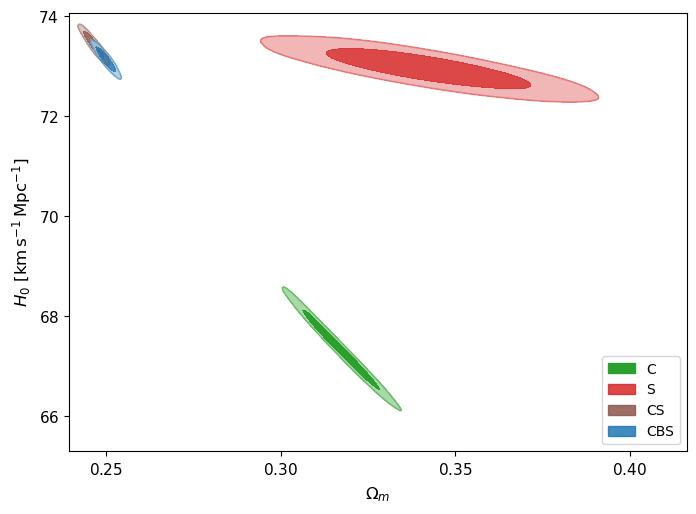

In [42]:
lcdm_compatibility_order = ["C", "S", "CS", "CBS"]

if chains_available_for(
    "LCDM",
    lcdm_compatibility_order,
):
    lcdm_compatibility_samples = [
        load_getdist_samples(
            "LCDM",
            combination_id,
        )
        for combination_id in lcdm_compatibility_order
    ]

    lcdm_compatibility_colors = [
        COMBINATION_COLORS[combination_id]
        for combination_id in lcdm_compatibility_order
    ]

    g = plots.get_single_plotter(width_inch=7)

    g.settings.num_plot_contours = 2
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize = 11
    g.settings.lab_fontsize = 12
    g.settings.legend_fontsize = 10

    g.plot_2d(
        lcdm_compatibility_samples,
        "Omega_m",
        "H0",
        filled=True,
        colors=lcdm_compatibility_colors,
    )

    ax = plt.gca()

    ax.set_xlabel(r"$\Omega_m$")
    ax.set_ylabel(
        r"$H_0\ [{\rm km\,s^{-1}\,Mpc^{-1}}]$"
    )

    g.add_legend(
        lcdm_compatibility_order,
        legend_loc="lower right",
    )

    export_getdist_plot(
        g,
        FIGURES_DIR / "lcdm",
        "lcdm_contours_Omega_m_H0",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan una o más cadenas "
        "LCDM necesarias para C, S, CS y CBS."
    )

Las distribuciones individuales C y S ocupan regiones claramente separadas del plano $(\Omega_m,H_0)$. La combinación de ambas sondas desplaza el posterior hacia valores elevados de $H_0$ y valores de $\Omega_m$ considerablemente menores que los favorecidos individualmente por CMB.

La incorporación de BAO en CBS modifica solo parcialmente este compromiso. No obstante, la estrechez de las regiones CS y CBS no constituye por sí misma una indicación de consistencia entre las sondas. La comparación de las contribuciones individuales al $\chi^2$, presentada más adelante, muestra que estos ajustes conjuntos implican un deterioro importante respecto a los ajustes individuales.

Además, los resultados que contienen S deben interpretarse teniendo en cuenta la limitación metodológica identificada en la implementación de Pantheon+SH0ES utilizada en este trabajo.

#### Combinaciones conjuntas en el plano $(\Omega_m,H_0)$

Como complemento a la comparación entre las sondas individuales S y C, se muestran las tres combinaciones de dos sondas —BS, CB y CS— junto con la combinación global CBS.

Esta representación permite comparar directamente cómo depende la región conjunta del par de sondas considerado. Mientras BS y CB permanecen en regiones relativamente próximas al comportamiento de sus sondas constituyentes, CS ocupa una región claramente desplazada. La incorporación adicional de BAO en CBS modifica parcialmente este compromiso, pero no elimina la separación respecto a BS y CB.

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


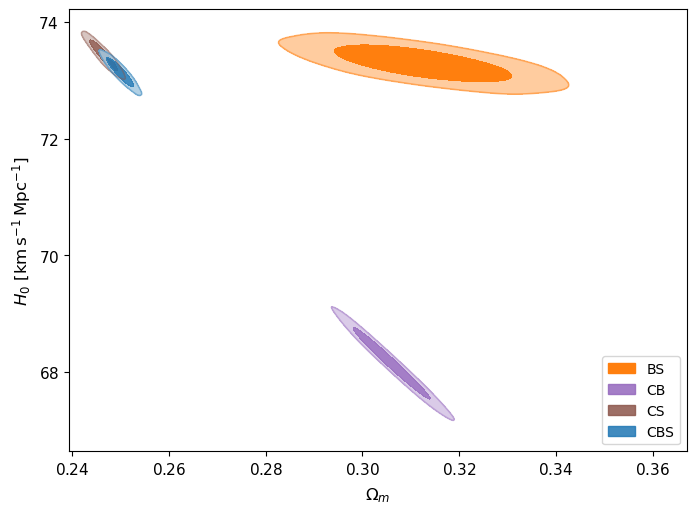

In [43]:
lcdm_joint_order = [
    "BS",
    "CB",
    "CS",
    "CBS",
]

if chains_available_for(
    "LCDM",
    lcdm_joint_order,
):
    lcdm_joint_samples = [
        load_getdist_samples(
            "LCDM",
            combination_id,
        )
        for combination_id in lcdm_joint_order
    ]

    lcdm_joint_colors = [
        COMBINATION_COLORS[combination_id]
        for combination_id in lcdm_joint_order
    ]

    g = plots.get_single_plotter(width_inch=7)

    g.settings.num_plot_contours = 2
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize = 11
    g.settings.lab_fontsize = 12
    g.settings.legend_fontsize = 10

    g.plot_2d(
        lcdm_joint_samples,
        "Omega_m",
        "H0",
        filled=True,
        colors=lcdm_joint_colors,
    )

    ax = plt.gca()

    ax.set_xlabel(r"$\Omega_m$")
    ax.set_ylabel(
        r"$H_0\ [{\rm km\,s^{-1}\,Mpc^{-1}}]$"
    )

    g.add_legend(
        lcdm_joint_order,
        legend_loc="lower right",
    )

    export_getdist_plot(
        g,
        FIGURES_DIR / "lcdm",
        "lcdm_contours_Omega_m_H0_combinations",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan una o más "
        "cadenas LCDM para BS, CB, CS y CBS."
    )

#### Nota metodológica sobre Pantheon+SH0ES

La inspección de los resultados de $\Lambda$CDM puso de manifiesto una precisión anormalmente alta en $H_0$ para las combinaciones que contienen Pantheon+SH0ES, lo que motivó una auditoría específica de la implementación utilizada en este trabajo.

El preprocesado aplicado elimina, tras la eliminación previa de duplicados, las SNe calibradoras mediante el corte $\mu>35$. Los objetos restantes se incorporan posteriormente utilizando directamente `MU_SH0ES` como módulo de distancia calibrado. Por tanto, la información central de la calibración absoluta de SH0ES permanece incorporada en los datos utilizados.

La auditoría permitió comprobar que la elevada precisión de $H_0$ no se origina en el muestreo MCMC. Una minimización directa de la misma likelihood reproduce tanto el valor central obtenido en las cadenas como una incertidumbre local de aproximadamente

$$
\sigma(H_0)\simeq0.27\ {\rm km\,s^{-1}\,Mpc^{-1}},
$$

muy inferior a la incertidumbre de aproximadamente $1.1\ {\rm km\,s^{-1}\,Mpc^{-1}}$ obtenida en el análisis publicado de Pantheon+SH0ES al incluir las distancias de los anfitriones con Cefeidas y su covarianza. 

Estos resultados indican que la precisión excesiva es una propiedad de la likelihood implementada y no un artefacto del muestreo. Una explicación plausible es que `MU_SH0ES` conserva el valor central de la calibración absoluta, mientras que la construcción reducida empleada en este trabajo no propaga completamente la incertidumbre global asociada a dicha calibración de la misma forma que el tratamiento completo de Pantheon+SH0ES, que utiliza conjuntamente las SNe del flujo de Hubble, las SNe calibradoras y la información de covarianza correspondiente. 

No obstante, la auditoría realizada no permite atribuir de forma matemática y exclusiva esta diferencia a la eliminación de las calibradoras ni reconstruir a posteriori una corrección exacta de la likelihood. Por esta razón, los resultados obtenidos se mantienen como resultados válidos de la implementación efectivamente utilizada, pero no deben interpretarse como una reproducción de la precisión oficial de Pantheon+SH0ES.

La consecuencia principal para el análisis es que S ejerce una restricción sobre la escala absoluta de distancias mucho más fuerte que la esperada en el tratamiento publicado. Al combinarse con sondas que favorecen una región cosmológica diferente, esta precisión puede modificar de forma importante el compromiso multidimensional entre parámetros. Por ello, los resultados de S, BS, CS y CBS se interpretan condicionados por esta limitación, especialmente en las restricciones sobre $H_0$ y en los desplazamientos de otros parámetros cosmológicos.

Esta cautela se extenderá posteriormente a los modelos dinámicos y a la comparación transversal entre modelos.

#### Resumen de restricciones de $\Lambda$CDM

In [44]:
lcdm_summary_parameters = [
    "Omega_m",
    "H0",
    "H0rd",
    "omega_b",
]

lcdm_summary_table = build_constraint_table(
    model_id="LCDM",
    parameters=lcdm_summary_parameters,
    level=68,
)

lcdm_summary_table

,$\Omega_m$,$H_0$,$H_0 r_d$,$\omega_b$
Combinación,,,,
B,$0.2946^{+0.0146}_{-0.0144}$,—,$10189^{+121}_{-121}$,—
S,$0.3415^{+0.0199}_{-0.0187}$,$72.95^{+0.27}_{-0.26}$,—,—
C,$0.3170^{+0.0074}_{-0.0072}$,$67.33^{+0.53}_{-0.53}$,—,$0.02237^{+0.00014}_{-0.00015}$
BS,$0.3122^{+0.0125}_{-0.0116}$,$73.29^{+0.20}_{-0.20}$,$10049^{+104}_{-103}$,—
CB,$0.3058^{+0.0056}_{-0.0051}$,$68.17^{+0.38}_{-0.43}$,—,$0.02251^{+0.00013}_{-0.00014}$
CS,$0.2465^{+0.0018}_{-0.0019}$,$73.43^{+0.17}_{-0.18}$,—,$0.02357^{+0.00010}_{-0.00010}$
CBS,$0.2500^{+0.0018}_{-0.0019}$,$73.13^{+0.16}_{-0.15}$,—,$0.02360^{+0.00011}_{-0.00011}$


Los valores corresponden a la mediana y al intervalo creíble central del 68 %. El símbolo `—` indica que el parámetro correspondiente no forma parte de la parametrización utilizada para esa combinación de datos.

Todas las combinaciones se mantienen en el análisis. No obstante, los resultados que contienen SNIa (S, BS, CS y CBS) deben interpretarse teniendo en cuenta la limitación metodológica de la implementación de Pantheon+SH0ES descrita anteriormente, especialmente cuando la conclusión dependa de la precisión de la escala absoluta.

#### Restricciones sobre $\Omega_m$

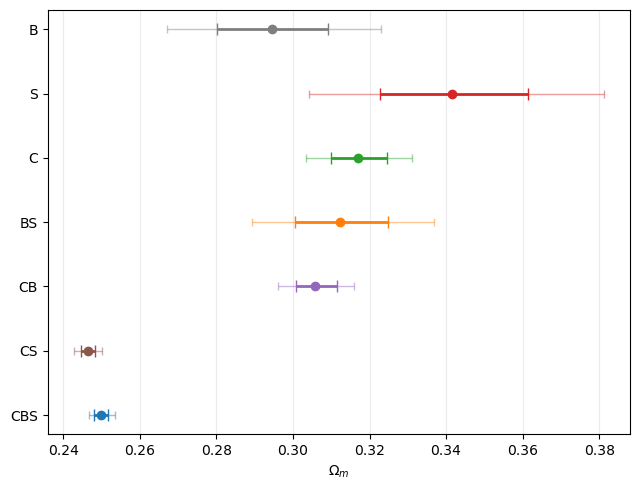

In [45]:
fig, ax, lcdm_omega_m = plot_parameter_constraints(
    model_id="LCDM",
    parameter="Omega_m",
    figsize=(6.5, 5.0),
)

save_matplotlib_figure(
    fig,
    FIGURES_DIR / "lcdm",
    "lcdm_constraints_Omega_m",
)

plt.show()

Las restricciones sobre $\Omega_m$ muestran comportamientos diferentes según las sondas combinadas. BS y CB permanecen en regiones próximas a las favorecidas por las sondas individuales, mientras que la combinación simultánea de SNIa y CMB produce un desplazamiento mucho más acusado.

En particular, CS alcanza $\Omega_m\simeq0.247$, claramente por debajo de los valores obtenidos con S y C por separado. La incorporación adicional de BAO en CBS desplaza la posterior ligeramente hacia valores mayores, hasta $\Omega_m\simeq0.250$, pero no recupera la región próxima a $\Omega_m\sim0.3$ favorecida por B, C y CB.

Este comportamiento debe interpretarse conjuntamente con la limitación metodológica de Pantheon+SH0ES descrita anteriormente y con el deterioro de la calidad del ajuste de CS y CBS que se examina posteriormente.

#### Restricciones sobre $H_0$

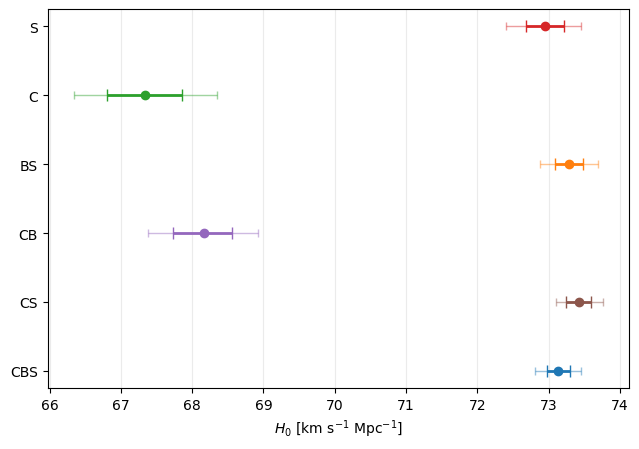

In [46]:
fig, ax, lcdm_h0 = plot_parameter_constraints(
    model_id="LCDM",
    parameter="H0",
    figsize=(6.5, 4.6),
)

save_matplotlib_figure(
    fig,
    FIGURES_DIR / "lcdm",
    "lcdm_constraints_H0",
)

plt.show()

Las restricciones sobre $H_0$ muestran una clara separación entre S y C dentro de $\Lambda$CDM. La implementación utilizada de Pantheon+SH0ES favorece valores próximos a $73\ {\rm km\,s^{-1}\,Mpc^{-1}}$, mientras que los distance priors de CMB sitúan la posterior alrededor de $67\ {\rm km\,s^{-1}\,Mpc^{-1}}$. La incorporación de BAO a CMB en CB produce únicamente un desplazamiento moderado hacia valores mayores.

Las combinaciones que contienen S permanecen cerca de la escala alta de $H_0$. En CS, el desplazamiento simultáneo hacia valores bajos de $\Omega_m$ permite incluso alcanzar un valor de $H_0$ ligeramente superior al obtenido con S por separado, reflejando la estructura correlacionada observada en el plano $(\Omega_m,H_0)$.

BAO modifica parcialmente este compromiso en CBS, aumentando $\Omega_m$ y reduciendo $H_0$ respecto a CS. No obstante, la elevada precisión de las combinaciones que contienen S está condicionada por la implementación de Pantheon+SH0ES y no debe interpretarse como una determinación equivalente a la likelihood oficial.

#### Restricciones sobre $\omega_b$

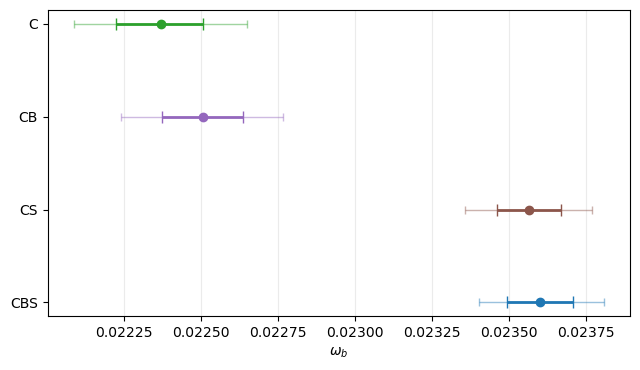

In [47]:
fig, ax, lcdm_omega_b = plot_parameter_constraints(
    model_id="LCDM",
    parameter="omega_b",
    figsize=(6.5, 3.8),
)

save_matplotlib_figure(
    fig,
    FIGURES_DIR / "lcdm",
    "lcdm_constraints_omega_b",
)

plt.show()

La interpretación de $\omega_b$ requiere tener en cuenta que este parámetro forma parte directamente del vector de observables utilizado en la likelihood comprimida de CMB,

$$
(R,\ell_A,\omega_b).
$$

Por esta razón, el valor obtenido con C, $\omega_b\simeq0.02237$, reproduce esencialmente la información incorporada directamente por los distance priors y no constituye una determinación independiente de la estabilidad de $\omega_b$ frente al modelo cosmológico.

La incorporación de BAO en CB desplaza solo ligeramente esta restricción, hasta $\omega_b\simeq0.02251$. En cambio, las combinaciones CS y CBS alcanzan valores próximos a $\omega_b\simeq0.0236$, notablemente alejados del valor directamente favorecido por la componente $\omega_b$ de la likelihood CMB.

Este desplazamiento resulta especialmente informativo precisamente porque ocurre frente a una restricción directa de CMB sobre $\omega_b$. Como se mostrará al estudiar las contribuciones al $\chi^2$, las soluciones CS y CBS pagan simultáneamente un coste elevado en la likelihood CMB. Por tanto, estos valores deben entenderse como parte del compromiso alcanzado por la likelihood conjunta implementada y no como evidencia de una preferencia independiente de CMB por una densidad bariónica mayor.

#### Calidad del ajuste y deterioro al combinar sondas

Las contribuciones al $\chi^2$ se evalúan en el mejor punto realmente muestreado de cada cadena. Por tanto, constituyen un diagnóstico de la calidad de ajuste alcanzada, pero no deben identificarse con mínimos globales obtenidos mediante una optimización independiente.

Para cada sonda se compara además cuánto aumenta su contribución al incorporarla a ajustes conjuntos. En BAO se mantienen separadas las dos implementaciones utilizadas en el análisis: B y BS emplean la parametrización efectiva $H_0r_d$, mientras que CB y CBS utilizan la rama física en la que $r_d$ se calcula a partir de los parámetros cosmológicos.

In [48]:
lcdm_delta_chi2 = build_probe_delta_chi2_table(
    model_id="LCDM"
)

lcdm_delta_chi2.round(2)

,Sonda,Comparación,$\Delta\chi^2$
0,BAO,BS - B,1.53
1,BAO,CBS - CB,36.37
2,SN,BS - S,2.31
3,SN,CS - S,44.38
4,SN,CBS - S,56.53
5,CMB,CB - C,2.15
6,CMB,CS - C,125.32
7,CMB,CBS - C,116.55


In [49]:
lcdm_chi2_contributions = build_chi2_contribution_table(
    model_id="LCDM"
)

lcdm_chi2_contributions.round(2)

,Total,BAO,SN,CMB
Combinación,,,,
B,12.74,12.74,NaN,NaN
S,1135.42,NaN,1135.42,NaN
C,0.00,NaN,NaN,0.00
BS,1151.99,14.27,1137.73,NaN
CB,17.78,15.63,NaN,2.16
CS,1305.12,NaN,1179.80,125.32
CBS,1360.50,52.00,1191.95,116.56


Las combinaciones BS y CB producen deterioros relativamente moderados respecto a los ajustes de referencia de las sondas individuales. En BS, tanto SNIa como BAO mantienen contribuciones próximas a las obtenidas por separado, mientras que en CB el coste adicional de CMB sigue siendo reducido.

El comportamiento cambia de forma marcada cuando SNIa y CMB se incluyen simultáneamente. Tanto CS como CBS requieren aumentos muy grandes de las contribuciones de SNIa y CMB respecto a sus mejores puntos muestreados individuales. En CBS, BAO también experimenta un deterioro considerable respecto a CB cuando ambas combinaciones se comparan dentro de la misma rama física de la likelihood BAO.

Por tanto, las regiones posteriores estrechas obtenidas en CS y CBS no deben interpretarse como una simple ganancia de precisión debida a la combinación de sondas. Representan un compromiso dentro de la likelihood conjunta implementada que se encuentra alejado de las regiones favorecidas por cada sonda por separado.

Las diferencias de $\chi^2$ mostradas aquí tienen únicamente carácter diagnóstico. No se utilizan como una medida formal de la significancia estadística de la incompatibilidad entre datasets.

#### Síntesis de los resultados de $\Lambda$CDM

El análisis de $\Lambda$CDM muestra una diferencia clara entre las combinaciones que pueden acomodarse con desplazamientos relativamente moderados y aquellas que fuerzan un compromiso mucho más acusado entre sondas.

Las combinaciones B, C, BS y CB presentan un comportamiento comparativamente regular dentro del espacio de parámetros de $\Lambda$CDM. En particular, la incorporación de BAO a CMB en CB modifica de forma moderada las restricciones respecto a C, mientras que BS puede combinar BAO y SNIa sin un deterioro importante de sus contribuciones individuales al $\chi^2$.

El comportamiento cambia cuando SNIa y CMB se incorporan simultáneamente. Tanto CS como CBS desplazan la solución hacia valores bajos de $\Omega_m$ y elevados de $H_0$ respecto a las regiones favorecidas por C y S por separado. Estas combinaciones producen además aumentos muy importantes de las contribuciones de SNIa y CMB al $\chi^2$, por lo que la estrechez de sus posteriores no debe interpretarse como una indicación de compatibilidad entre las sondas.

La densidad física de bariones proporciona un diagnóstico adicional de este compromiso. Dado que $\omega_b$ forma parte directamente del vector de distance priors de CMB, el valor obtenido con C está fuertemente informado por la propia likelihood comprimida. Frente a esta restricción directa, CS y CBS requieren un desplazamiento considerable de $\omega_b$ hacia valores próximos a $0.0236$, acompañado simultáneamente de un coste elevado en la contribución de CMB al $\chi^2$.

La incorporación de BAO en CBS modifica parcialmente la solución obtenida con CS, aumentando $\Omega_m$ y reduciendo $H_0$, pero no elimina el compromiso entre las sondas. Además, BAO experimenta en CBS un deterioro apreciable respecto a CB cuando ambas combinaciones se comparan dentro de la misma rama física de la likelihood. Las comparaciones que involucren B o BS deben mantener separada esta cuestión de la rama efectiva basada en $H_0r_d$.

Los resultados que contienen S están condicionados por la limitación metodológica identificada en la implementación de Pantheon+SH0ES. La auditoría realizada muestra que la elevada precisión de la escala absoluta es una propiedad de la likelihood implementada y no del muestreo MCMC. Aunque la explicación más plausible está relacionada con una propagación incompleta de la incertidumbre global de calibración respecto al tratamiento publicado, no se ha establecido una causa matemática exclusiva ni una corrección exacta a posteriori.

Por este motivo, S, BS, CS y CBS se mantienen como resultados válidos de la implementación efectivamente utilizada, pero las conclusiones que dependan de su elevada precisión deben interpretarse con cautela.

Finalmente, las comparaciones de $\chi^2$ presentadas en esta sección se basan en los mejores puntos realmente muestreados por las cadenas. Se utilizan como diagnóstico de cómo se distribuye el coste del ajuste entre sondas y no como una medida formal de significancia estadística de su posible incompatibilidad.

En conjunto, $\Lambda$CDM proporciona el escenario de referencia frente al que se evaluará posteriormente si la libertad adicional de los modelos dinámicos permite redistribuir o reducir estos compromisos entre datasets.

#### Análisis complementario de $\Lambda$CDM

Esta sección reúne visualizaciones y diagnósticos que amplían los resultados principales de $\Lambda$CDM sin ser necesarios para seguir la narrativa central.

Se incluyen los posteriores marginales unidimensionales, la extensión de las regiones de SNIa y CMB hacia las colas posteriores y la restricción efectiva sobre $H_0r_d$ en las ramas de BAO que utilizan esta parametrización.

##### Posteriores marginales unidimensionales

Los posteriores 1D permiten inspeccionar la forma completa de las distribuciones marginales y complementan el resumen basado en medianas e intervalos creíbles.

Se representan únicamente las combinaciones en las que cada parámetro forma parte de la parametrización correspondiente.

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


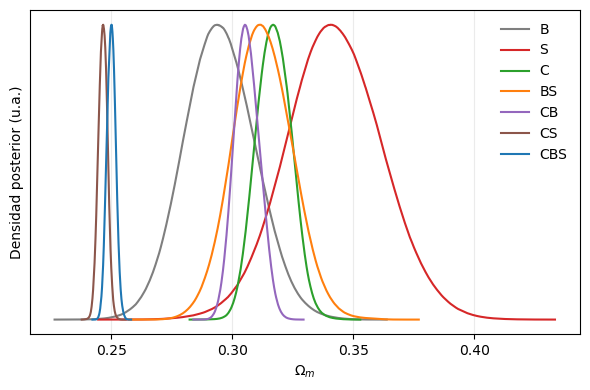

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


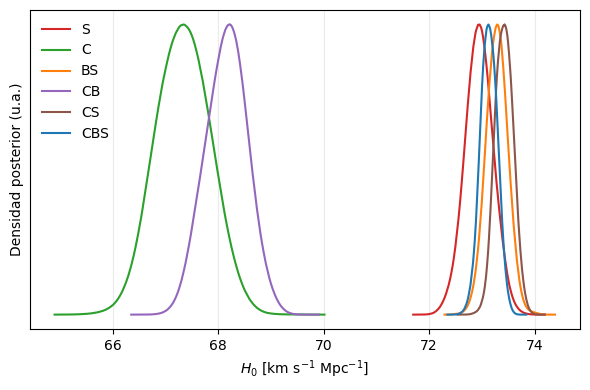

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


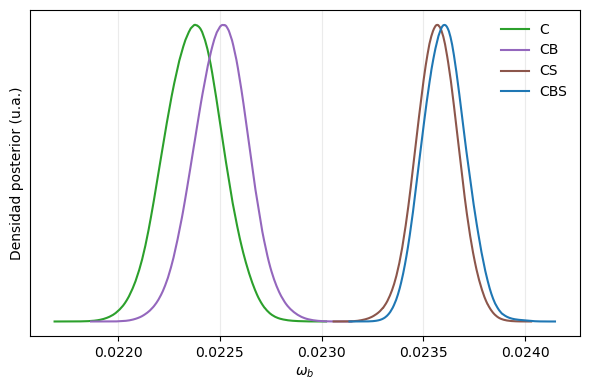

In [50]:
lcdm_1d_specs = [
    {
        "parameter": "Omega_m",
        "combination_ids": COMBINATION_ORDER,
        "figsize": (6.0, 4.0),
    },
    {
        "parameter": "H0",
        "combination_ids": [
            "S",
            "C",
            "BS",
            "CB",
            "CS",
            "CBS",
        ],
        "figsize": (6.0, 4.0),
    },
    {
        "parameter": "omega_b",
        "combination_ids": [
            "C",
            "CB",
            "CS",
            "CBS",
        ],
        "figsize": (6.0, 4.0),
    },
]

for spec in lcdm_1d_specs:
    required_combinations = spec["combination_ids"]

    if not chains_available_for(
        "LCDM",
        required_combinations,
    ):
        print(
            "Figura no regenerada para "
            f"{spec['parameter']}: faltan cadenas."
        )
        continue

    samples_dict = {
        combination_id: load_getdist_samples(
            "LCDM",
            combination_id,
        )
        for combination_id in required_combinations
    }

    fig, ax = plot_1d_posteriors(
        samples_dict=samples_dict,
        parameter=spec["parameter"],
        combination_ids=required_combinations,
        figsize=spec["figsize"],
    )

    save_matplotlib_figure(
        fig,
        FIGURES_DIR / "lcdm",
        f"lcdm_1d_{spec['parameter']}",
    )

    plt.show()

##### Extensión de las regiones de SNIa y CMB hacia las colas posteriores

Dada la separación observada entre SNIa y CMB en el plano $(\Omega_m,H_0)$, se amplían sus regiones creíbles hasta el 99.7 %.

Las medianas de CS y CBS se muestran únicamente como referencias geométricas. Este diagnóstico permite visualizar la posición de los compromisos conjuntos respecto a las colas de las distribuciones individuales, pero no se utiliza para asignar una significancia estadística formal a la discrepancia entre datasets.

Removed no burn in
Removed no burn in


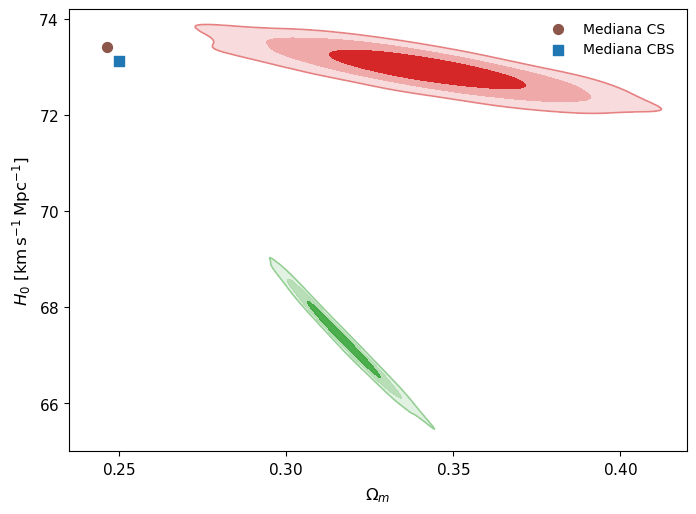

In [51]:
lcdm_tail_order = ["S", "C"]

if chains_available_for(
    "LCDM",
    lcdm_tail_order,
):
    lcdm_tail_samples = {
        combination_id: load_getdist_samples(
            "LCDM",
            combination_id,
        )
        for combination_id in lcdm_tail_order
    }

    for samples in lcdm_tail_samples.values():
        samples.updateSettings(
            {
                "contours": [
                    0.68,
                    0.95,
                    0.997,
                ]
            }
        )

    g = plots.get_single_plotter(width_inch=7)

    g.settings.num_plot_contours = 3
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize = 11
    g.settings.lab_fontsize = 12
    g.settings.legend_fontsize = 10

    g.plot_2d(
        [
            lcdm_tail_samples["S"],
            lcdm_tail_samples["C"],
        ],
        "Omega_m",
        "H0",
        filled=True,
        colors=[
            COMBINATION_COLORS["S"],
            COMBINATION_COLORS["C"],
        ],
    )

    ax = plt.gca()

    cs_omega_m = get_posterior_row(
        "LCDM",
        "CS",
        "Omega_m",
    )["median"]

    cs_h0 = get_posterior_row(
        "LCDM",
        "CS",
        "H0",
    )["median"]

    cbs_omega_m = get_posterior_row(
        "LCDM",
        "CBS",
        "Omega_m",
    )["median"]

    cbs_h0 = get_posterior_row(
        "LCDM",
        "CBS",
        "H0",
    )["median"]

    ax.scatter(
        cs_omega_m,
        cs_h0,
        marker="o",
        s=50,
        color=COMBINATION_COLORS["CS"],
        label="Mediana CS",
        zorder=10,
    )

    ax.scatter(
        cbs_omega_m,
        cbs_h0,
        marker="s",
        s=50,
        color=COMBINATION_COLORS["CBS"],
        label="Mediana CBS",
        zorder=10,
    )

    ax.set_xlabel(r"$\Omega_m$")
    ax.set_ylabel(
        r"$H_0\ [{\rm km\,s^{-1}\,Mpc^{-1}}]$"
    )

    ax.set_xlim(0.235, 0.42)
    ax.set_ylim(65.0, 74.2)

    ax.legend(frameon=False)

    export_getdist_plot(
        g,
        FIGURES_DIR / "lcdm",
        "lcdm_contours_Omega_m_H0_extended",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan las cadenas "
        "LCDM de S y/o C."
    )

##### Restricción efectiva sobre $H_0r_d$

En las ramas B y BS, BAO se parametriza mediante la combinación efectiva $H_0r_d$, por lo que estas cadenas no separan individualmente $H_0$ y $r_d$.

La comparación de sus posteriores permite visualizar cómo cambia esta combinación efectiva al incorporar SNIa. Este resultado se presenta como diagnóstico específico de la rama BAO utilizada sin información CMB y no se compara directamente con las combinaciones que emplean la rama física de $r_d$.

Removed no burn in
Removed no burn in


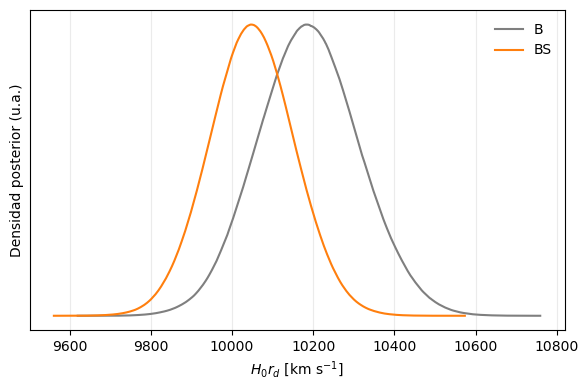

In [52]:
lcdm_h0rd_order = [
    "B",
    "BS",
]

if chains_available_for(
    "LCDM",
    lcdm_h0rd_order,
):
    lcdm_h0rd_samples = {
        combination_id: load_getdist_samples(
            "LCDM",
            combination_id,
        )
        for combination_id in lcdm_h0rd_order
    }

    fig, ax = plot_1d_posteriors(
        samples_dict=lcdm_h0rd_samples,
        parameter="H0rd",
        combination_ids=lcdm_h0rd_order,
        figsize=(6.0, 4.0),
    )

    save_matplotlib_figure(
        fig,
        FIGURES_DIR / "lcdm",
        "lcdm_1d_H0rd",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan las cadenas "
        "LCDM de B y/o BS."
    )

### CPL

Se analizan las restricciones obtenidas para la parametrización CPL,

$$
w(a)=w_0+w_a(1-a),
$$

cuyo límite de constante cosmológica corresponde a

$$
(w_0,w_a)=(-1,0).
$$

Se mantienen las siete combinaciones de datos utilizadas en $\Lambda$CDM. Al interpretar S, BS, CS y CBS se conserva la cautela metodológica asociada a la implementación de Pantheon+SH0ES descrita anteriormente.

Además de los parámetros cosmológicos estándar, el análisis se centra en la estructura conjunta de $(w_0,w_a)$, sus degeneraciones y su compatibilidad con el límite de $\Lambda$CDM.

#### Comprobaciones de validación

In [53]:
cpl_warning_tables = []

for combination_id in COMBINATION_ORDER:
    warnings = get_validation_warnings(
        model_id="CPL",
        combination_id=combination_id,
    )

    if not warnings.empty:
        cpl_warning_tables.append(warnings)

cpl_warnings = (
    pd.concat(cpl_warning_tables, ignore_index=True)
    if cpl_warning_tables
    else pd.DataFrame()
)

cpl_warnings

,model_id,model,combination_id,combination,disk_prefix,warning_type,warning_code,parameter,warning,evidence,warning_provenance
0,CPL,CPL,B,BAO,b_CPL_H0rd,interpretability,PRIOR_SENSITIVITY,H0rd,La marginal BAO-only de H0rd alcanza el límite...,sample_span_fraction=0.743236; max_edge_enrich...,INFERIDA
1,CPL,CPL,C,CMB,c_CPL,sampling,VERY_LOW_SAMPLING_EFFICIENCY,NaN,La cadena presenta aceptación muy baja y autoc...,acceptance_rate=0.010113; max_correlation_leng...,INFERIDA
2,CPL,CPL,C,CMB,c_CPL,interpretability,BROAD_CMB_ONLY_POSTERIOR,"H0,w0,wa",La combinación CMB-only presenta restricciones...,H0_span=0.999911; w0_span=0.999645; wa_max_edg...,INFERIDA


La validación de CPL identifica dos precauciones específicas.

La combinación B presenta sensibilidad al prior en $H_0r_d$. La posterior explora una región amplia del intervalo permitido y muestra una dependencia apreciable del volumen de prior, por lo que la restricción BAO-only sobre este parámetro no se interpreta como una determinación robusta independiente del prior.

La combinación C presenta una eficiencia de muestreo muy baja y posteriores extremadamente amplias en $H_0$, $w_0$ y $w_a$. La cadena se considera utilizable y no se identifica un fallo técnico del muestreo. Este comportamiento es coherente con las fuertes degeneraciones geométricas que permanecen al utilizar los distance priors de CMB en un modelo con varios parámetros de energía oscura.

La compresión utilizada cuenta con validación en la literatura para CPL frente a información CMB más completa, lo que respalda su uso como aproximación geométrica en este modelo. No obstante, la likelihood empleada aquí contiene únicamente la información comprimida en $(R,\ell_A,\omega_b)$ y no es equivalente a utilizar el espectro completo de anisotropías del CMB.

Por tanto, la amplitud de las posteriores CMB-only debe interpretarse principalmente como una limitación del contenido informativo de la likelihood comprimida para CPL, y no como evidencia de un problema de convergencia. Las restricciones marginales dominadas por estas degeneraciones o por el volumen de prior no se tratarán como determinaciones físicas robustas.

#### Parámetros de energía oscura

In [54]:
cpl_de_table = build_constraint_table(
    model_id="CPL",
    parameters=["w0", "wa"],
    level=68,
)

cpl_de_table

,$w_0$,$w_a$
Combinación,,
B,$0.549^{+0.513}_{-0.740}$,$-5.59^{+2.58}_{-1.92}$
S,$-0.838^{+0.164}_{-0.168}$,$-2.31^{+2.28}_{-3.92}$
C,$-0.118^{+1.041}_{-0.922}$,$-5.54^{+3.95}_{-3.12}$
BS,$-0.821^{+0.088}_{-0.080}$,$-0.68^{+0.71}_{-0.67}$
CB,$-0.201^{+0.490}_{-0.427}$,$-2.51^{+1.21}_{-1.48}$
CS,$-0.540^{+0.080}_{-0.077}$,$-2.61^{+0.36}_{-0.38}$
CBS,$-0.668^{+0.078}_{-0.076}$,$-2.20^{+0.35}_{-0.38}$


Las restricciones sobre $(w_0,w_a)$ dependen fuertemente de la combinación de datos considerada.

Las sondas B y C por separado dejan degeneraciones muy amplias en el sector de energía oscura. En B debe añadirse la sensibilidad al prior identificada durante la validación, mientras que en C los distance priors proporcionan principalmente información geométrica y dejan una gran libertad al ajustar simultáneamente los parámetros cosmológicos y dinámicos.

Las combinaciones que incorporan información complementaria de bajo redshift reducen considerablemente estas degeneraciones. En particular, BS, CS y CBS seleccionan regiones mucho más compactas del espacio $(w_0,w_a)$, aunque los resultados que contienen S permanecen condicionados por la implementación de Pantheon+SH0ES utilizada en este trabajo.

La compatibilidad con el límite de constante cosmológica $(w_0,w_a)=(-1,0)$ no se evalúa a partir de las marginales por separado, sino mediante la distribución conjunta en el plano $(w_0,w_a)$.

#### Sondas individuales y combinación global en el plano $(w_0,w_a)$

Las regiones conjuntas en el plano $(w_0,w_a)$ permiten comparar las degeneraciones producidas por cada sonda individual con la región seleccionada al combinar simultáneamente B, S y C.

El punto $(-1,0)$ indica el límite exacto de $\Lambda$CDM y se utiliza únicamente como referencia geométrica.

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


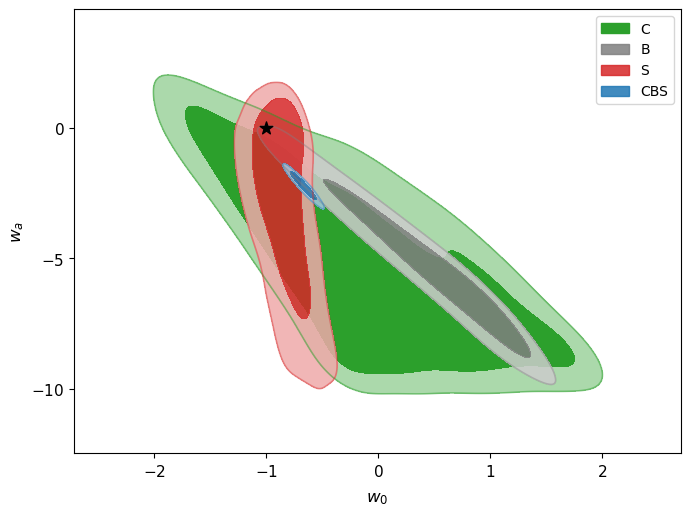

In [55]:
cpl_individual_global_order = [
    "C",
    "B",
    "S",
    "CBS",
]

if chains_available_for(
    "CPL",
    cpl_individual_global_order,
):
    cpl_individual_global_samples = [
        load_getdist_samples(
            "CPL",
            combination_id,
        )
        for combination_id in cpl_individual_global_order
    ]

    colors = [
        COMBINATION_COLORS[combination_id]
        for combination_id in cpl_individual_global_order
    ]

    g = plots.get_single_plotter(width_inch=7)

    g.settings.num_plot_contours = 2
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize = 11
    g.settings.lab_fontsize = 12
    g.settings.legend_fontsize = 10

    g.plot_2d(
        cpl_individual_global_samples,
        "w0",
        "wa",
        filled=True,
        colors=colors,
    )

    ax = plt.gca()

    ax.scatter(
        -1.0,
        0.0,
        marker="*",
        s=90,
        color=LCDM_REFERENCE_COLOR,
        label=r"$\Lambda$CDM",
        zorder=10,
    )

    ax.set_xlabel(r"$w_0$")
    ax.set_ylabel(r"$w_a$")

    g.add_legend(
        cpl_individual_global_order
        + [r"$\Lambda$CDM"],
        legend_loc="upper right",
    )

    export_getdist_plot(
        g,
        FIGURES_DIR / "cpl",
        "cpl_contours_w0_wa_individual_global",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan una o más cadenas CPL "
        "para C, B, S y CBS."
    )

#### Combinaciones de datos en el plano $(w_0,w_a)$

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


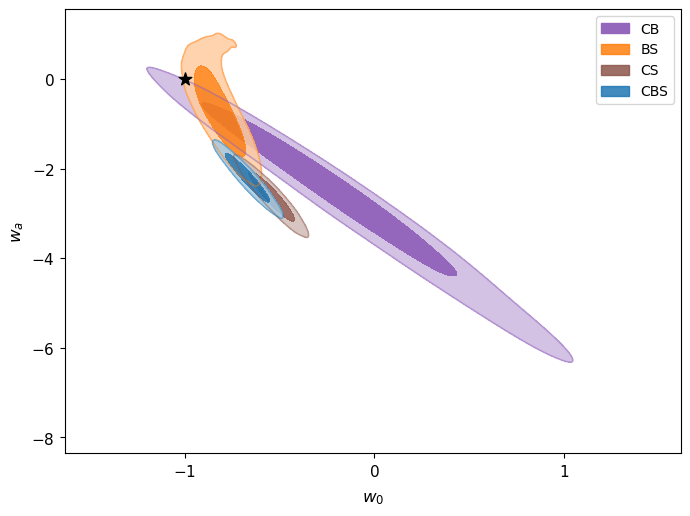

In [56]:
cpl_combination_order = [
    "CB",
    "BS",
    "CS",
    "CBS",
]

if chains_available_for(
    "CPL",
    cpl_combination_order,
):
    cpl_combination_samples = [
        load_getdist_samples(
            "CPL",
            combination_id,
        )
        for combination_id in cpl_combination_order
    ]

    colors = [
        COMBINATION_COLORS[combination_id]
        for combination_id in cpl_combination_order
    ]

    g = plots.get_single_plotter(width_inch=7)

    g.settings.num_plot_contours = 2
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize = 11
    g.settings.lab_fontsize = 12
    g.settings.legend_fontsize = 10

    g.plot_2d(
        cpl_combination_samples,
        "w0",
        "wa",
        filled=True,
        colors=colors,
    )

    ax = plt.gca()

    ax.scatter(
        -1.0,
        0.0,
        marker="*",
        s=90,
        color=LCDM_REFERENCE_COLOR,
        label=r"$\Lambda$CDM",
        zorder=10,
    )

    ax.set_xlabel(r"$w_0$")
    ax.set_ylabel(r"$w_a$")

    g.add_legend(
        cpl_combination_order
        + [r"$\Lambda$CDM"],
        legend_loc="upper right",
    )

    export_getdist_plot(
        g,
        FIGURES_DIR / "cpl",
        "cpl_contours_w0_wa_combinations",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan una o más cadenas CPL "
        "para CB, BS, CS y CBS."
    )

Las combinaciones de datos en el plano $(w_0,w_a)$ muestran comportamientos diferenciados. CB ocupa una región extensa y alargada, mientras que las combinaciones que contienen SNIa, en particular CS y CBS, presentan posteriores mucho más compactas.

Geométricamente, CB, CS y CBS comparten una dirección de degeneración muy similar, aunque con amplitudes muy distintas. BS muestra una orientación parcialmente diferente, pero desplaza la solución conjunta de forma apreciable al pasar de CS a CBS. En este sentido, la región final favorecida por CBS puede interpretarse como un compromiso entre la solución de CS y el efecto adicional introducido por BAO.

A diferencia de lo observado en el plano $(\Omega_m,H_0)$ de $\Lambda$CDM, el comportamiento de las combinaciones en el plano $(w_0,w_a)$ resulta cualitativamente más intuitivo: las restricciones conjuntas se sitúan dentro de regiones compatibles con las tendencias de las combinaciones parciales y no aparecen como una solución completamente separada de ellas.

El punto correspondiente a $\Lambda$CDM, $(w_0,w_a)=(-1,0)$, permanece relativamente próximo a las regiones amplias de BS y CB, pero queda claramente alejado de las regiones compactas de CS y CBS. Dentro de la likelihood implementada, estas dos combinaciones seleccionan por tanto una región posterior desplazada respecto al límite de $\Lambda$CDM. La interpretación física de este desplazamiento debe mantenerse condicionada por la limitación metodológica identificada en la implementación de Pantheon+SH0ES.

#### Parámetros cosmológicos estándar

In [57]:
cpl_standard_table = build_constraint_table(
    model_id="CPL",
    parameters=[
        "Omega_m",
        "H0",
        "omega_b",
    ],
    level=68,
)

cpl_standard_table

,$\Omega_m$,$H_0$,$\omega_b$
Combinación,,,
B,$0.4533^{+0.0499}_{-0.0734}$,—,—
S,$0.4165^{+0.0692}_{-0.1232}$,$72.51^{+0.45}_{-0.47}$,—
C,$0.2719^{+0.1715}_{-0.0943}$,$72.76^{+17.19}_{-15.80}$,$0.02236^{+0.00014}_{-0.00014}$
BS,$0.3158^{+0.0182}_{-0.0255}$,$72.59^{+0.38}_{-0.39}$,—
CB,$0.3685^{+0.0484}_{-0.0424}$,$62.55^{+3.84}_{-3.68}$,$0.02233^{+0.00014}_{-0.00014}$
CS,$0.2734^{+0.0034}_{-0.0034}$,$72.20^{+0.37}_{-0.36}$,$0.02251^{+0.00014}_{-0.00014}$
CBS,$0.2725^{+0.0033}_{-0.0035}$,$72.62^{+0.37}_{-0.34}$,$0.02247^{+0.00013}_{-0.00013}$


##### Densidad de materia $\Omega_m$

Las restricciones sobre $\Omega_m$ dependen de forma importante de la combinación de datos considerada. Las posteriores de B, S y especialmente C son amplias dentro de CPL, por lo que sus medianas no deben interpretarse aisladamente como determinaciones precisas del parámetro.

Las combinaciones de dos sondas reducen estas degeneraciones, aunque seleccionan regiones diferentes: BS favorece valores próximos a $\Omega_m\simeq0.316$, mientras que CB se desplaza hacia valores mayores, alrededor de $\Omega_m\simeq0.369$.

En cambio, CS selecciona una región próxima a $\Omega_m\simeq0.273$, y la incorporación adicional de BAO apenas modifica esta restricción en CBS, cuya mediana permanece alrededor de $\Omega_m\simeq0.273$.

Por tanto, dentro de CPL la combinación global no reproduce simplemente ninguna de las restricciones individuales, sino que emerge del compromiso multidimensional entre los parámetros cosmológicos y los parámetros de energía oscura.

##### Constante de Hubble $H_0$

CMB-only deja $H_0$ muy débilmente determinado en CPL. La amplitud de esta posterior refleja las degeneraciones geométricas que aparecen al permitir simultáneamente libertad en $(\Omega_m,H_0,w_0,w_a)$, por lo que su valor central no debe interpretarse como una preferencia física robusta.

La situación es distinta en las combinaciones que contienen S. Debido a la elevada precisión de la escala absoluta en la implementación de Pantheon+SH0ES utilizada, S, BS, CS y CBS permanecen todas en la región de $H_0\simeq72$--$73\ {\rm km\,s^{-1}\,Mpc^{-1}}$. Esta concentración está condicionada por la limitación metodológica descrita anteriormente y no debe identificarse con la precisión de la likelihood oficial de Pantheon+SH0ES.

La combinación CB constituye un caso especialmente informativo: sin la escala absoluta impuesta por S, la libertad adicional de CPL permite una solución con un valor de $H_0$ considerablemente menor, alrededor de $63\ {\rm km\,s^{-1}\,Mpc^{-1}}$. Esto ilustra la dependencia de la inferencia de $H_0$ respecto al modelo de energía oscura y a la combinación concreta de sondas.

##### Densidad física de bariones $\omega_b$

La interpretación de $\omega_b$ debe tener en cuenta que este parámetro forma parte directamente del vector de observables de los distance priors,

$$
(R,\ell_A,\omega_b).
$$

Por tanto, el valor obtenido con C está fuertemente informado de forma directa por la propia likelihood comprimida y no puede utilizarse como evidencia independiente de una predicción robusta de $\omega_b$ por parte de CPL.

Lo relevante al incorporar otras sondas es cuánto se desplaza la posterior respecto a esa información de CMB. En CPL, CB, CS y CBS permanecen en una región próxima a $\omega_b\simeq0.0223$--$0.0225$. En particular, CS y CBS no reproducen el fuerte desplazamiento hacia $\omega_b\simeq0.0236$ observado en $\Lambda$CDM.

Este comportamiento muestra que, dentro del espacio ampliado de CPL, las combinaciones que contienen S y C pueden alcanzar su solución conjunta manteniendo $\omega_b$ cerca del valor directamente informado por los distance priors. La calidad estadística de ese compromiso no se deduce de esta estabilidad aparente y se evaluará posteriormente mediante las contribuciones al $\chi^2$.

#### Calidad del ajuste y deterioro al combinar sondas

In [58]:
cpl_chi2_contributions = build_chi2_contribution_table(
    model_id="CPL"
)

cpl_chi2_contributions.round(2)

,Total,BAO,SN,CMB
Combinación,,,,
B,7.55,7.55,NaN,NaN
S,1134.59,NaN,1134.59,NaN
C,0.00,NaN,NaN,0.00
BS,1146.51,11.67,1134.84,NaN
CB,10.92,10.86,NaN,0.06
CS,1156.54,NaN,1154.43,2.11
CBS,1201.14,40.07,1160.48,0.58


In [59]:
cpl_delta_chi2 = build_probe_delta_chi2_table(
    model_id="CPL"
)

cpl_delta_chi2.round(2)

,Sonda,Comparación,$\Delta\chi^2$
0,BAO,BS - B,4.12
1,BAO,CBS - CB,29.22
2,SN,BS - S,0.25
3,SN,CS - S,19.84
4,SN,CBS - S,25.89
5,CMB,CB - C,0.06
6,CMB,CS - C,2.11
7,CMB,CBS - C,0.58


Las contribuciones al $\chi^2$ muestran que las combinaciones de dos sondas BS y CB pueden acomodarse dentro de CPL con deterioros relativamente moderados respecto a los ajustes de referencia correspondientes.

El comportamiento de CS es más exigente. Aunque la contribución de CMB permanece pequeña, la combinación requiere un coste apreciable en SNIa. Esta asimetría debe interpretarse teniendo en cuenta que los distance priors de CMB presentan fuertes degeneraciones dentro del espacio ampliado de CPL: una contribución pequeña de CMB no implica por sí sola que las sondas sean fuertemente compatibles, sino que existe un volumen amplio de parámetros capaz de reproducir los observables comprimidos.

En CBS, el coste del compromiso conjunto se concentra principalmente en SNIa y BAO, mientras que la contribución de CMB permanece del orden de la unidad. Para BAO, la comparación relevante es CBS frente a CB, ya que ambas utilizan la misma rama física de la likelihood. B y BS deben tratarse separadamente porque emplean la parametrización efectiva $H_0r_d$.

En conjunto, la libertad adicional de $(w_0,w_a)$ permite alcanzar regiones conjuntas con un deterioro mucho menor de la componente CMB que el observado previamente en $\Lambda$CDM. Esta observación se refiere exclusivamente a la likelihood comprimida de distance priors utilizada en el trabajo y no debe extrapolarse a una afirmación sobre la preferencia de la likelihood completa de CMB por energía oscura dinámica.

Las combinaciones que contienen S permanecen además condicionadas por la limitación metodológica de la implementación de Pantheon+SH0ES. Por ello, estas diferencias de $\chi^2$ se utilizan como diagnósticos descriptivos de cómo se distribuye el coste del ajuste entre sondas y no como una medida formal de la significancia de una posible incompatibilidad.

#### Síntesis de los resultados de CPL

La extensión CPL modifica de forma importante tanto las restricciones de las sondas individuales como el compromiso alcanzado al combinarlas.

B y C por separado presentan degeneraciones muy amplias en el sector de energía oscura. En B se añade la sensibilidad al prior identificada para $H_0r_d$, mientras que los distance priors de CMB dejan una gran libertad en $(H_0,w_0,w_a)$. Por ello, los valores centrales obtenidos en estas cadenas no deben interpretarse aisladamente como determinaciones robustas de la dinámica de la energía oscura.

La combinación de sondas rompe gran parte de estas degeneraciones. En particular, CBS selecciona una región compacta del plano $(w_0,w_a)$ caracterizada por $w_0>-1$ y $w_a<0$, mientras que el límite de $\Lambda$CDM, $(-1,0)$, queda alejado de la región posterior principal. Esta característica se obtiene dentro de la likelihood implementada y debe interpretarse teniendo en cuenta la elevada precisión de la escala absoluta asociada a S.

La libertad adicional de CPL también modifica los parámetros cosmológicos estándar. CS y CBS convergen hacia $\Omega_m\simeq0.27$, frente a los valores próximos a $0.25$ obtenidos para estas combinaciones en $\Lambda$CDM. Por su parte, las combinaciones que contienen CMB mantienen $\omega_b$ cerca del valor directamente informado por los distance priors, sin requerir el desplazamiento hacia $\omega_b\simeq0.0236$ observado en CS y CBS dentro de $\Lambda$CDM. Este comportamiento no constituye una predicción independiente de $\omega_b$, dado que dicho parámetro forma parte explícitamente del vector de observables de CMB utilizado.

La inferencia de $H_0$ continúa dependiendo fuertemente de la combinación de datos. CMB-only apenas determina esta escala dentro de CPL, mientras que las combinaciones que contienen S permanecen en la región de $72$--$73\ {\rm km\,s^{-1}\,Mpc^{-1}}$, condicionadas por la implementación de Pantheon+SH0ES. CB, sin SNIa, selecciona en cambio una solución alrededor de $63\ {\rm km\,s^{-1}\,Mpc^{-1}}$, mostrando la fuerte dependencia del resultado respecto al modelo y a las sondas utilizadas.

Las contribuciones al $\chi^2$ muestran además que la libertad dinámica permite redistribuir el coste del ajuste conjunto. En CS y CBS la componente CMB puede mantenerse cerca de su región favorecida gracias a las amplias degeneraciones permitidas por los distance priors, mientras que una parte mayor del deterioro se concentra en SNIa y BAO. Esta propiedad describe el comportamiento de la likelihood comprimida empleada y no implica que una likelihood CMB completa favorezca energía oscura dinámica.

En conjunto, CPL proporciona suficiente libertad para modificar de forma sustancial el compromiso entre las sondas y constituye el modelo dinámico de referencia para las comparaciones posteriores con CPL$_2$ y EXP. La valoración estadística formal frente a $\Lambda$CDM se realizará posteriormente mediante un criterio de comparación de modelos común.

#### Análisis complementario de CPL

Esta sección reúne diagnósticos adicionales que permiten inspeccionar con mayor detalle la forma de las posteriores y las degeneraciones de CPL sin interrumpir la narrativa principal del modelo.

Se recuperan los posteriores marginales unidimensionales, la ruptura de las degeneraciones de B y C al combinarlas y el comportamiento específico de la parametrización efectiva $H_0r_d$.

##### Posteriores marginales unidimensionales

Las distribuciones marginales permiten inspeccionar directamente asimetrías, regiones poco informativas y posibles dependencias del volumen de prior que quedan resumidas de forma incompleta mediante una única mediana y un intervalo creíble.

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


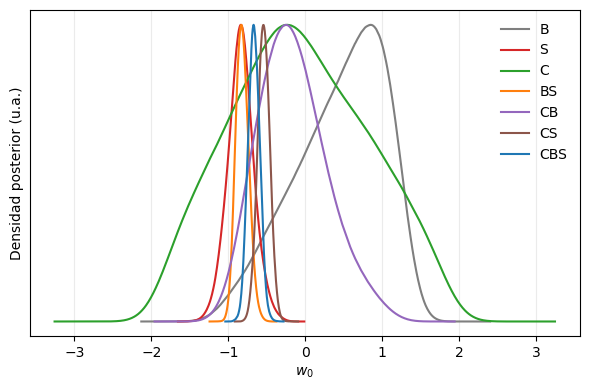

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


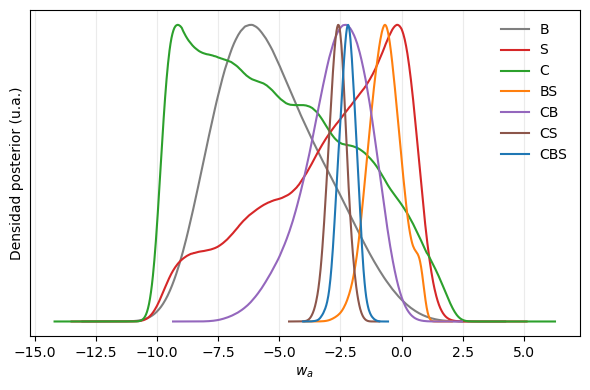

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


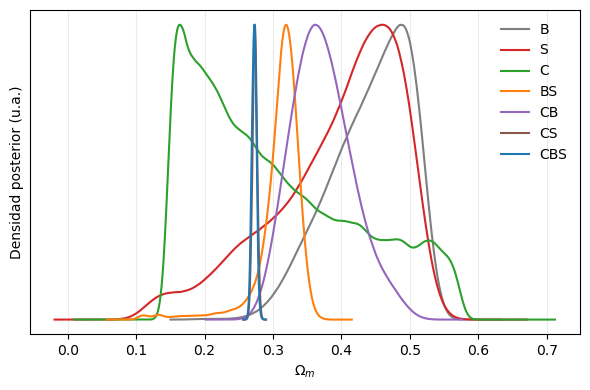

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


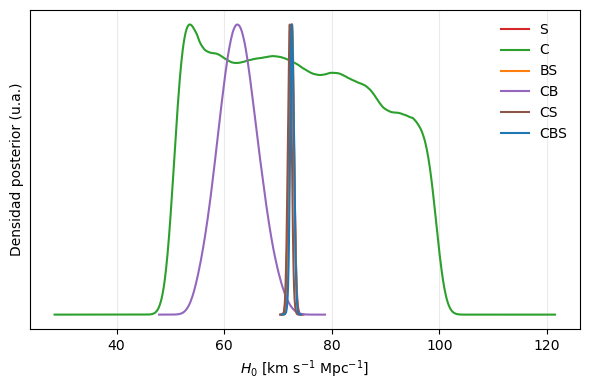

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


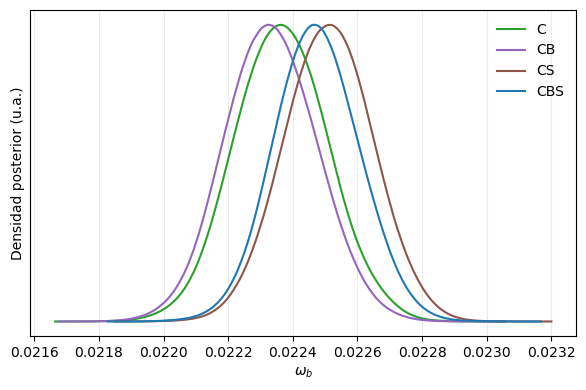

In [60]:
cpl_1d_specs = [
    {
        "parameter": "w0",
        "combination_ids": COMBINATION_ORDER,
    },
    {
        "parameter": "wa",
        "combination_ids": COMBINATION_ORDER,
    },
    {
        "parameter": "Omega_m",
        "combination_ids": COMBINATION_ORDER,
    },
    {
        "parameter": "H0",
        "combination_ids": [
            "S",
            "C",
            "BS",
            "CB",
            "CS",
            "CBS",
        ],
    },
    {
        "parameter": "omega_b",
        "combination_ids": [
            "C",
            "CB",
            "CS",
            "CBS",
        ],
    },
]

for spec in cpl_1d_specs:
    required_combinations = spec["combination_ids"]

    if not chains_available_for(
        "CPL",
        required_combinations,
    ):
        print(
            "Figura no regenerada para "
            f"{spec['parameter']}: faltan cadenas."
        )
        continue

    samples_dict = {
        combination_id: load_getdist_samples(
            "CPL",
            combination_id,
        )
        for combination_id in required_combinations
    }

    fig, ax = plot_1d_posteriors(
        samples_dict=samples_dict,
        parameter=spec["parameter"],
        combination_ids=required_combinations,
        figsize=(6.0, 4.0),
    )

    save_matplotlib_figure(
        fig,
        FIGURES_DIR / "cpl",
        f"cpl_1d_{spec['parameter']}",
    )

    plt.show()

##### Ruptura de las degeneraciones de B y C

Las sondas B y C por separado dejan degeneraciones extensas en el plano $(w_0,w_a)$. La combinación CB permite visualizar cómo la información geométrica complementaria de ambas sondas reduce parte de esa libertad y selecciona una región conjunta más acotada.

Esta figura se utiliza como diagnóstico de la estructura de las degeneraciones y no como comparación principal entre combinaciones de datos.

Removed no burn in
Removed no burn in
Removed no burn in


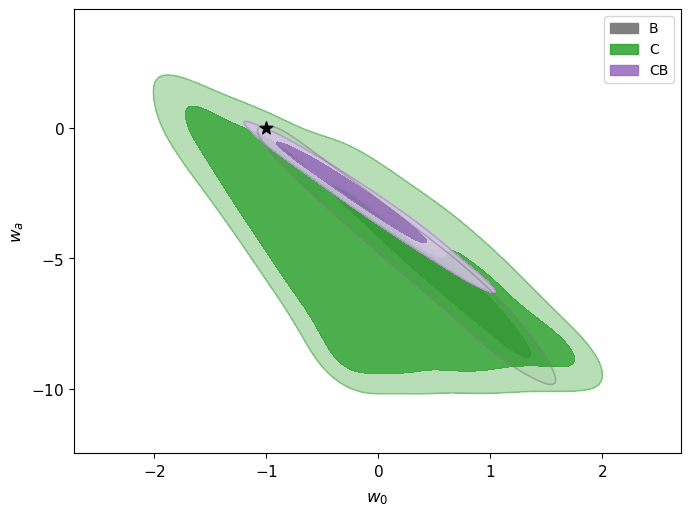

In [61]:
cpl_bc_order = [
    "B",
    "C",
    "CB",
]

if chains_available_for(
    "CPL",
    cpl_bc_order,
):
    cpl_bc_samples = [
        load_getdist_samples(
            "CPL",
            combination_id,
        )
        for combination_id in cpl_bc_order
    ]

    colors = [
        COMBINATION_COLORS[combination_id]
        for combination_id in cpl_bc_order
    ]

    g = plots.get_single_plotter(width_inch=7)

    g.settings.num_plot_contours = 2
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize = 11
    g.settings.lab_fontsize = 12
    g.settings.legend_fontsize = 10

    g.plot_2d(
        cpl_bc_samples,
        "w0",
        "wa",
        filled=True,
        colors=colors,
    )

    ax = plt.gca()

    ax.scatter(
        -1.0,
        0.0,
        marker="*",
        s=90,
        color=LCDM_REFERENCE_COLOR,
        label=r"$\Lambda$CDM",
        zorder=10,
    )

    ax.set_xlabel(r"$w_0$")
    ax.set_ylabel(r"$w_a$")

    g.add_legend(
        cpl_bc_order + [r"$\Lambda$CDM"],
        legend_loc="upper right",
    )

    export_getdist_plot(
        g,
        FIGURES_DIR / "cpl",
        "cpl_contours_w0_wa_B_C_CB",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan una o más "
        "cadenas CPL para B, C y CB."
    )

##### Restricción efectiva sobre $H_0r_d$

En B y BS, BAO se implementa mediante la combinación efectiva $H_0r_d$, sin separar individualmente $H_0$ y $r_d$.

La posterior B es especialmente amplia y presenta la sensibilidad al prior identificada durante la validación, por lo que su valor central no debe interpretarse como una determinación robusta de $H_0r_d$. La comparación con BS permite examinar cómo la incorporación de SNIa reduce esta degeneración dentro de la misma rama efectiva de la likelihood BAO.

Estas restricciones no se comparan directamente con CB o CBS, donde se utiliza la rama física de BAO y $r_d$ se calcula a partir de los parámetros cosmológicos.

Removed no burn in
Removed no burn in


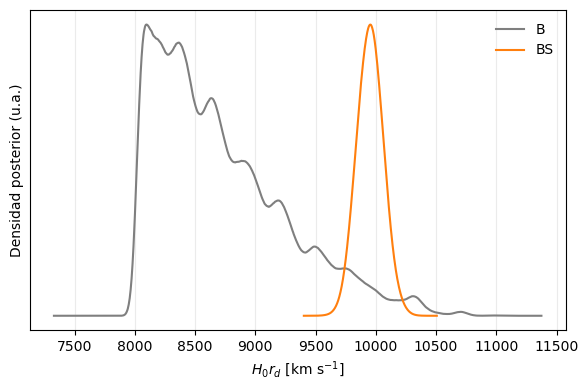

In [62]:
cpl_h0rd_order = [
    "B",
    "BS",
]

if chains_available_for(
    "CPL",
    cpl_h0rd_order,
):
    cpl_h0rd_samples = {
        combination_id: load_getdist_samples(
            "CPL",
            combination_id,
        )
        for combination_id in cpl_h0rd_order
    }

    fig, ax = plot_1d_posteriors(
        samples_dict=cpl_h0rd_samples,
        parameter="H0rd",
        combination_ids=cpl_h0rd_order,
        figsize=(6.0, 4.0),
    )

    save_matplotlib_figure(
        fig,
        FIGURES_DIR / "cpl",
        "cpl_1d_H0rd",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan las cadenas "
        "CPL de B y/o BS."
    )

### CPL$_2$

Se analizan a continuación las restricciones obtenidas para la parametrización fenomenológica CPL$_2$,

$$
w(a)=w_0+w_2(1-a)^2,
$$

cuyo límite de constante cosmológica corresponde a

$$
(w_0,w_2)=(-1,0).
$$

La parametrización conserva el valor actual $w(1)=w_0$, pero introduce una dependencia cuadrática con $(1-a)$ en lugar de la evolución lineal de CPL. Por ello, los valores numéricos de $w_2$ y $w_a$ no son directamente comparables y la comparación física entre ambos modelos se realizará posteriormente mediante la reconstrucción de $w(z)$.

Se mantienen las siete combinaciones de datos utilizadas en los modelos anteriores. Las combinaciones que contienen S están sujetas a la cautela metodológica asociada a la implementación de Pantheon+SH0ES. Además, los distance priors de CMB se adoptan para CPL$_2$ como una aproximación geométrica, sin haberse realizado una validación independiente frente a una likelihood CMB completa para esta parametrización.

#### Comprobaciones de validación

In [63]:
cpl2_warning_tables = []

for combination_id in COMBINATION_ORDER:
    warnings = get_validation_warnings(
        model_id="CPL2",
        combination_id=combination_id,
    )

    if not warnings.empty:
        cpl2_warning_tables.append(warnings)

cpl2_warnings = (
    pd.concat(cpl2_warning_tables, ignore_index=True)
    if cpl2_warning_tables
    else pd.DataFrame()
)

cpl2_warnings

,model_id,model,combination_id,combination,disk_prefix,warning_type,warning_code,parameter,warning,evidence,warning_provenance
0,CPL2,CPL2,C,CMB,c_CPLn2,sampling,VERY_LOW_SAMPLING_EFFICIENCY,NaN,La cadena presenta aceptación próxima al 1 % y...,acceptance_rate=0.010360; max_correlation_leng...,INFERIDA
1,CPL2,CPL2,C,CMB,c_CPLn2,interpretability,BROAD_CMB_ONLY_POSTERIOR,"H0,w2",La combinación CMB-only presenta posteriores m...,H0_span=0.999958; w2_span=0.889853; w2_max_edg...,INFERIDA


La combinación CMB-only de CPL$_2$ presenta una eficiencia de muestreo muy baja y posteriores especialmente amplias en $H_0$ y $w_2$. La cadena se considera técnicamente utilizable, por lo que este comportamiento no se interpreta como un fallo del muestreo.

La amplitud de estas restricciones refleja principalmente las fuertes degeneraciones geométricas que permanecen cuando los distance priors de CMB se utilizan en un modelo con varios parámetros de energía oscura. En consecuencia, una posterior amplia o parcialmente dominada por el volumen de prior no constituye por sí sola evidencia de un problema de convergencia.

A diferencia de CPL, la advertencia automática de posterior amplia no incluye $w_0$. Esto no demuestra que CMB-only proporcione una determinación robusta de dicho parámetro: únicamente indica que la degeneración extrema identificada por los diagnósticos se concentra principalmente en $H_0$ y $w_2$.

Esta cautela es especialmente relevante en CPL$_2$, ya que la compresión CMB utilizada no fue validada específicamente frente a una likelihood CMB completa para esta parametrización. Las restricciones CMB-only se conservan como resultado de la aproximación geométrica implementada, pero no se tratarán como determinaciones robustas de la dinámica de la energía oscura.

#### Parámetros de energía oscura

In [64]:
cpl2_de_table = build_constraint_table(
    model_id="CPL2",
    parameters=["w0", "w2"],
    level=68,
)

cpl2_de_table

,$w_0$,$w_2$
Combinación,,
B,$-0.076^{+0.405}_{-0.462}$,$-10.737^{+5.029}_{-4.780}$
S,$-0.967^{+0.184}_{-0.169}$,$-3.515^{+4.336}_{-8.134}$
C,$-0.527^{+0.865}_{-0.736}$,$-10.731^{+7.269}_{-6.424}$
BS,$-0.867^{+0.071}_{-0.058}$,$-1.667^{+2.377}_{-1.759}$
CB,$-0.658^{+0.266}_{-0.225}$,$-3.017^{+1.597}_{-2.064}$
CS,$-0.727^{+0.056}_{-0.054}$,$-5.942^{+0.850}_{-0.941}$
CBS,$-0.843^{+0.053}_{-0.051}$,$-4.780^{+0.832}_{-0.918}$


Las restricciones marginales sobre $(w_0,w_2)$ dependen fuertemente de la combinación de datos. Las sondas individuales dejan una libertad considerable, especialmente en $w_2$, cuyas posteriores presentan formas amplias y fuertemente correlacionadas con el resto de parámetros.

Las combinaciones de sondas reducen estas degeneraciones de forma sustancial. En particular, CS y CBS seleccionan valores de $w_0>-1$ y $w_2<0$, mientras que BS ocupa una región menos extrema del espacio de parámetros.

La magnitud numérica de $w_2$ no debe compararse directamente con la de $w_a$ en CPL, ya que ambos parámetros multiplican dependencias funcionales diferentes con el factor de escala. Por esta razón, la comparación entre las dos parametrizaciones se reservará para la reconstrucción posterior de $w(z)$.

La compatibilidad con $\Lambda$CDM tampoco se juzga a partir de los intervalos marginales de $w_0$ y $w_2$ por separado, sino a partir de su distribución conjunta en el plano $(w_0,w_2)$.

#### Sondas individuales y combinación global en el plano $(w_0,w_2)$

Las regiones conjuntas permiten comparar las degeneraciones producidas por cada sonda individual con la región seleccionada al combinar simultáneamente B, S y C.

El punto $(-1,0)$ representa el límite de $\Lambda$CDM y se utiliza como referencia geométrica. Dado que CPL$_2$ posee una dependencia funcional diferente de CPL, la posición de las regiones en este plano no permite por sí sola comparar directamente la intensidad de la evolución entre ambos modelos.

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


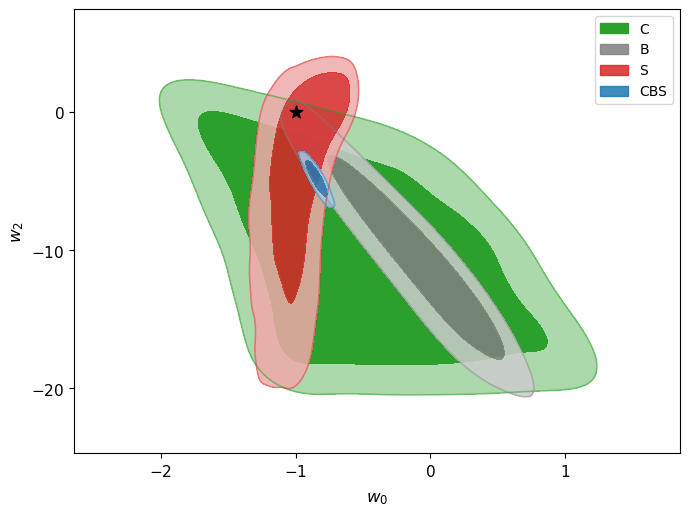

In [65]:
cpl2_individual_global_order = [
    "C",
    "B",
    "S",
    "CBS",
]

if chains_available_for(
    "CPL2",
    cpl2_individual_global_order,
):
    cpl2_individual_global_samples = [
        load_getdist_samples(
            "CPL2",
            combination_id,
        )
        for combination_id in cpl2_individual_global_order
    ]

    colors = [
        COMBINATION_COLORS[combination_id]
        for combination_id in cpl2_individual_global_order
    ]

    g = plots.get_single_plotter(width_inch=7)

    g.settings.num_plot_contours = 2
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize = 11
    g.settings.lab_fontsize = 12
    g.settings.legend_fontsize = 10

    g.plot_2d(
        cpl2_individual_global_samples,
        "w0",
        "w2",
        filled=True,
        colors=colors,
    )

    ax = plt.gca()

    ax.scatter(
        -1.0,
        0.0,
        marker="*",
        s=90,
        color=LCDM_REFERENCE_COLOR,
        label=r"$\Lambda$CDM",
        zorder=10,
    )

    ax.set_xlabel(r"$w_0$")
    ax.set_ylabel(r"$w_2$")

    g.add_legend(
        cpl2_individual_global_order
        + [r"$\Lambda$CDM"],
        legend_loc="upper right",
    )

    export_getdist_plot(
        g,
        FIGURES_DIR / "cpl2",
        "cpl2_contours_w0_w2_individual_global",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan una o más cadenas CPL2 "
        "para C, B, S y CBS."
    )

#### Comparación de combinaciones en el plano $(w_0,w_2)$

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


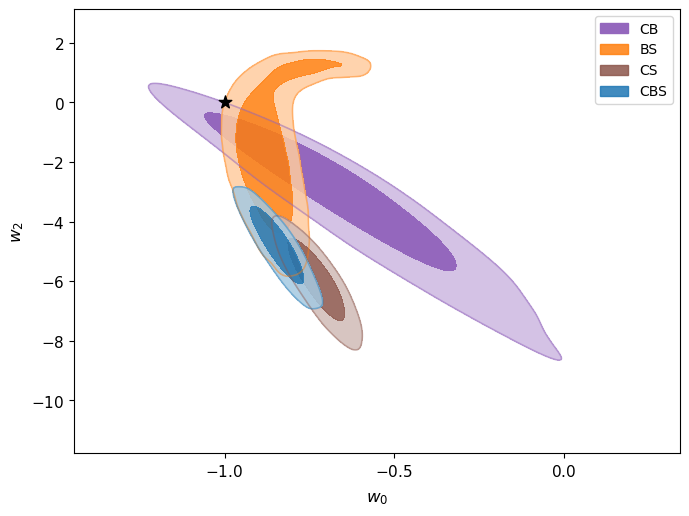

In [66]:
cpl2_combination_order = [
    "CB",
    "BS",
    "CS",
    "CBS",
]

if chains_available_for(
    "CPL2",
    cpl2_combination_order,
):
    cpl2_combination_samples = [
        load_getdist_samples(
            "CPL2",
            combination_id,
        )
        for combination_id in cpl2_combination_order
    ]

    colors = [
        COMBINATION_COLORS[combination_id]
        for combination_id in cpl2_combination_order
    ]

    g = plots.get_single_plotter(width_inch=7)

    g.settings.num_plot_contours = 2
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize = 11
    g.settings.lab_fontsize = 12
    g.settings.legend_fontsize = 10

    g.plot_2d(
        cpl2_combination_samples,
        "w0",
        "w2",
        filled=True,
        colors=colors,
    )

    ax = plt.gca()

    ax.scatter(
        -1.0,
        0.0,
        marker="*",
        s=90,
        color=LCDM_REFERENCE_COLOR,
        label=r"$\Lambda$CDM",
        zorder=10,
    )

    ax.set_xlabel(r"$w_0$")
    ax.set_ylabel(r"$w_2$")

    g.add_legend(
        cpl2_combination_order
        + [r"$\Lambda$CDM"],
        legend_loc="upper right",
    )

    export_getdist_plot(
        g,
        FIGURES_DIR / "cpl2",
        "cpl2_contours_w0_w2_combinations",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan una o más cadenas CPL2 "
        "para CB, BS, CS y CBS."
    )

Las combinaciones de datos seleccionan regiones diferenciadas del plano $(w_0,w_2)$. CB mantiene una región amplia y alargada, coherente con las fuertes degeneraciones permitidas por los distance priors de CMB cuando se combinan con BAO.

BS, CS y CBS reducen considerablemente el espacio permitido. Entre ellas, CS y CBS ocupan regiones próximas, mientras que la incorporación de BAO en CBS desplaza la posterior hacia valores de $w_0$ algo más próximos a $-1$ y modifica simultáneamente la restricción sobre $w_2$.

La geometría de estas regiones ilustra cómo la combinación de información complementaria entre sondas reduce las degeneraciones presentes en las posteriores individuales. Las combinaciones que contienen S deben interpretarse, no obstante, teniendo en cuenta la limitación metodológica de Pantheon+SH0ES.

#### Parámetros cosmológicos estándar

In [67]:
cpl2_standard_table = build_constraint_table(
    model_id="CPL2",
    parameters=[
        "Omega_m",
        "H0",
        "omega_b",
    ],
    level=68,
)

cpl2_standard_table

,$\Omega_m$,$H_0$,$\omega_b$
Combinación,,,
B,$0.4327^{+0.0539}_{-0.0628}$,—,—
S,$0.3775^{+0.0694}_{-0.1370}$,$72.73^{+0.37}_{-0.37}$,—
C,$0.2791^{+0.1721}_{-0.1030}$,$71.77^{+18.59}_{-15.33}$,$0.02237^{+0.00014}_{-0.00015}$
BS,$0.3197^{+0.0184}_{-0.0535}$,$72.67^{+0.33}_{-0.33}$,—
CB,$0.3386^{+0.0343}_{-0.0296}$,$65.19^{+3.03}_{-2.96}$,$0.02234^{+0.00014}_{-0.00014}$
CS,$0.2719^{+0.0032}_{-0.0032}$,$72.48^{+0.34}_{-0.34}$,$0.02248^{+0.00014}_{-0.00014}$
CBS,$0.2707^{+0.0032}_{-0.0031}$,$72.96^{+0.33}_{-0.34}$,$0.02243^{+0.00014}_{-0.00014}$


##### Densidad de materia $\Omega_m$

Las restricciones sobre $\Omega_m$ dependen de forma apreciable de la combinación de datos. Las sondas individuales B, S y especialmente C dejan posteriores amplias dentro de CPL$_2$, por lo que sus medianas deben interpretarse teniendo en cuenta las degeneraciones existentes con los parámetros de energía oscura.

Las combinaciones de dos sondas reducen esta libertad. BS favorece una región próxima a $\Omega_m\simeq0.32$, mientras que CB selecciona valores algo mayores, alrededor de $\Omega_m\simeq0.34$.

Por su parte, CS se sitúa cerca de $\Omega_m\simeq0.272$ y la incorporación adicional de BAO modifica muy poco esta restricción en CBS, cuya mediana permanece próxima a $\Omega_m\simeq0.271$.

Por tanto, la combinación global selecciona una región bien delimitada de $\Omega_m$ dentro del espacio ampliado de CPL$_2$, resultado del ajuste conjunto con los parámetros dinámicos.

##### Constante de Hubble $H_0$

CMB-only deja $H_0$ débilmente determinado en CPL$_2$, en concordancia con las fuertes degeneraciones geométricas identificadas durante la validación. Su valor central no debe interpretarse como una determinación robusta de la escala de expansión.

Las combinaciones que contienen S permanecen en la región de $H_0\simeq72$--$73\ {\rm km\,s^{-1}\,Mpc^{-1}}$. Como en los modelos anteriores, esta concentración está condicionada por la elevada precisión de la escala absoluta en la implementación de Pantheon+SH0ES utilizada.

CB constituye de nuevo un caso distinto: en ausencia de SNIa, la combinación de BAO y CMB selecciona una solución alrededor de $H_0\simeq65\ {\rm km\,s^{-1}\,Mpc^{-1}}$. Esto muestra que, dentro de CPL$_2$, la inferencia de $H_0$ depende de forma importante de la combinación concreta de sondas.

##### Densidad física de bariones $\omega_b$

La interpretación de $\omega_b$ debe tener en cuenta que este parámetro forma parte directamente del vector de observables utilizado en los distance priors de CMB,

$$
(R,\ell_A,\omega_b).
$$

Por ello, la restricción obtenida con C está directamente informada por la propia likelihood comprimida y no constituye una predicción independiente de CPL$_2$. La implementación utilizada introduce explícitamente $\omega_b$ como la tercera componente tanto del vector observado como del vector teórico de CMB. 

Al incorporar otras sondas, CB, CS y CBS permanecen próximas a la región favorecida directamente por CMB, con valores de $\omega_b$ alrededor de $0.0223$--$0.0225$.

Por tanto, el resultado relevante no es afirmar que CPL$_2$ predice de forma robusta o independiente un valor estable de $\omega_b$, sino que las combinaciones conjuntas pueden acomodarse sin exigir un desplazamiento grande de este parámetro respecto a la información incorporada directamente por los distance priors.

#### Calidad del ajuste y deterioro al combinar sondas

In [68]:
cpl2_chi2_contributions = build_chi2_contribution_table(
    model_id="CPL2"
)

cpl2_chi2_contributions.round(2)

,Total,BAO,SN,CMB
Combinación,,,,
B,8.00,8.00,NaN,NaN
S,1134.60,NaN,1134.60,NaN
C,0.00,NaN,NaN,0.00
BS,1146.17,11.21,1134.97,NaN
CB,11.69,11.64,NaN,0.05
CS,1150.53,NaN,1148.83,1.70
CBS,1199.99,42.82,1156.58,0.58


In [69]:
cpl2_delta_chi2 = build_probe_delta_chi2_table(
    model_id="CPL2"
)

cpl2_delta_chi2.round(2)

,Sonda,Comparación,$\Delta\chi^2$
0,BAO,BS - B,3.21
1,BAO,CBS - CB,31.19
2,SN,BS - S,0.37
3,SN,CS - S,14.23
4,SN,CBS - S,21.98
5,CMB,CB - C,0.05
6,CMB,CS - C,1.70
7,CMB,CBS - C,0.58


Las combinaciones BS y CB pueden acomodarse dentro de CPL$_2$ con deterioros relativamente moderados respecto a los ajustes de referencia. En BS, la incorporación conjunta de BAO y SNIa produce incrementos pequeños de sus contribuciones individuales, mientras que CB mantiene una contribución de CMB muy próxima a la obtenida con C por separado.

La combinación CS exige un compromiso más acusado. El incremento se concentra principalmente en SNIa, mientras que la contribución de CMB permanece pequeña. Este comportamiento debe interpretarse teniendo en cuenta las amplias degeneraciones geométricas permitidas por los distance priors dentro de CPL$_2$: un valor reducido de $\chi^2_{\rm CMB}$ no implica por sí mismo una fuerte compatibilidad entre las sondas.

En CBS, el coste del ajuste conjunto se distribuye principalmente entre SNIa y BAO. La contribución de CMB continúa siendo inferior a la unidad, mientras que BAO experimenta un deterioro apreciable respecto a CB cuando ambas combinaciones se comparan dentro de la misma rama física de la likelihood.

Por tanto, la libertad adicional de CPL$_2$ permite acomodar los observables comprimidos de CMB sin exigir un gran deterioro de esta componente, mientras que una parte mayor del compromiso conjunto recae sobre las sondas de bajo redshift. Esta conclusión se refiere exclusivamente a los distance priors utilizados y no implica que una likelihood CMB completa favorezca el mismo comportamiento.

Las combinaciones que contienen S permanecen además condicionadas por la implementación de Pantheon+SH0ES. Las diferencias de $\chi^2$ se utilizan únicamente como diagnóstico descriptivo de cómo se distribuye el coste del ajuste y no como una medida formal de significancia estadística.

#### Síntesis de los resultados de CPL$_2$

CPL$_2$ presenta un comportamiento fuertemente dependiente de la combinación de datos, especialmente en las restricciones sobre los parámetros de energía oscura. Las sondas individuales dejan degeneraciones amplias, mientras que la combinación de información complementaria reduce considerablemente el espacio permitido en el plano $(w_0,w_2)$.

En CBS se obtiene una región posterior compacta caracterizada por $w_0>-1$ y $w_2<0$. El límite de constante cosmológica, $(w_0,w_2)=(-1,0)$, queda alejado de la región posterior principal dentro de la likelihood implementada. Sin embargo, la magnitud de $w_2$ no puede compararse directamente con el parámetro evolutivo de otras parametrizaciones, por lo que la comparación física entre modelos se realizará posteriormente mediante la reconstrucción de $w(z)$.

Los parámetros cosmológicos estándar muestran también una dependencia clara respecto a las sondas utilizadas. CS y CBS concentran $\Omega_m$ alrededor de $0.27$, mientras que CMB-only deja una libertad considerable en $H_0$. Las combinaciones que contienen S permanecen próximas a $H_0\simeq72$--$73\ {\rm km\,s^{-1}\,Mpc^{-1}}$, condicionadas por la implementación de Pantheon+SH0ES, mientras que CB permite una solución con un valor considerablemente menor de $H_0$.

En las combinaciones que contienen CMB, $\omega_b$ permanece próximo al valor directamente informado por los distance priors. Este comportamiento no debe interpretarse como una predicción independiente o especialmente robusta de CPL$_2$, ya que $\omega_b$ forma parte explícitamente del vector de observables utilizado en la likelihood comprimida.

Las contribuciones al $\chi^2$ muestran que la libertad adicional del modelo permite mantener pequeña la contribución de los distance priors de CMB incluso en CS y CBS, mientras que una parte mayor del coste del ajuste conjunto se concentra en SNIa y BAO. Esta propiedad describe el comportamiento de la aproximación CMB utilizada y no puede extrapolarse directamente a una likelihood completa del espectro CMB.

Las restricciones CMB-only de CPL$_2$ requieren además una cautela específica: los distance priors se adoptan aquí como una aproximación geométrica, pero no se realizó para esta parametrización una validación independiente frente a una likelihood CMB completa. Por ello, sus amplias degeneraciones se mantienen como parte del análisis, pero no se interpretan como determinaciones robustas de la dinámica de la energía oscura.

Finalmente, las combinaciones que contienen S están sujetas a la limitación metodológica identificada en la implementación de Pantheon+SH0ES. Los resultados obtenidos son válidos para la likelihood efectivamente utilizada, pero las conclusiones que dependan de su elevada precisión absoluta deben interpretarse con cautela.

En conjunto, CPL$_2$ proporciona una parametrización dinámica en la que las combinaciones de datos consideradas delimitan regiones diferenciadas de su espacio de parámetros, con restricciones especialmente compactas para CBS dentro de la likelihood implementada. La comparación física y estadística con $\Lambda$CDM, CPL y EXP se realizará posteriormente utilizando magnitudes comunes entre modelos y un criterio estadístico homogéneo.

#### Análisis complementario de CPL$_2$

Esta sección reúne diagnósticos adicionales de CPL$_2$ que permiten inspeccionar la forma de las distribuciones marginales y aspectos específicos de las ramas utilizadas en el análisis sin interrumpir la narrativa principal del modelo.

##### Posteriores marginales unidimensionales

Los posteriores marginales permiten visualizar directamente la amplitud, asimetría y posible influencia del volumen de prior en las restricciones que quedan resumidas mediante medianas e intervalos creíbles en las tablas anteriores.

Esta representación resulta especialmente útil para CMB-only, donde varios parámetros permanecen débilmente restringidos.

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


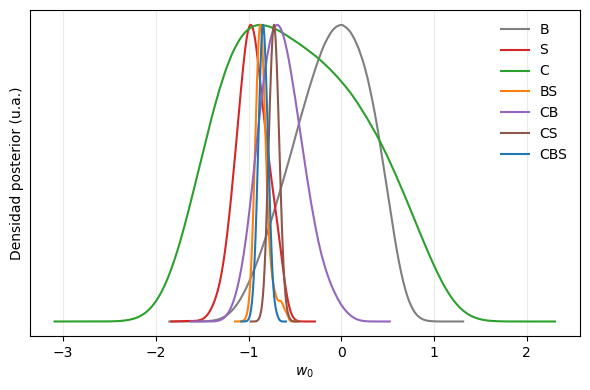

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


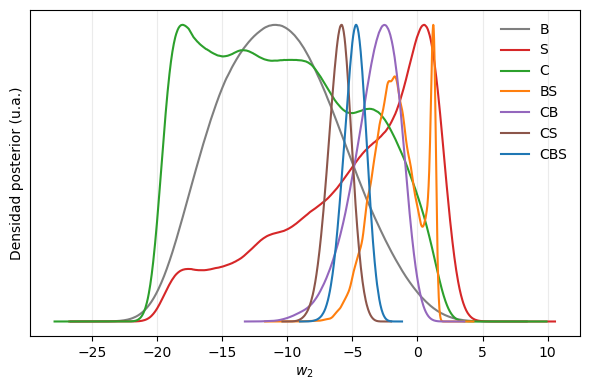

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


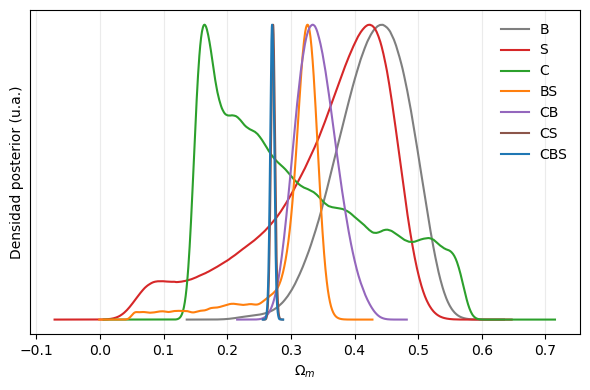

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


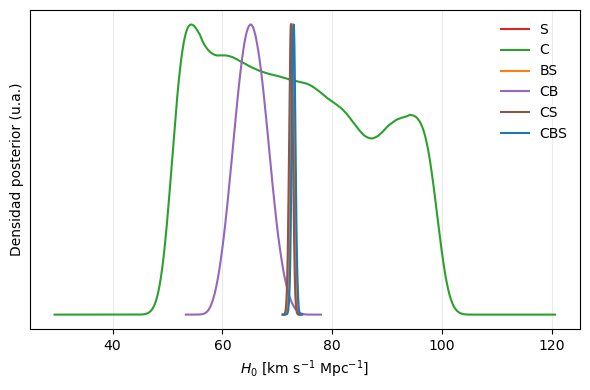

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


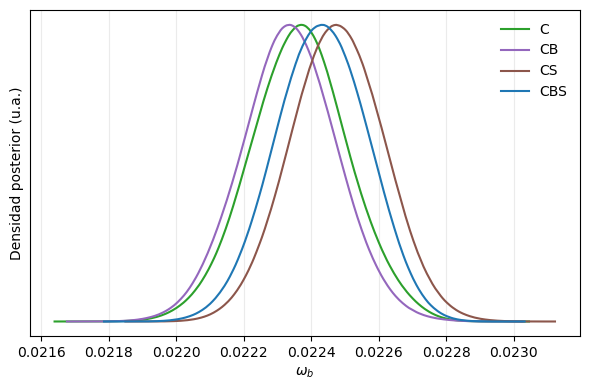

In [70]:
cpl2_1d_specs = [
    {
        "parameter": "w0",
        "combination_ids": COMBINATION_ORDER,
    },
    {
        "parameter": "w2",
        "combination_ids": COMBINATION_ORDER,
    },
    {
        "parameter": "Omega_m",
        "combination_ids": COMBINATION_ORDER,
    },
    {
        "parameter": "H0",
        "combination_ids": [
            "S",
            "C",
            "BS",
            "CB",
            "CS",
            "CBS",
        ],
    },
    {
        "parameter": "omega_b",
        "combination_ids": [
            "C",
            "CB",
            "CS",
            "CBS",
        ],
    },
]

for spec in cpl2_1d_specs:
    required_combinations = spec["combination_ids"]

    if not chains_available_for(
        "CPL2",
        required_combinations,
    ):
        print(
            "Figura no regenerada para "
            f"{spec['parameter']}: faltan cadenas."
        )
        continue

    samples_dict = {
        combination_id: load_getdist_samples(
            "CPL2",
            combination_id,
        )
        for combination_id in required_combinations
    }

    fig, ax = plot_1d_posteriors(
        samples_dict=samples_dict,
        parameter=spec["parameter"],
        combination_ids=required_combinations,
        figsize=(6.0, 4.0),
    )

    save_matplotlib_figure(
        fig,
        FIGURES_DIR / "cpl2",
        f"cpl2_1d_{spec['parameter']}",
    )

    plt.show()

##### Restricción efectiva sobre $H_0r_d$

En las combinaciones B y BS, BAO se implementa mediante la parametrización efectiva $H_0r_d$, de modo que estas cadenas no separan individualmente $H_0$ y $r_d$.

La comparación entre B y BS permite examinar cómo cambia esta combinación efectiva al incorporar la información de SNIa dentro de la misma rama de la likelihood BAO. A diferencia de CPL, la validación de CPL$_2$ no identificó una advertencia específica de sensibilidad al prior para $H_0r_d$, aunque la posterior B continúa siendo relativamente amplia.

Estas restricciones se mantienen separadas de CB y CBS, donde BAO utiliza la rama física y $r_d$ se calcula a partir de los parámetros cosmológicos.

Removed no burn in
Removed no burn in


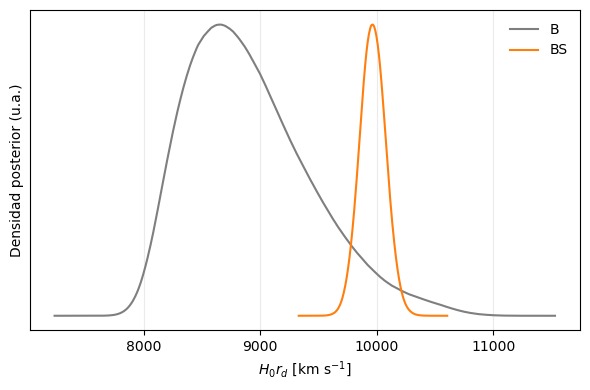

In [71]:
cpl2_h0rd_order = [
    "B",
    "BS",
]

if chains_available_for(
    "CPL2",
    cpl2_h0rd_order,
):
    cpl2_h0rd_samples = {
        combination_id: load_getdist_samples(
            "CPL2",
            combination_id,
        )
        for combination_id in cpl2_h0rd_order
    }

    fig, ax = plot_1d_posteriors(
        samples_dict=cpl2_h0rd_samples,
        parameter="H0rd",
        combination_ids=cpl2_h0rd_order,
        figsize=(6.0, 4.0),
    )

    save_matplotlib_figure(
        fig,
        FIGURES_DIR / "cpl2",
        "cpl2_1d_H0rd",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan las cadenas "
        "CPL2 de B y/o BS."
    )

### Modelo exponencial

El modelo exponencial utiliza la parametrización

$$
w(a)=w_0\exp\left[w_e(1-a)\right],
$$

con límite de constante cosmológica en

$$
(w_0,w_e)=(-1,0).
$$

Se analizan las siete combinaciones B, S, C, BS, CB, CS y CBS. Las combinaciones que contienen S mantienen la cautela metodológica asociada a la implementación de Pantheon+SH0ES descrita anteriormente.

En las combinaciones que incluyen CMB se impone además la condición

$$
\Omega_{\rm DE}(z_*)\leq10^{-2},
\qquad z_*=1090.
$$

Esta condición constituye una restricción metodológica adicional destinada a excluir regiones con una contribución excesiva de energía oscura en recombinación al utilizar los distance priors. No se trata de una restricción inferida estadísticamente por los datos y su proximidad a la posterior se examinará posteriormente como diagnóstico específico del modelo exponencial.

#### Comprobaciones de validación

In [72]:
exp_warnings = pd.concat(
    [
        get_validation_warnings("EXP", combination_id)
        for combination_id in COMBINATION_ORDER
    ],
    ignore_index=True,
)

exp_warnings

,model_id,model,combination_id,combination,disk_prefix,warning_type,warning_code,parameter,warning,evidence,warning_provenance
0,EXP,Exponential,C,CMB,c_exp,sampling,VERY_LOW_SAMPLING_EFFICIENCY,NaN,La ejecución es extremadamente larga y present...,acceptance_rate=0.025855; max_correlation_leng...,INFERIDA
1,EXP,Exponential,C,CMB,c_exp,interpretability,BROAD_CMB_ONLY_POSTERIOR,"H0,w0,we",La combinación CMB-only presenta posteriores m...,H0_span=0.999999; w0_span=0.855503; we_span=0....,INFERIDA


La validación identifica en CMB-only una eficiencia de muestreo muy baja y posteriores extremadamente amplias en $H_0$, $w_0$ y $w_e$. La cadena se considera técnicamente utilizable, por lo que estas características no se interpretan como un fallo del muestreo, sino principalmente como consecuencia de las fuertes degeneraciones geométricas que permanecen al utilizar los distance priors en un modelo dinámico flexible.

La interpretación de C requiere además una cautela específica por la condición

$$
\Omega_{\rm DE}(z_*)\leq10^{-2}.
$$

El efecto real de esta frontera sobre las muestras se examina más adelante mediante un diagnóstico explícito de $\Omega_{\rm DE}(z_*)$. Por tanto, en este punto no se asume ni que el corte sea irrelevante ni que determine por sí solo la posterior CMB-only.

Como en CPL$_2$, los distance priors se utilizan para el modelo exponencial como una aproximación geométrica sin una validación independiente frente a una likelihood CMB completa para esta parametrización. Las restricciones CMB-only se mantienen en el análisis, pero no se interpretan como determinaciones robustas de la dinámica de la energía oscura.

#### Parámetros de energía oscura

In [73]:
exp_de_table = build_constraint_table(
    model_id="EXP",
    parameters=["w0", "we"],
    level=68,
)

exp_de_table

,$w_0$,$w_e$
Combinación,,
B,$-0.427^{+0.247}_{-0.538}$,$3.022^{+2.679}_{-3.001}$
S,$-0.870^{+0.127}_{-0.154}$,$0.479^{+2.131}_{-1.410}$
C,$-0.764^{+0.542}_{-1.053}$,$1.676^{+5.218}_{-3.168}$
BS,$-0.841^{+0.072}_{-0.071}$,$0.579^{+0.655}_{-0.752}$
CB,$-0.616^{+0.199}_{-0.242}$,$1.522^{+1.032}_{-0.847}$
CS,$-0.613^{+0.057}_{-0.058}$,$2.460^{+0.378}_{-0.342}$
CBS,$-0.736^{+0.055}_{-0.057}$,$1.899^{+0.312}_{-0.303}$


Las restricciones sobre $(w_0,w_e)$ presentan una fuerte dependencia de la combinación de datos. Las sondas individuales B y C dejan regiones amplias y fuertemente degeneradas, por lo que sus medianas marginales no deben interpretarse como determinaciones robustas de la evolución de la energía oscura.

Las combinaciones de sondas reducen notablemente esta libertad. BS, CS y CBS seleccionan regiones mucho más acotadas, mientras que CB conserva una degeneración apreciable.

En CBS se obtiene una región caracterizada por $w_0>-1$ y $w_e>0$. Sin embargo, el valor numérico de $w_e$ no puede compararse directamente con $w_a$ o $w_2$, ya que cada uno controla una dependencia funcional distinta de $w(z)$. La comparación física entre parametrizaciones se realizará posteriormente mediante la reconstrucción de la ecuación de estado.

La compatibilidad con $\Lambda$CDM tampoco se determina a partir de las marginales individuales de $w_0$ y $w_e$, sino mediante su distribución conjunta en el plano $(w_0,w_e)$.

#### Sondas individuales y combinación global en el plano $(w_0,w_e)$

Las regiones conjuntas en el plano $(w_0,w_e)$ permiten comparar las degeneraciones de las sondas individuales con la región seleccionada al combinar simultáneamente B, S y C.

El punto $(-1,0)$ representa el límite exacto de $\Lambda$CDM y se utiliza únicamente como referencia geométrica. La curvatura de varias de las posteriores muestra además por qué las marginales unidimensionales resultan insuficientes para describir por completo las restricciones del sector de energía oscura.

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


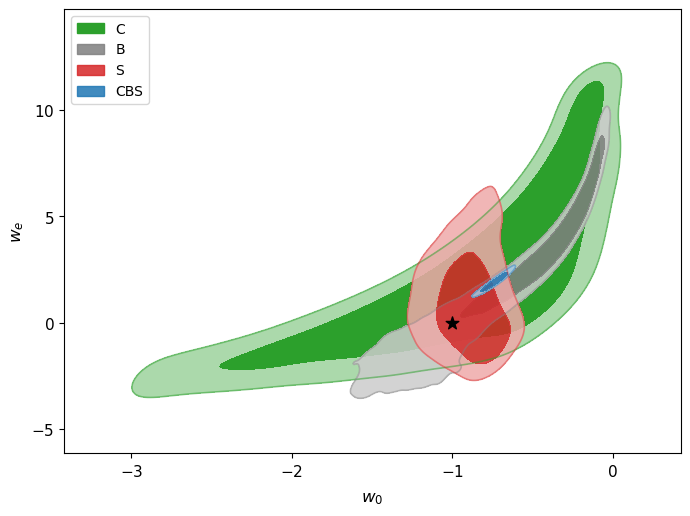

In [74]:
exp_individual_global_order = [
    "C",
    "B",
    "S",
    "CBS",
]

if chains_available_for(
    "EXP",
    exp_individual_global_order,
):
    exp_individual_global_samples = [
        load_getdist_samples(
            "EXP",
            combination_id,
        )
        for combination_id in exp_individual_global_order
    ]

    colors = [
        COMBINATION_COLORS[combination_id]
        for combination_id in exp_individual_global_order
    ]

    g = plots.get_single_plotter(width_inch=7)

    g.settings.num_plot_contours = 2
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize = 11
    g.settings.lab_fontsize = 12
    g.settings.legend_fontsize = 10

    g.plot_2d(
        exp_individual_global_samples,
        "w0",
        "we",
        filled=True,
        colors=colors,
    )

    ax = plt.gca()

    ax.scatter(
        -1.0,
        0.0,
        marker="*",
        s=90,
        color=LCDM_REFERENCE_COLOR,
        label=r"$\Lambda$CDM",
        zorder=10,
    )

    ax.set_xlabel(r"$w_0$")
    ax.set_ylabel(r"$w_e$")

    g.add_legend(
        exp_individual_global_order
        + [r"$\Lambda$CDM"],
        legend_loc="upper left",
    )

    export_getdist_plot(
        g,
        FIGURES_DIR / "exp",
        "exp_contours_w0_we_individual_global",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan una o más cadenas EXP "
        "para C, B, S y CBS."
    )

#### Combinaciones de datos en el plano $(w_0,w_e)$

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


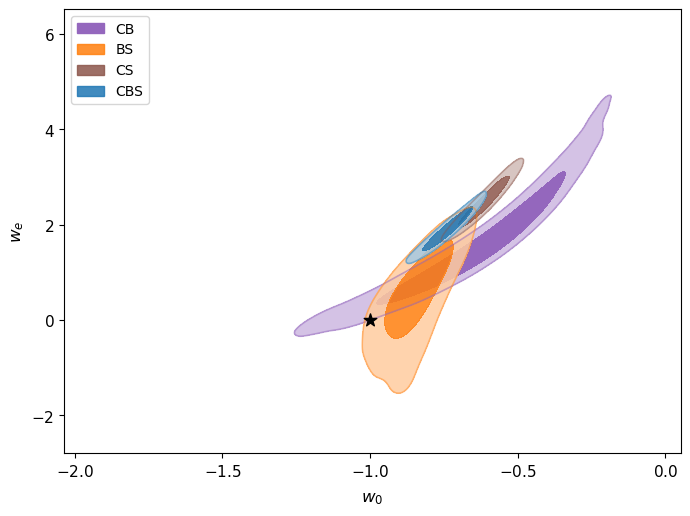

In [75]:
exp_combination_order = [
    "CB",
    "BS",
    "CS",
    "CBS",
]

if chains_available_for(
    "EXP",
    exp_combination_order,
):
    exp_combination_samples = [
        load_getdist_samples(
            "EXP",
            combination_id,
        )
        for combination_id in exp_combination_order
    ]

    colors = [
        COMBINATION_COLORS[combination_id]
        for combination_id in exp_combination_order
    ]

    g = plots.get_single_plotter(width_inch=7)

    g.settings.num_plot_contours = 2
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize = 11
    g.settings.lab_fontsize = 12
    g.settings.legend_fontsize = 10

    g.plot_2d(
        exp_combination_samples,
        "w0",
        "we",
        filled=True,
        colors=colors,
    )

    ax = plt.gca()

    ax.scatter(
        -1.0,
        0.0,
        marker="*",
        s=90,
        color=LCDM_REFERENCE_COLOR,
        label=r"$\Lambda$CDM",
        zorder=10,
    )

    ax.set_xlabel(r"$w_0$")
    ax.set_ylabel(r"$w_e$")

    g.add_legend(
        exp_combination_order
        + [r"$\Lambda$CDM"],
        legend_loc="upper left",
    )

    export_getdist_plot(
        g,
        FIGURES_DIR / "exp",
        "exp_contours_w0_we_combinations",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan una o más cadenas EXP "
        "para CB, BS, CS y CBS."
    )

Las combinaciones de datos seleccionan regiones diferenciadas del plano $(w_0,w_e)$. CB y BS conservan una libertad apreciable, mientras que CS y CBS producen regiones considerablemente más compactas.

CS y CBS ocupan zonas próximas del espacio de parámetros, aunque la incorporación de BAO en CBS desplaza simultáneamente $w_0$ y $w_e$ respecto a CS. El límite de $\Lambda$CDM sirve como referencia para visualizar estos desplazamientos, pero su compatibilidad no debe establecerse mediante una inspección aislada de las marginales.

La geometría de las regiones conjuntas ilustra cómo la combinación de información complementaria entre sondas reduce las degeneraciones presentes en las posteriores individuales. Las combinaciones que contienen S permanecen condicionadas por la implementación de Pantheon+SH0ES utilizada.

#### Parámetros cosmológicos estándar

In [76]:
exp_standard_table = build_constraint_table(
    model_id="EXP",
    parameters=[
        "Omega_m",
        "H0",
        "omega_b",
    ],
    level=68,
)

exp_standard_table

,$\Omega_m$,$H_0$,$\omega_b$
Combinación,,,
B,$0.3749^{+0.0486}_{-0.0833}$,—,—
S,$0.3346^{+0.1154}_{-0.1590}$,$72.70^{+0.42}_{-0.41}$,—
C,$0.2483^{+0.1528}_{-0.0775}$,$76.12^{+15.61}_{-16.23}$,$0.02237^{+0.00014}_{-0.00014}$
BS,$0.3140^{+0.0196}_{-0.0290}$,$72.65^{+0.36}_{-0.35}$,—
CB,$0.3341^{+0.0270}_{-0.0285}$,$65.61^{+2.93}_{-2.43}$,$0.02235^{+0.00014}_{-0.00014}$
CS,$0.2734^{+0.0033}_{-0.0033}$,$72.27^{+0.34}_{-0.33}$,$0.02248^{+0.00015}_{-0.00014}$
CBS,$0.2719^{+0.0031}_{-0.0032}$,$72.76^{+0.33}_{-0.32}$,$0.02245^{+0.00013}_{-0.00014}$


##### Densidad de materia $\Omega_m$

Las restricciones sobre $\Omega_m$ dependen de forma importante de la combinación de datos. Las sondas individuales dejan una libertad apreciable dentro del modelo exponencial, especialmente C, cuya posterior debe interpretarse teniendo en cuenta las fuertes degeneraciones de CMB-only.

Las combinaciones de dos sondas reducen esta libertad de manera diferente. BS selecciona una región próxima a $\Omega_m\simeq0.314$, mientras que CB favorece valores algo mayores, alrededor de $\Omega_m\simeq0.334$.

Por su parte, CS se concentra alrededor de $\Omega_m\simeq0.273$ y la incorporación adicional de BAO apenas modifica esta restricción en CBS, cuya mediana permanece próxima a $\Omega_m\simeq0.272$.

La proximidad entre CS y CBS describe el comportamiento interno del modelo exponencial. La comparación de estos valores con CPL y CPL$_2$ se reservará para el análisis transversal, donde podrá evaluarse de forma homogénea la dependencia de $\Omega_m$ respecto a la parametrización de energía oscura.

##### Constante de Hubble $H_0$

CMB-only deja $H_0$ débilmente determinado en el modelo exponencial, en concordancia con las fuertes degeneraciones geométricas identificadas durante la validación. Por ello, su valor central no debe interpretarse como una determinación robusta de la escala de expansión.

Las combinaciones que contienen S permanecen en la región de $H_0\simeq72$--$73\ {\rm km\,s^{-1}\,Mpc^{-1}}$. Como en los modelos anteriores, esta concentración está condicionada por la elevada precisión de la escala absoluta en la implementación de Pantheon+SH0ES utilizada.

CB selecciona una solución distinta, alrededor de $H_0\simeq65.6\ {\rm km\,s^{-1}\,Mpc^{-1}}$. En ausencia de S, la libertad dinámica del modelo permite por tanto una región de $H_0$ considerablemente inferior a la favorecida por las combinaciones que contienen la calibración de supernovas.

La comparación cuantitativa de CB entre las distintas parametrizaciones dinámicas se realizará posteriormente en el análisis transversal.

##### Densidad física de bariones $\omega_b$

La interpretación de $\omega_b$ debe tener en cuenta que este parámetro constituye directamente una de las tres componentes del vector de distance priors de CMB,

$$
(R,\ell_A,\omega_b).
$$

En consecuencia, la restricción obtenida con C está fuertemente informada de forma directa por la propia likelihood comprimida y no constituye una predicción independiente del modelo exponencial. La implementación empleada compara explícitamente la tercera componente teórica, $\omega_b$, con el valor incluido en el vector observacional de CMB.

Al incorporar otras sondas, CB, CS y CBS permanecen alrededor de $\omega_b\simeq0.0223$--$0.0225$. En particular, las combinaciones CS y CBS pueden acomodarse sin exigir el desplazamiento hacia $\omega_b\simeq0.0236$ que aparece en $\Lambda$CDM.

Por tanto, el resultado relevante no es que EXP determine de forma independiente un valor especialmente estable de $\omega_b$, sino que la libertad adicional del modelo permite alcanzar las soluciones conjuntas manteniendo este parámetro próximo al valor directamente informado por los distance priors.

#### Calidad del ajuste y deterioro al combinar sondas

In [77]:
exp_chi2_contributions = build_chi2_contribution_table(
    model_id="EXP"
)

exp_chi2_contributions.round(2)

,Total,BAO,SN,CMB
Combinación,,,,
B,8.44,8.44,NaN,NaN
S,1134.61,NaN,1134.61,NaN
C,0.00,NaN,NaN,0.00
BS,1146.46,11.66,1134.81,NaN
CB,11.41,11.38,NaN,0.02
CS,1152.44,NaN,1151.46,0.98
CBS,1200.29,40.52,1159.27,0.51


In [78]:
exp_delta_chi2 = build_probe_delta_chi2_table(
    model_id="EXP"
)

exp_delta_chi2.round(2)

,Sonda,Comparación,$\Delta\chi^2$
0,BAO,BS - B,3.21
1,BAO,CBS - CB,29.14
2,SN,BS - S,0.20
3,SN,CS - S,16.85
4,SN,CBS - S,24.66
5,CMB,CB - C,0.02
6,CMB,CS - C,0.98
7,CMB,CBS - C,0.51


Las combinaciones BS y CB pueden acomodarse dentro del modelo exponencial con deterioros relativamente moderados respecto a los ajustes de referencia correspondientes.

La combinación CS exige un compromiso mayor. El deterioro se concentra principalmente en SNIa, mientras que la contribución de CMB permanece pequeña. Este comportamiento debe interpretarse teniendo en cuenta las amplias degeneraciones permitidas por los distance priors dentro del modelo exponencial: una contribución pequeña de CMB al $\chi^2$ no implica por sí sola una fuerte compatibilidad entre las sondas.

En CBS, el coste del ajuste conjunto se distribuye principalmente entre SNIa y BAO, mientras que la contribución de CMB continúa siendo del orden de la unidad. Para BAO, la comparación relevante es CBS frente a CB, ya que ambas combinaciones utilizan la misma rama física de la likelihood. B y BS deben mantenerse separadas porque emplean la parametrización efectiva $H_0r_d$.

La libertad dinámica del modelo permite, por tanto, reproducir los observables comprimidos de CMB sin exigir un deterioro grande de esta componente, mientras que una fracción mayor del compromiso recae sobre las sondas de bajo redshift. Esta observación se refiere exclusivamente a los distance priors utilizados y no puede extrapolarse a una afirmación sobre el comportamiento de una likelihood CMB completa.

Las combinaciones que contienen S permanecen condicionadas por la limitación metodológica de la implementación de Pantheon+SH0ES. Las diferencias de $\chi^2$ mostradas aquí se utilizan únicamente como diagnósticos descriptivos del reparto del coste del ajuste y no como una medida formal de significancia estadística.

#### Síntesis de los resultados del modelo exponencial

El modelo exponencial presenta, como las otras parametrizaciones dinámicas, una fuerte dependencia de las restricciones respecto a la combinación de datos. Las sondas individuales B y C dejan regiones extensas y degeneradas en el plano $(w_0,w_e)$, mientras que la incorporación de información complementaria reduce considerablemente el espacio permitido.

En CBS se obtiene una región posterior compacta caracterizada por $w_0>-1$ y $w_e>0$. El límite de constante cosmológica, $(w_0,w_e)=(-1,0)$, queda alejado de la región posterior principal dentro de la likelihood implementada. La magnitud de $w_e$, sin embargo, no puede compararse directamente con $w_a$ o $w_2$, por lo que la comparación física entre parametrizaciones se realizará posteriormente mediante la reconstrucción de $w(z)$.

Los parámetros cosmológicos estándar muestran igualmente una dependencia clara respecto a las sondas utilizadas. CS y CBS concentran $\Omega_m$ alrededor de $0.27$, mientras que CMB-only deja una libertad considerable en $H_0$. Las combinaciones que contienen S permanecen próximas a $H_0\simeq72$--$73\ {\rm km\,s^{-1}\,Mpc^{-1}}$, condicionadas por la implementación de Pantheon+SH0ES, mientras que CB permite una solución con un valor sensiblemente menor de $H_0$.

En las combinaciones que contienen CMB, $\omega_b$ permanece próximo al valor directamente informado por los distance priors. Este comportamiento no constituye una predicción independiente del modelo exponencial, ya que $\omega_b$ forma parte explícitamente del vector de observables utilizado en la likelihood comprimida.

Las contribuciones al $\chi^2$ muestran que la libertad dinámica permite mantener pequeña la contribución de los distance priors de CMB en CS y CBS, mientras que una parte mayor del coste del ajuste conjunto recae sobre SNIa y BAO. Esta característica describe el comportamiento de la aproximación CMB utilizada y no puede extrapolarse a una likelihood completa del espectro CMB.

Las restricciones CMB-only requieren además una cautela específica debido a la condición impuesta sobre la energía oscura en recombinación,

$$
\Omega_{\rm DE}(z_*)\leq10^{-2}.
$$

El efecto efectivo de esta frontera sobre la posterior se examina de forma explícita en el análisis complementario del modelo.

Finalmente, todas las combinaciones que contienen S están sujetas a la limitación metodológica identificada en la implementación de Pantheon+SH0ES. Los resultados obtenidos son válidos para la likelihood efectivamente utilizada, pero las conclusiones que dependan de su elevada precisión absoluta deben interpretarse con cautela.

En conjunto, el modelo exponencial proporciona una tercera parametrización dinámica que permite explorar un compromiso distinto entre las sondas dentro del marco considerado. La comparación física y estadística con $\Lambda$CDM, CPL y CPL$_2$ se realizará posteriormente utilizando magnitudes comunes y un criterio estadístico homogéneo.

#### Análisis complementario del modelo exponencial

Esta sección reúne diagnósticos adicionales del modelo exponencial que permiten inspeccionar la forma de las distribuciones marginales, la rama efectiva $H_0r_d$ y el efecto de la condición impuesta sobre la fracción de energía oscura en recombinación.

##### Posteriores marginales unidimensionales

Las distribuciones marginales permiten examinar directamente la amplitud, asimetría y posible influencia del volumen de prior que quedan resumidas de forma incompleta mediante medianas e intervalos creíbles.

Este diagnóstico resulta especialmente útil para B y C, cuyas posteriores del sector de energía oscura presentan degeneraciones extensas.

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


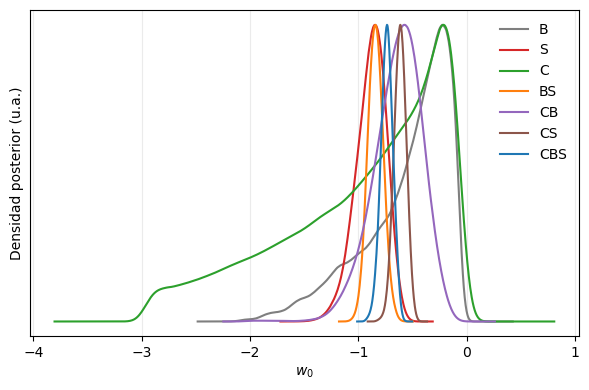

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


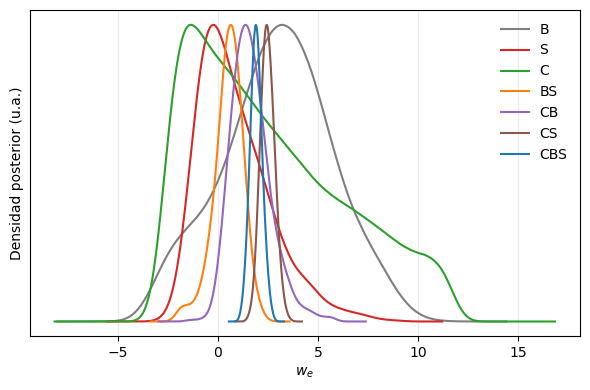

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


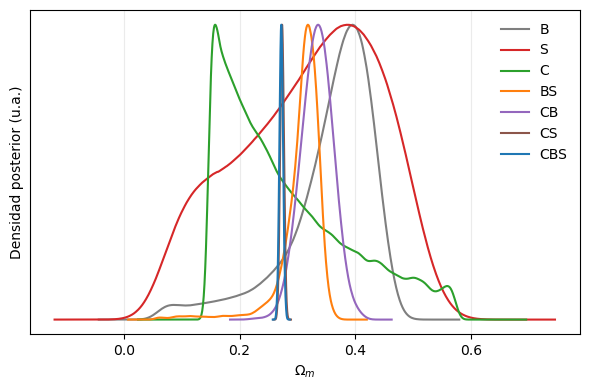

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


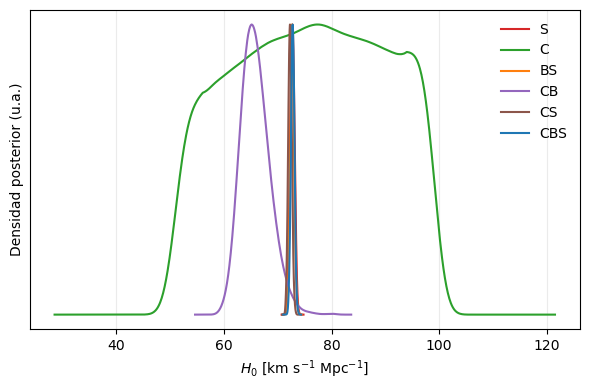

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


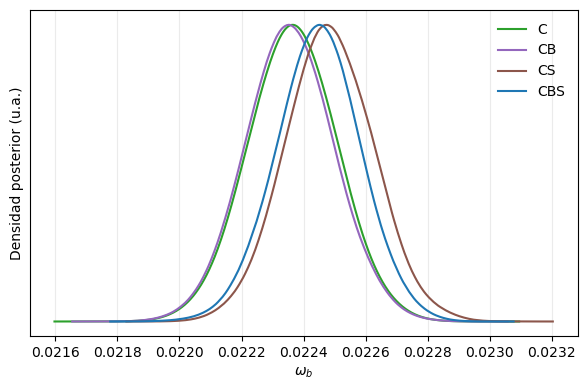

In [79]:
exp_1d_specs = [
    {
        "parameter": "w0",
        "combination_ids": COMBINATION_ORDER,
    },
    {
        "parameter": "we",
        "combination_ids": COMBINATION_ORDER,
    },
    {
        "parameter": "Omega_m",
        "combination_ids": COMBINATION_ORDER,
    },
    {
        "parameter": "H0",
        "combination_ids": [
            "S",
            "C",
            "BS",
            "CB",
            "CS",
            "CBS",
        ],
    },
    {
        "parameter": "omega_b",
        "combination_ids": [
            "C",
            "CB",
            "CS",
            "CBS",
        ],
    },
]

for spec in exp_1d_specs:
    required_combinations = spec["combination_ids"]

    if not chains_available_for(
        "EXP",
        required_combinations,
    ):
        print(
            "Figura no regenerada para "
            f"{spec['parameter']}: faltan cadenas."
        )
        continue

    samples_dict = {
        combination_id: load_getdist_samples(
            "EXP",
            combination_id,
        )
        for combination_id in required_combinations
    }

    fig, ax = plot_1d_posteriors(
        samples_dict=samples_dict,
        parameter=spec["parameter"],
        combination_ids=required_combinations,
        figsize=(6.0, 4.0),
    )

    save_matplotlib_figure(
        fig,
        FIGURES_DIR / "exp",
        f"exp_1d_{spec['parameter']}",
    )

    plt.show()

##### Restricción efectiva sobre $H_0r_d$

En B y BS, BAO se implementa mediante la combinación efectiva $H_0r_d$, sin separar individualmente $H_0$ y $r_d$.

En el modelo exponencial, la posterior B permanece amplia, pero presenta un solapamiento apreciable con la región mucho más estrecha seleccionada por BS. Esta característica se conserva aquí como diagnóstico descriptivo de la rama efectiva de BAO.

La comparación cuantitativa de $H_0r_d$ entre los cuatro modelos se realizará posteriormente en el análisis transversal. Las restricciones B y BS tampoco se comparan directamente con CB o CBS, donde BAO utiliza la rama física y $r_d$ se calcula a partir de los parámetros cosmológicos.

Removed no burn in
Removed no burn in


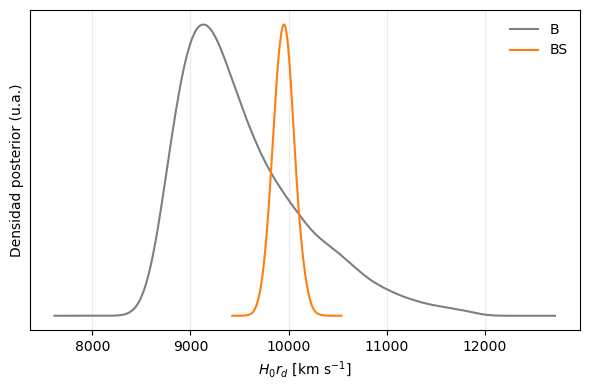

In [80]:
exp_h0rd_order = [
    "B",
    "BS",
]

if chains_available_for(
    "EXP",
    exp_h0rd_order,
):
    exp_h0rd_samples = {
        combination_id: load_getdist_samples(
            "EXP",
            combination_id,
        )
        for combination_id in exp_h0rd_order
    }

    fig, ax = plot_1d_posteriors(
        samples_dict=exp_h0rd_samples,
        parameter="H0rd",
        combination_ids=exp_h0rd_order,
        figsize=(6.0, 4.0),
    )

    save_matplotlib_figure(
        fig,
        FIGURES_DIR / "exp",
        "exp_1d_H0rd",
    )

    plt.show()

else:
    print(
        "Figura no regenerada: faltan las cadenas "
        "EXP de B y/o BS."
    )

##### Efecto de la condición de energía oscura temprana

En las combinaciones que contienen CMB se impone

$$
\Omega_{\rm DE}(z_*)\leq10^{-2},
\qquad z_*=1090.
$$

Para comprobar si esta condición actúa únicamente como frontera de seguridad o si condiciona de forma apreciable las posteriores obtenidas, se reconstruye $\Omega_{\rm DE}(z_*)$ muestra a muestra para C, CB, CS y CBS.

In [81]:
def log_f_de_exp_at_zstar(
    w0,
    we,
    z_star=None,
):
    """
    Evalúa log[f_DE(z)] del modelo exponencial en un redshift dado.

    La expresión reproduce de forma vectorizada la evolución de la
    densidad de energía oscura utilizada en las cadenas finales y
    evita evaluar directamente exponenciales potencialmente extremas.

    Parameters
    ----------
    w0 : array-like
        Valores del parámetro actual de la ecuación de estado.
    we : array-like
        Valores del parámetro evolutivo exponencial.
    z_star : float or None, default=None
        Redshift de evaluación. Si es ``None``, se utiliza el valor
        definido para el corte de energía oscura temprana de EXP.

    Returns
    -------
    numpy.ndarray
        Valores de ``log(f_DE(z_star))`` para cada muestra.
    """
    if z_star is None:
        z_star = EARLY_DE_LIMITS["EXP"]["z_star"]

    w0 = np.asarray(w0, dtype=float)
    we = np.asarray(we, dtype=float)

    log1pz = np.log1p(z_star)
    result = np.empty_like(w0, dtype=float)

    small_we = np.abs(we) < 1.0e-8

    result[small_we] = (
        3.0
        * (1.0 + w0[small_we])
        * log1pz
    )

    regular = ~small_we
    we_reg = we[regular]

    integral = (
        log1pz
        + w0[regular]
        * np.exp(we_reg)
        * (
            expi(-we_reg)
            - expi(
                -we_reg / (1.0 + z_star)
            )
        )
    )

    result[regular] = 3.0 * integral

    return result


def omega_de_star_exp(
    samples,
    z_star=None,
):
    """
    Reconstruye Omega_DE(z_star) para una cadena del modelo EXP.

    Parameters
    ----------
    samples : getdist.MCSamples
        Cadena EXP que contiene ``Omega_m``, ``H0``, ``w0`` y ``we``.
    z_star : float or None, default=None
        Redshift de evaluación. Si es ``None``, se utiliza el redshift
        definido para el corte de energía oscura temprana.

    Returns
    -------
    numpy.ndarray
        Fracción de energía oscura en ``z_star`` para cada muestra.
    """
    if z_star is None:
        z_star = EARLY_DE_LIMITS["EXP"]["z_star"]

    p = samples.getParams()

    Omega_m = np.asarray(
        p.Omega_m,
        dtype=float,
    )
    H0 = np.asarray(
        p.H0,
        dtype=float,
    )
    w0 = np.asarray(
        p.w0,
        dtype=float,
    )
    we = np.asarray(
        p.we,
        dtype=float,
    )

    h = H0 / 100.0
    Omega_r = 4.18e-5 / h**2
    Omega_de = 1.0 - Omega_m - Omega_r

    log1pz = np.log1p(z_star)

    log_radiation = (
        np.log(Omega_r)
        + 4.0 * log1pz
    )
    log_matter = (
        np.log(Omega_m)
        + 3.0 * log1pz
    )
    log_dark_energy = (
        np.log(Omega_de)
        + log_f_de_exp_at_zstar(
            w0,
            we,
            z_star,
        )
    )

    log_total = np.logaddexp(
        np.logaddexp(
            log_radiation,
            log_matter,
        ),
        log_dark_energy,
    )

    return np.exp(
        log_dark_energy - log_total
    )

In [82]:
def expanded_weighted_quantiles(
    values,
    weights,
    quantiles,
):
    """
    Calcula cuantiles lineales para muestras con pesos enteros.

    El resultado es equivalente al que se obtendría expandiendo
    físicamente cada muestra tantas veces como indique su peso y
    aplicando después cuantiles lineales, pero evita construir esa
    muestra expandida en memoria.

    Parameters
    ----------
    values : array-like
        Valores de la variable cuya distribución se resume.
    weights : array-like
        Pesos de las muestras. Se redondean a enteros, de acuerdo con
        la estructura de pesos validada para las cadenas finales.
    quantiles : array-like
        Cuantiles solicitados, expresados entre 0 y 1.

    Returns
    -------
    numpy.ndarray
        Valores correspondientes a los cuantiles solicitados.
    """
    values = np.asarray(values, dtype=float)
    weights = np.rint(
        np.asarray(weights)
    ).astype(np.int64)

    order = np.argsort(values)

    values = values[order]
    weights = weights[order]

    cumulative = np.cumsum(weights)
    n_total = cumulative[-1]

    result = []

    for q in quantiles:
        h = (n_total - 1) * q

        i0 = int(np.floor(h))
        i1 = int(np.ceil(h))
        frac = h - i0

        j0 = np.searchsorted(
            cumulative,
            i0,
            side="right",
        )
        j1 = np.searchsorted(
            cumulative,
            i1,
            side="right",
        )

        value = (
            values[j0]
            + frac * (values[j1] - values[j0])
        )

        result.append(value)

    return np.asarray(result)

In [83]:
exp_early_de_order = [
    combination_id
    for combination_id in COMBINATION_ORDER
    if combination_id
    in EARLY_DE_LIMITS["EXP"]["combinations"]
]

exp_early_de = pd.DataFrame()

if chains_available_for(
    "EXP",
    exp_early_de_order,
):
    early_de_limit = EARLY_DE_LIMITS["EXP"]["Omega_DE_max"]

    exp_early_de_rows = []

    for combination_id in exp_early_de_order:
        samples = load_getdist_samples(
            "EXP",
            combination_id,
        )

        omega_de_star = omega_de_star_exp(samples)
        weights = np.asarray(
            samples.weights,
            dtype=float,
        )

        q50, q95, q99 = expanded_weighted_quantiles(
            omega_de_star,
            weights,
            [0.50, 0.95, 0.99],
        )

        weight_total = weights.sum()

        fraction_above_half_limit = (
            weights[
                omega_de_star > 0.5 * early_de_limit
            ].sum()
            / weight_total
        )

        fraction_above_90pct_limit = (
            weights[
                omega_de_star > 0.9 * early_de_limit
            ].sum()
            / weight_total
        )

        exp_early_de_rows.append(
            {
                "combination_id": combination_id,
                "median": q50,
                "q95": q95,
                "q99": q99,
                "max_sampled": np.max(omega_de_star),
                "fraction_above_half_limit":
                    fraction_above_half_limit,
                "fraction_above_90pct_limit":
                    fraction_above_90pct_limit,
            }
        )

    exp_early_de = pd.DataFrame(
        exp_early_de_rows
    ).set_index("combination_id")

    display(exp_early_de)

else:
    print(
        "Diagnóstico no regenerado: faltan una o más "
        "cadenas EXP para C, CB, CS y CBS."
    )

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


,median,q95,q99,max_sampled,fraction_above_half_limit,fraction_above_90pct_limit
combination_id,,,,,,
C,4.938280e-30,3.529793e-03,8.289118e-03,9.999969e-03,0.034684,0.005651
CB,2.510303e-22,1.830069e-11,4.117559e-09,4.709052e-05,0.000000,0.000000
CS,6.568990e-52,1.847274e-35,1.683246e-30,1.239299e-24,0.000000,0.000000
CBS,4.594789e-37,1.719428e-26,3.256795e-23,9.629305e-20,0.000000,0.000000


La influencia de la condición de energía oscura temprana es muy diferente entre CMB-only y las combinaciones conjuntas.

En C, la mediana de $\Omega_{\rm DE}(z_*)$ es extremadamente pequeña, pero la distribución presenta una cola extensa: el percentil 95 alcanza aproximadamente $3.5\times10^{-3}$ y el percentil 99 llega a $8.3\times10^{-3}$. Además, alrededor del $3.5\,\%$ del peso posterior se encuentra por encima de la mitad del límite impuesto y aproximadamente el $0.6\,\%$ supera el $90\,\%$ de dicho límite. Las muestras más extremas alcanzan prácticamente

$$
\Omega_{\rm DE}(z_*)=10^{-2}.
$$

Por tanto, aunque la mayor parte de la posterior CMB-only corresponde a una contribución despreciable de energía oscura en recombinación, la frontera impuesta sí resulta relevante para una parte de su cola. Esta circunstancia añade una cautela específica a la interpretación de las amplias degeneraciones de C.

El comportamiento cambia al incorporar información de bajo redshift. En CB, el máximo muestreado de $\Omega_{\rm DE}(z_*)$ es del orden de $5\times10^{-5}$, ya muy alejado de la frontera. En CS y CBS los valores son todavía mucho menores, alcanzando máximos del orden de $10^{-24}$ y $10^{-19}$, respectivamente.

En consecuencia, el corte de energía oscura temprana condiciona una parte de la cola posterior de CMB-only, pero no se encuentra próximo a las regiones muestreadas por CB, CS o CBS. Las restricciones obtenidas en estas combinaciones conjuntas no están determinadas directamente por la frontera $\Omega_{\rm DE}(z_*)\leq10^{-2}$.

Este diagnóstico no constituye una validación del uso de los distance priors frente a una likelihood CMB completa. Su función es comprobar el efecto efectivo de la condición adicional incluida en la implementación del modelo exponencial.

## Comparación transversal entre modelos

### Parámetros cosmológicos comunes

La comparación transversal comienza con los parámetros cosmológicos comunes a las cuatro parametrizaciones. La combinación global CBS se utiliza como primera referencia porque contiene simultáneamente las tres sondas y permite examinar cómo cambia la solución conjunta al modificar únicamente el modelo de energía oscura.

Se consideran $\Omega_m$, $H_0$ y $\omega_b$. La comparación de CBS se complementa posteriormente con el comportamiento de BS, CB y CS, ya que algunas dependencias respecto al modelo quedan ocultas si se observa únicamente la combinación global.

Todas las comparaciones que contienen S deben interpretarse teniendo presente la limitación metodológica de la implementación de Pantheon+SH0ES. En particular, la elevada precisión efectiva de la escala absoluta puede modificar no solo la posterior de $H_0$, sino también la localización del compromiso multidimensional con el resto de parámetros.

Además, las combinaciones CS y CBS representan ajustes conjuntos técnicamente bien definidos, pero su construcción no implica que las sondas sean mutuamente compatibles. Cuando los conjuntos de datos favorecen regiones diferentes del espacio de parámetros, la posterior conjunta describe el compromiso que puede alcanzar cada modelo dentro de las likelihoods implementadas.

In [84]:
common_cbs_parameters = [
    "Omega_m",
    "H0",
    "omega_b",
]

cbs_model_comparison = pd.DataFrame(
    {
        PARAMETER_LABELS[parameter]: [
            format_constraint(
                get_posterior_row(
                    model_id,
                    "CBS",
                    parameter,
                ),
                parameter,
                level=68,
            )
            for model_id in MODEL_ORDER
        ]
        for parameter in common_cbs_parameters
    },
    index=[
        MODEL_LABELS[model_id]
        for model_id in MODEL_ORDER
    ],
)

cbs_model_comparison.index.name = "Modelo"

cbs_model_comparison

,$\Omega_m$,$H_0$,$\omega_b$
Modelo,,,
$\Lambda$CDM,$0.2500^{+0.0018}_{-0.0019}$,$73.13^{+0.16}_{-0.15}$,$0.02360^{+0.00011}_{-0.00011}$
CPL,$0.2725^{+0.0033}_{-0.0035}$,$72.62^{+0.37}_{-0.34}$,$0.02247^{+0.00013}_{-0.00013}$
CPL$_2$,$0.2707^{+0.0032}_{-0.0031}$,$72.96^{+0.33}_{-0.34}$,$0.02243^{+0.00014}_{-0.00014}$
Exponencial,$0.2719^{+0.0031}_{-0.0032}$,$72.76^{+0.33}_{-0.32}$,$0.02245^{+0.00013}_{-0.00014}$


#### Densidad de materia $\Omega_m$

La dependencia de $\Omega_m$ respecto a la parametrización cambia según la combinación de sondas. Las restricciones individuales de los modelos dinámicos son generalmente amplias, especialmente en CMB-only, por lo que sus medianas tienen un valor interpretativo limitado.

En BS, las cuatro parametrizaciones seleccionan una región relativamente próxima, con valores alrededor de $\Omega_m\simeq0.31$--$0.32$. En cambio, CB presenta una dependencia apreciable respecto al modelo: las medianas son aproximadamente $0.306$, $0.369$, $0.339$ y $0.334$ para $\Lambda$CDM, CPL, CPL$_2$ y EXP, respectivamente.

El contraste más marcado aparece en CS y CBS. Los tres modelos dinámicos convergen hacia valores próximos a $\Omega_m\simeq0.27$ y la incorporación de BAO de CS a CBS modifica poco esta localización. $\Lambda$CDM selecciona, en cambio, valores próximos a $\Omega_m\simeq0.25$ y simultáneamente presenta un deterioro muy elevado de la componente CMB del ajuste.

Por tanto, CBS muestra una diferencia clara entre $\Lambda$CDM y las tres parametrizaciones dinámicas dentro del análisis realizado, mientras que la dispersión observada en CB ilustra que la inferencia de $\Omega_m$ puede depender de la forma asumida para la energía oscura.

#### Constante de Hubble $H_0$

La comparación transversal de $H_0$ está condicionada por la información disponible en cada combinación. B no separa $H_0$ de $r_d$, mientras que CMB-only deja degeneraciones muy amplias en los modelos dinámicos y no proporciona una determinación robusta de la escala de expansión.

Las combinaciones que contienen S permanecen sistemáticamente en la región de $H_0\simeq72$--$73\ {\rm km\,s^{-1}\,Mpc^{-1}}$. Esta aparente estabilidad frente al modelo no debe interpretarse como una determinación robustamente independiente de la parametrización de energía oscura, ya que la implementación utilizada de Pantheon+SH0ES impone un anclaje de la escala absoluta mucho más preciso que el de la likelihood oficial.

CB resulta más informativa como diagnóstico de dependencia frente al modelo porque no contiene S. En esta combinación se obtienen aproximadamente $H_0\simeq68.2$, $62.5$, $65.2$ y $65.6\ {\rm km\,s^{-1}\,Mpc^{-1}}$ para $\Lambda$CDM, CPL, CPL$_2$ y EXP, respectivamente.

Estas diferencias muestran que, una vez eliminada la fuerte escala absoluta introducida por S, la inferencia de $H_0$ puede depender de forma considerable de la parametrización adoptada para la energía oscura.

#### Densidad física de bariones $\omega_b$

La comparación de $\omega_b$ requiere una cautela distinta de la aplicada a $\Omega_m$ y $H_0$. Este parámetro forma parte directamente del vector de observables utilizado en los distance priors,

$$
(R,\ell_A,\omega_b),
$$

por lo que C contiene una restricción directa sobre $\omega_b$. En consecuencia, el hecho de que los cuatro modelos proporcionen en C valores próximos a $\omega_b\simeq0.02237$ es principalmente una propiedad de la likelihood utilizada y no una evidencia independiente de estabilidad frente al modelo de energía oscura.

La comparación informativa consiste en estudiar cuánto se desplazan las combinaciones conjuntas respecto a esa referencia directamente incorporada por CMB. En CB, los cuatro modelos permanecen próximos a la región favorecida por C. El comportamiento cambia al incorporar S: en $\Lambda$CDM, CS y CBS requieren valores alrededor de $\omega_b\simeq0.0236$, mientras que CPL, CPL$_2$ y EXP permanecen cerca de $\omega_b\simeq0.0224$--$0.0225$.

Este contraste aparece acompañado por una diferencia muy grande en la calidad del ajuste a los distance priors utilizados. En $\Lambda$CDM, CS y CBS presentan contribuciones de CMB al $\chi^2$ superiores a cien, mientras que en los modelos dinámicos dicha contribución permanece del orden de la unidad o inferior. Este comportamiento se refiere exclusivamente a la likelihood CMB comprimida empleada y no puede extrapolarse directamente al ajuste que produciría una likelihood completa de anisotropías del CMB.

Por tanto, el resultado relevante no es que los modelos dinámicos predigan de forma independiente un valor especialmente estable de $\omega_b$, sino que disponen de libertad adicional para alcanzar el compromiso conjunto manteniendo este parámetro cerca del valor directamente informado por los distance priors. La magnitud de esta diferencia continúa condicionada por la implementación de S utilizada.

#### Comparación de $H_0r_d$

In [85]:
h0rd_model_comparison = pd.DataFrame(
    {
        MODEL_LABELS[model_id]: [
            format_constraint(
                get_posterior_row(
                    model_id,
                    combination_id,
                    "H0rd",
                ),
                "H0rd",
                level=68,
            )
            for combination_id in ["B", "BS"]
        ]
        for model_id in MODEL_ORDER
    },
    index=["B", "BS"],
)

h0rd_model_comparison.index.name = "Combinación"

h0rd_model_comparison

,$\Lambda$CDM,CPL,CPL$_2$,Exponencial
Combinación,,,,
B,$10189^{+121}_{-121}$,$8585^{+680}_{-412}$,$8821^{+623}_{-454}$,$9380^{+787}_{-447}$
BS,$10049^{+104}_{-103}$,$9952^{+111}_{-111}$,$9964^{+110}_{-109}$,$9951^{+108}_{-108}$


En BAO-only, la combinación efectiva $H_0r_d$ presenta una dependencia apreciable respecto al modelo. $\Lambda$CDM proporciona una restricción relativamente concentrada alrededor de $1.02\times10^4\ {\rm km\,s^{-1}}$, mientras que las parametrizaciones dinámicas desplazan y amplían la región permitida. En CPL, además, esta posterior presenta la sensibilidad al prior identificada durante la validación.

Al incorporar S, las cuatro posteriores se sitúan en valores próximos a

$$
H_0r_d\simeq10^4\ {\rm km\,s^{-1}},
$$

aunque esta proximidad está condicionada por la elevada precisión con la que S fija la escala absoluta en la implementación utilizada. Entre los modelos dinámicos, EXP presenta el mayor solapamiento entre las posteriores B y BS.

$H_0r_d$ se utiliza aquí como parametrización efectiva de la degeneración BAO en las cadenas B y BS. Por ello, esta comparación tiene un carácter principalmente diagnóstico y debe mantenerse separada de CB y CBS, donde BAO utiliza la rama física y $r_d$ se calcula a partir de los parámetros cosmológicos.

### Dinámica de la energía oscura

Los parámetros que controlan la evolución de la energía oscura no son directamente comparables entre las tres parametrizaciones dinámicas. Aunque $w_a$, $w_2$ y $w_e$ desempeñan un papel evolutivo, multiplican dependencias funcionales diferentes y sus valores numéricos no poseen el mismo significado físico.

El parámetro $w_0$, en cambio, representa en los tres casos el valor actual de la ecuación de estado,

$$
w_0=w(z=0),
$$

por lo que proporciona un primer punto común de comparación. Esta comparación se utiliza únicamente como diagnóstico inicial; la evolución física entre modelos se estudiará posteriormente mediante la reconstrucción directa de $w(z)$.

In [86]:
dynamic_models = [
    "CPL",
    "CPL2",
    "EXP",
]

w0_model_comparison = pd.DataFrame(
    {
        MODEL_LABELS[model_id]: [
            format_constraint(
                get_posterior_row(
                    model_id,
                    combination_id,
                    "w0",
                ),
                "w0",
                level=68,
            )
            for combination_id in COMBINATION_ORDER
        ]
        for model_id in dynamic_models
    },
    index=COMBINATION_ORDER,
)

w0_model_comparison.index.name = "Combinación"

w0_model_comparison

,CPL,CPL$_2$,Exponencial
Combinación,,,
B,$0.549^{+0.513}_{-0.740}$,$-0.076^{+0.405}_{-0.462}$,$-0.427^{+0.247}_{-0.538}$
S,$-0.838^{+0.164}_{-0.168}$,$-0.967^{+0.184}_{-0.169}$,$-0.870^{+0.127}_{-0.154}$
C,$-0.118^{+1.041}_{-0.922}$,$-0.527^{+0.865}_{-0.736}$,$-0.764^{+0.542}_{-1.053}$
BS,$-0.821^{+0.088}_{-0.080}$,$-0.867^{+0.071}_{-0.058}$,$-0.841^{+0.072}_{-0.071}$
CB,$-0.201^{+0.490}_{-0.427}$,$-0.658^{+0.266}_{-0.225}$,$-0.616^{+0.199}_{-0.242}$
CS,$-0.540^{+0.080}_{-0.077}$,$-0.727^{+0.056}_{-0.054}$,$-0.613^{+0.057}_{-0.058}$
CBS,$-0.668^{+0.078}_{-0.076}$,$-0.843^{+0.053}_{-0.051}$,$-0.736^{+0.055}_{-0.057}$


La comparación de $w_0$ muestra una dependencia clara respecto tanto a la combinación de datos como a la parametrización empleada.

Las restricciones individuales B y C son amplias en los modelos dinámicos y sus valores centrales varían considerablemente entre parametrizaciones, por lo que no proporcionan una comparación robusta de la dinámica únicamente a través de $w_0$.

BS constituye un caso diferente: los tres modelos seleccionan valores relativamente próximos,

$$
w_0\simeq-0.82,\,-0.87,\,-0.84
$$

para CPL, CPL$_2$ y EXP, respectivamente.

En CB aparece una dependencia mucho mayor respecto al modelo, con medianas aproximadas

$$
w_0\simeq-0.20,\,-0.66,\,-0.62.
$$

CS y CBS producen restricciones considerablemente más compactas, aunque siguen mostrando diferencias entre parametrizaciones. Para CBS se obtiene aproximadamente

$$
w_0\simeq-0.67,\,-0.84,\,-0.74
$$

para CPL, CPL$_2$ y EXP. Al pasar de CS a CBS, la incorporación de BAO desplaza $w_0$ hacia valores más próximos a $-1$ en las tres parametrizaciones.

Estas diferencias en $w_0$ no implican necesariamente historias de energía oscura igualmente diferentes, ya que cada modelo puede compensarlas mediante su parámetro evolutivo correspondiente. Por ello, la comparación física entre CPL, CPL$_2$ y EXP requiere reconstruir directamente $w(z)$.

#### Reconstrucción de $w(z)$

Los parámetros evolutivos $w_a$, $w_2$ y $w_e$ no son directamente comparables entre modelos. Para realizar una comparación física homogénea se reconstruye, muestra a muestra, la ecuación de estado $w(z)$ correspondiente a cada parametrización.

Para CPL,

$$
w(z)=w_0+w_a\frac{z}{1+z},
$$

para CPL$_2$,

$$
w(z)=w_0+w_2\left(\frac{z}{1+z}\right)^2,
$$

y para el modelo exponencial,

$$
w(z)=w_0\exp\left(w_e\frac{z}{1+z}\right).
$$

La comparación principal se realiza con CBS porque incorpora simultáneamente la información de las tres sondas y proporciona regiones posteriores bien delimitadas en los tres modelos dinámicos. Esta elección no implica que las sondas que forman la combinación sean necesariamente compatibles entre sí: las reconstrucciones deben entenderse como las posteriores conjuntas obtenidas dentro de las likelihoods implementadas.

Para cada redshift se reconstruyen la mediana y los intervalos creíbles centrales del 68 % y 95 % a partir de las muestras posteriores completas.

In [87]:
def reconstruct_wz_bands(
    model_id,
    combination_id,
    z_grid,
):
    """
    Reconstruye bandas posteriores de w(z) muestra a muestra.

    Para cada muestra de la cadena se evalúa la ecuación de estado
    correspondiente al modelo dinámico y, en cada redshift, se calculan
    la mediana y los intervalos creíbles centrales del 68 % y 95 %.

    Parameters
    ----------
    model_id : {"CPL", "CPL2", "EXP"}
        Identificador interno del modelo dinámico.
    combination_id : str
        Identificador de la combinación de datos.
    z_grid : array-like
        Redshifts en los que se reconstruirá la ecuación de estado.

    Returns
    -------
    pandas.DataFrame
        Tabla indexada por redshift con las columnas ``q2_5``, ``q16``,
        ``median``, ``q84`` y ``q97_5``.

    Raises
    ------
    ValueError
        Si se solicita un modelo que no corresponde a una de las tres
        parametrizaciones dinámicas implementadas.
    """
    z_grid = np.asarray(z_grid, dtype=float)

    samples = load_getdist_samples(
        model_id,
        combination_id,
    )

    p = samples.getParams()
    weights = np.asarray(
        samples.weights,
        dtype=float,
    )

    y = z_grid / (1.0 + z_grid)

    if model_id == "CPL":
        w0 = np.asarray(p.w0, dtype=float)
        evolution = np.asarray(p.wa, dtype=float)

        evaluate = lambda index: (
            w0 + evolution * y[index]
        )

    elif model_id == "CPL2":
        w0 = np.asarray(p.w0, dtype=float)
        evolution = np.asarray(p.w2, dtype=float)

        evaluate = lambda index: (
            w0 + evolution * y[index] ** 2
        )

    elif model_id == "EXP":
        w0 = np.asarray(p.w0, dtype=float)
        evolution = np.asarray(p.we, dtype=float)

        evaluate = lambda index: (
            w0 * np.exp(evolution * y[index])
        )

    else:
        raise ValueError(
            "La reconstrucción de w(z) solo está implementada "
            "para CPL, CPL2 y EXP."
        )

    rows = []

    for index, z in enumerate(z_grid):
        values = evaluate(index)

        q2_5, q16, q50, q84, q97_5 = (
            expanded_weighted_quantiles(
                values,
                weights,
                [
                    0.025,
                    0.16,
                    0.50,
                    0.84,
                    0.975,
                ],
            )
        )

        rows.append(
            {
                "z": z,
                "q2_5": q2_5,
                "q16": q16,
                "median": q50,
                "q84": q84,
                "q97_5": q97_5,
            }
        )

    return pd.DataFrame(rows).set_index("z")

In [88]:
def plot_wz_single_model(
    model_id,
    bands,
    figsize=(6.5, 4.5),
):
    """
    Representa la reconstrucción posterior de w(z) de un modelo.

    Se muestran la mediana posterior, las regiones creíbles centrales
    del 68 % y 95 %, y la referencia constante w=-1 correspondiente
    a una constante cosmológica.

    Parameters
    ----------
    model_id : {"CPL", "CPL2", "EXP"}
        Identificador interno del modelo dinámico.
    bands : pandas.DataFrame
        Resultado producido por ``reconstruct_wz_bands``.
    figsize : tuple of float, default=(6.5, 4.5)
        Tamaño de la figura en pulgadas.

    Returns
    -------
    tuple
        Par ``(fig, ax)`` con los objetos de Matplotlib generados.
    """
    z = bands.index.to_numpy(dtype=float)
    color = MODEL_COLORS[model_id]

    fig, ax = plt.subplots(figsize=figsize)

    ax.fill_between(
        z,
        bands["q2_5"],
        bands["q97_5"],
        color=color,
        alpha=0.15,
        label="95 %",
    )

    ax.fill_between(
        z,
        bands["q16"],
        bands["q84"],
        color=color,
        alpha=0.30,
        label="68 %",
    )

    ax.plot(
        z,
        bands["median"],
        color=color,
        linewidth=2,
        label="Mediana",
    )

    ax.axhline(
        -1.0,
        color=LCDM_REFERENCE_COLOR,
        linestyle="--",
        linewidth=1.2,
        label=r"$\Lambda$CDM",
    )

    ax.set_xlabel(r"$z$")
    ax.set_ylabel(r"$w(z)$")
    ax.set_xlim(z.min(), z.max())
    ax.grid(alpha=0.20)
    ax.legend(frameon=False)

    fig.tight_layout()

    return fig, ax

In [89]:
z_w = np.linspace(
    0.0,
    2.5,
    251,
)

wz_cbs = {}

for model_id in dynamic_models:
    if chains_available_for(
        model_id,
        ["CBS"],
    ):
        wz_cbs[model_id] = reconstruct_wz_bands(
            model_id=model_id,
            combination_id="CBS",
            z_grid=z_w,
        )
    else:
        print(
            f"Reconstrucción no regenerada para {model_id}-CBS: "
            "falta la cadena correspondiente."
        )

Removed no burn in
Removed no burn in
Removed no burn in


##### Reconstrucciones individuales para CBS

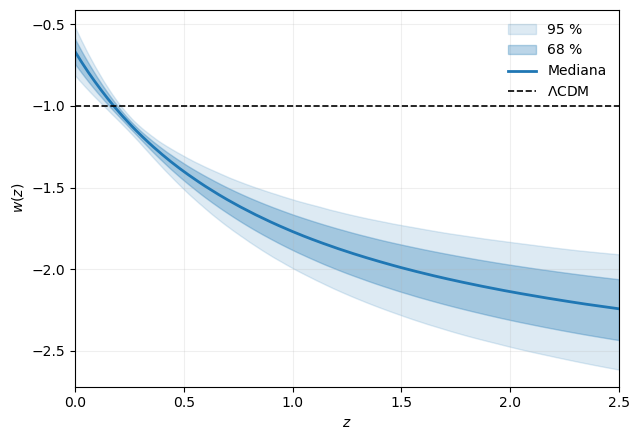

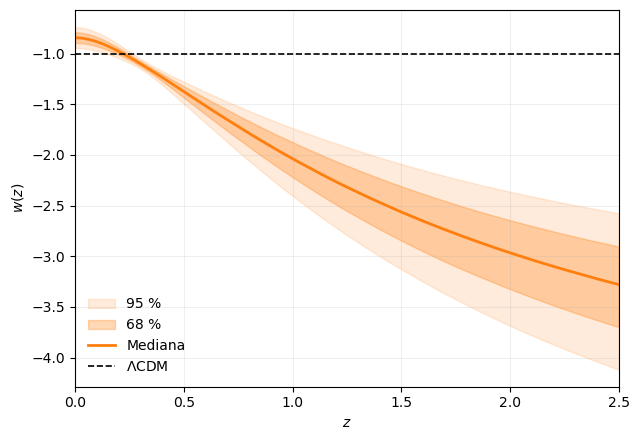

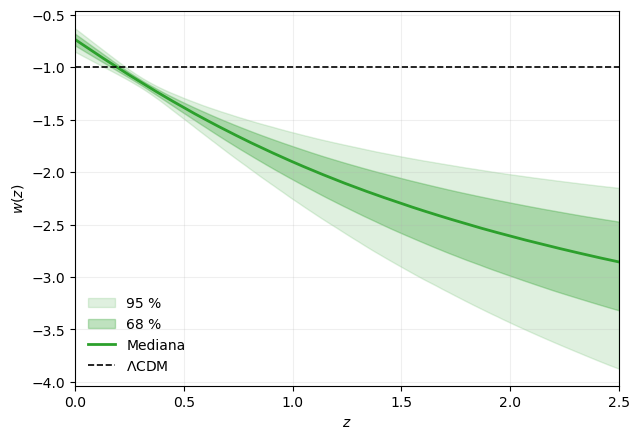

In [90]:
for model_id in dynamic_models:
    if model_id not in wz_cbs:
        continue

    fig, ax = plot_wz_single_model(
        model_id=model_id,
        bands=wz_cbs[model_id],
    )

    save_matplotlib_figure(
        fig,
        ANALYSIS_FIGURES_DIR,
        f"cbs_wz_{model_id}",
    )

    plt.show()

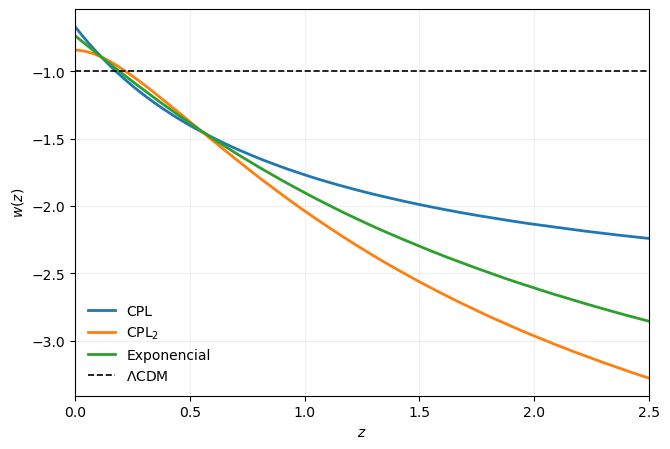

In [91]:
if all(
    model_id in wz_cbs
    for model_id in dynamic_models
):
    fig, ax = plt.subplots(
        figsize=(6.8, 4.6)
    )

    for model_id in dynamic_models:
        bands = wz_cbs[model_id]

        ax.plot(
            bands.index,
            bands["median"],
            color=MODEL_COLORS[model_id],
            linewidth=2,
            label=MODEL_LABELS[model_id],
        )

    ax.axhline(
        -1.0,
        color=LCDM_REFERENCE_COLOR,
        linestyle="--",
        linewidth=1.2,
        label=r"$\Lambda$CDM",
    )

    ax.set_xlabel(r"$z$")
    ax.set_ylabel(r"$w(z)$")
    ax.set_xlim(0.0, 2.5)
    ax.grid(alpha=0.20)
    ax.legend(frameon=False)

    fig.tight_layout()

    save_matplotlib_figure(
        fig,
        ANALYSIS_FIGURES_DIR,
        "cbs_wz_model_comparison",
    )

    plt.show()

else:
    print(
        "Comparación conjunta de w(z) no regenerada: "
        "faltan una o más cadenas CBS."
    )

#### Evolución relativa de la densidad de energía oscura

La reconstrucción de $w(z)$ describe la evolución instantánea de la ecuación de estado, pero los observables cosmológicos dependen de su efecto acumulado sobre la densidad de energía oscura. Por ello se estudia también

$$
f_{\rm DE}(z)
=
\frac{\rho_{\rm DE}(z)}
{\rho_{\rm DE,0}}.
$$

Esta cantidad incorpora de forma integrada la historia de $w(z)$ y permite comparar de manera más directa el efecto cosmológico de las tres parametrizaciones. En $\Lambda$CDM se cumple

$$
f_{\rm DE}(z)=1
$$

para todo redshift.

Como en la reconstrucción de $w(z)$, el cálculo se realiza muestra a muestra para conservar las correlaciones posteriores entre los parámetros.

In [92]:
def reconstruct_fde_bands(
    model_id,
    combination_id,
    z_grid,
):
    """
    Reconstruye bandas posteriores de f_DE(z) muestra a muestra.

    Para cada muestra posterior se calcula la evolución relativa de la
    densidad de energía oscura,

        f_DE(z) = rho_DE(z) / rho_DE,0,

    utilizando la expresión correspondiente a cada parametrización.
    En cada redshift se obtienen la mediana y los intervalos creíbles
    centrales del 68 % y 95 %.

    Parameters
    ----------
    model_id : {"CPL", "CPL2", "EXP"}
        Identificador interno del modelo dinámico.
    combination_id : str
        Identificador de la combinación de datos.
    z_grid : array-like
        Redshifts en los que se reconstruirá f_DE(z).

    Returns
    -------
    pandas.DataFrame
        Tabla con las columnas ``z``, ``q2_5``, ``q16``, ``median``,
        ``q84`` y ``q97_5``.

    Raises
    ------
    ValueError
        Si se solicita un modelo no compatible con la reconstrucción.
    """
    samples = load_getdist_samples(
        model_id,
        combination_id,
    )

    p = samples.getParams()
    weights = np.asarray(
        samples.weights,
        dtype=float,
    )

    w0 = np.asarray(
        p.w0,
        dtype=float,
    )

    if model_id == "CPL":
        evolution = np.asarray(
            p.wa,
            dtype=float,
        )

    elif model_id == "CPL2":
        evolution = np.asarray(
            p.w2,
            dtype=float,
        )

    elif model_id == "EXP":
        evolution = np.asarray(
            p.we,
            dtype=float,
        )

    else:
        raise ValueError(
            "La reconstrucción de f_DE(z) solo está implementada "
            "para CPL, CPL2 y EXP."
        )

    rows = []

    for z in np.asarray(z_grid, dtype=float):
        y = z / (1.0 + z)
        log1pz = np.log1p(z)

        if model_id == "CPL":
            log_fde = (
                3.0
                * (1.0 + w0 + evolution)
                * log1pz
                - 3.0 * evolution * y
            )

        elif model_id == "CPL2":
            log_fde = (
                3.0
                * (1.0 + w0)
                * log1pz
                + 3.0
                * evolution
                * (
                    log1pz
                    - y
                    - 0.5 * y**2
                )
            )

        elif model_id == "EXP":
            log_fde = np.empty_like(
                w0,
                dtype=float,
            )

            small_we = (
                np.abs(evolution)
                < 1.0e-8
            )

            log_fde[small_we] = (
                3.0
                * (1.0 + w0[small_we])
                * log1pz
            )

            regular = ~small_we
            we_reg = evolution[regular]

            integral = (
                log1pz
                + w0[regular]
                * np.exp(we_reg)
                * (
                    expi(-we_reg)
                    - expi(
                        -we_reg
                        / (1.0 + z)
                    )
                )
            )

            log_fde[regular] = (
                3.0 * integral
            )

        fde = np.exp(log_fde)

        q2_5, q16, median, q84, q97_5 = (
            expanded_weighted_quantiles(
                fde,
                weights,
                [
                    0.025,
                    0.16,
                    0.50,
                    0.84,
                    0.975,
                ],
            )
        )

        rows.append(
            {
                "z": z,
                "q2_5": q2_5,
                "q16": q16,
                "median": median,
                "q84": q84,
                "q97_5": q97_5,
            }
        )

    return pd.DataFrame(rows)

In [93]:
fde_cbs = {}

for model_id in dynamic_models:
    if chains_available_for(
        model_id,
        ["CBS"],
    ):
        fde_cbs[model_id] = reconstruct_fde_bands(
            model_id=model_id,
            combination_id="CBS",
            z_grid=z_w,
        )
    else:
        print(
            f"Reconstrucción de f_DE(z) no regenerada "
            f"para {model_id}-CBS: falta la cadena."
        )

Removed no burn in
Removed no burn in
Removed no burn in


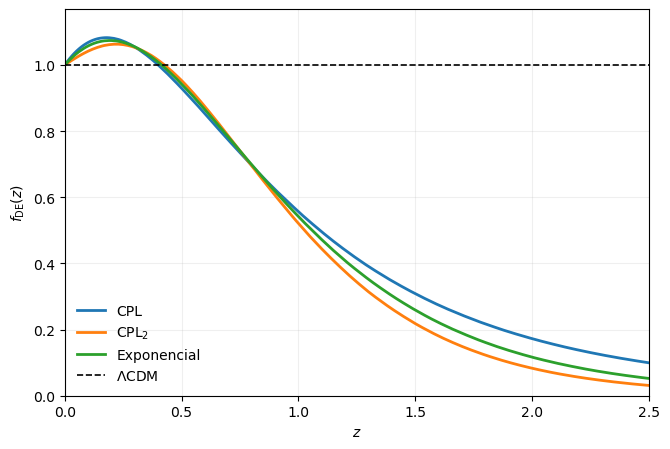

In [94]:
if all(
    model_id in fde_cbs
    for model_id in dynamic_models
):
    fig, ax = plt.subplots(
        figsize=(6.8, 4.6)
    )

    for model_id in dynamic_models:
        bands = fde_cbs[model_id]

        ax.plot(
            bands["z"],
            bands["median"],
            color=MODEL_COLORS[model_id],
            linewidth=2.0,
            label=MODEL_LABELS[model_id],
        )

    ax.axhline(
        1.0,
        color=LCDM_REFERENCE_COLOR,
        linestyle="--",
        linewidth=1.2,
        label=r"$\Lambda$CDM",
    )

    ax.set_xlim(0.0, 2.5)
    ymax_fde = max(
        1.0,
        max(
            fde_cbs[model_id]["median"].max()
            for model_id in dynamic_models
        ),
    )

    ax.set_ylim(
        0.0,
        1.08 * ymax_fde,
    )

    ax.set_xlabel(r"$z$")
    ax.set_ylabel(r"$f_{\rm DE}(z)$")

    ax.grid(alpha=0.20)
    ax.legend(frameon=False)

    fig.tight_layout()

    save_matplotlib_figure(
        fig,
        ANALYSIS_FIGURES_DIR,
        "cbs_fde_model_comparison",
    )

    plt.show()

else:
    print(
        "Comparación de f_DE(z) no regenerada: "
        "faltan una o más cadenas CBS."
    )

In [95]:
fde_reference_redshifts = [
    0.5,
    1.0,
    2.0,
]

fde_cbs_reference = []

for model_id in dynamic_models:
    if model_id not in fde_cbs:
        continue

    bands = fde_cbs[model_id]

    for z_ref in fde_reference_redshifts:
        row = bands.loc[
            np.isclose(
                bands["z"],
                z_ref,
            )
        ].iloc[0]

        fde_cbs_reference.append(
            {
                "model_id": model_id,
                "z": z_ref,
                "median": row["median"],
                "q16": row["q16"],
                "q84": row["q84"],
                "q2_5": row["q2_5"],
                "q97_5": row["q97_5"],
            }
        )

fde_cbs_reference = pd.DataFrame(
    fde_cbs_reference
)

fde_cbs_reference

,model_id,z,median,q16,q84,q2_5,q97_5
0,CPL,0.5,0.929505,0.900583,0.958557,0.872072,0.987431
1,CPL,1.0,0.556417,0.514604,0.598249,0.476761,0.636871
2,CPL,2.0,0.172509,0.134672,0.216104,0.105249,0.264908
3,CPL2,0.5,0.952906,0.921845,0.985322,0.892098,1.018484
4,CPL2,1.0,0.520912,0.470923,0.570033,0.423574,0.614973
5,CPL2,2.0,0.083069,0.054428,0.121078,0.035212,0.166450
6,EXP,0.5,0.942148,0.911991,0.972590,0.882488,1.004225
7,EXP,1.0,0.541718,0.494187,0.587875,0.448108,0.632112
8,EXP,2.0,0.116600,0.077226,0.166257,0.048641,0.226611


Las diferencias entre parametrizaciones son considerablemente menores en $f_{\rm DE}(z)$ que en la evolución instantánea de $w(z)$. En torno a $z=0.5$, las tres medianas se mantienen muy próximas, con $f_{\rm DE}\simeq0.93$--$0.95$, y continúan mostrando una evolución integrada similar hasta redshifts intermedios.

Las diferencias aumentan hacia redshift más alto. En $z=2$, CPL mantiene la mayor densidad relativa de energía oscura, CPL$_2$ la menor y EXP ocupa nuevamente una posición intermedia. No obstante, incluso esta separación resulta mucho menos extrema que la observada directamente en $w(z)$.

Esto muestra que diferencias importantes en la ecuación de estado instantánea pueden traducirse en historias integradas de la densidad de energía oscura considerablemente más próximas.

##### Bandas individuales de $f_{\rm DE}(z)$ para CBS

In [96]:
if all(
    model_id in fde_cbs
    for model_id in dynamic_models
):
    fde_cbs_xlim = (
        0.0,
        2.5,
    )

    fde_cbs_ylim = (
        0.0,
        1.05
        * max(
            fde_cbs[model_id]["q97_5"].max()
            for model_id in dynamic_models
        ),
    )
else:
    fde_cbs_xlim = (0.0, 2.5)
    fde_cbs_ylim = None

In [97]:
def plot_fde_single_model(
    model_id,
    bands,
    xlim=(0.0, 2.5),
    ylim=None,
    figsize=(6.0, 4.5),
):
    """
    Representa la reconstrucción posterior de f_DE(z) de un modelo.

    Se muestran la mediana posterior y las regiones creíbles centrales
    del 68 % y 95 %, junto con la referencia f_DE(z)=1 de LambdaCDM.

    Parameters
    ----------
    model_id : {"CPL", "CPL2", "EXP"}
        Identificador interno del modelo dinámico.
    bands : pandas.DataFrame
        Resultado producido por ``reconstruct_fde_bands``.
    xlim : tuple of float, default=(0.0, 2.5)
        Límites horizontales de la figura.
    ylim : tuple of float or None, default=None
        Límites verticales. Si es ``None``, Matplotlib los determina
        automáticamente.
    figsize : tuple of float, default=(6.0, 4.5)
        Tamaño de la figura en pulgadas.

    Returns
    -------
    tuple
        Par ``(fig, ax)`` con los objetos de Matplotlib generados.
    """
    fig, ax = plt.subplots(
        figsize=figsize
    )

    color = MODEL_COLORS[model_id]

    ax.fill_between(
        bands["z"],
        bands["q2_5"],
        bands["q97_5"],
        color=color,
        alpha=0.15,
        label="95 %",
    )

    ax.fill_between(
        bands["z"],
        bands["q16"],
        bands["q84"],
        color=color,
        alpha=0.30,
        label="68 %",
    )

    ax.plot(
        bands["z"],
        bands["median"],
        color=color,
        linewidth=2.0,
        label="Mediana",
    )

    ax.axhline(
        1.0,
        color=LCDM_REFERENCE_COLOR,
        linestyle="--",
        linewidth=1.2,
        label=r"$\Lambda$CDM",
    )

    ax.set_xlim(*xlim)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel(r"$z$")
    ax.set_ylabel(r"$f_{\rm DE}(z)$")

    ax.set_title(
        MODEL_LABELS[model_id]
    )

    ax.grid(alpha=0.20)
    ax.legend(frameon=False)

    fig.tight_layout()

    return fig, ax

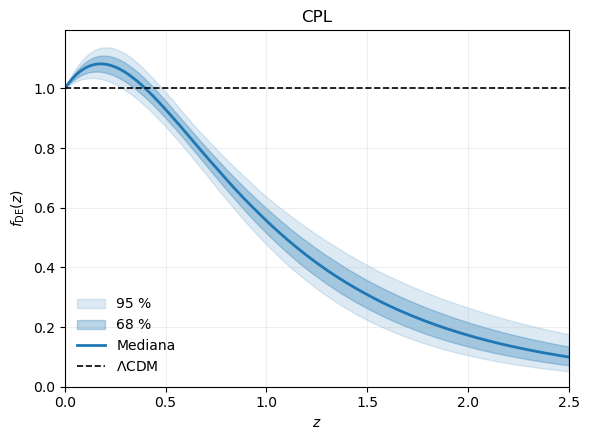

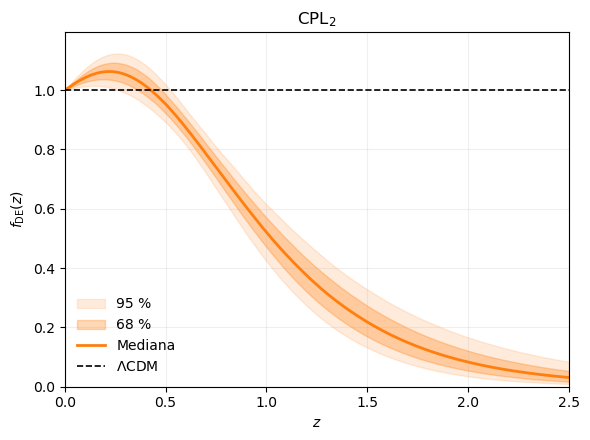

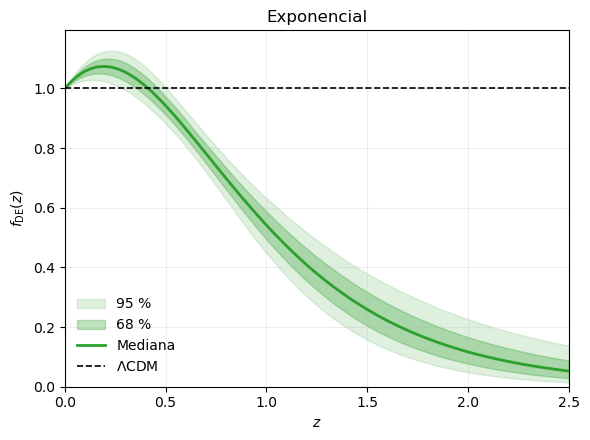

In [98]:
for model_id in dynamic_models:
    if model_id not in fde_cbs:
        continue

    fig, ax = plot_fde_single_model(
        model_id=model_id,
        bands=fde_cbs[model_id],
        xlim=fde_cbs_xlim,
        ylim=fde_cbs_ylim,
    )

    plt.show()

#### Cruce de $w=-1$ en la reconstrucción CBS

Las trayectorias medianas reconstruidas para CBS evolucionan desde valores actuales con $w_0>-1$ hacia un régimen con $w(z)<-1$ al aumentar el redshift. Para comprobar si este comportamiento caracteriza únicamente a las curvas medianas o también a la posterior completa, se calcula muestra a muestra el redshift en el que se satisface

$$
w(z_{\rm cross})=-1.
$$

Se consideran por separado los cruces que ocurren dentro del intervalo analizado,

$$
0<z_{\rm cross}\leq2.5,
$$

los cruces físicos que aparecerían a redshift mayor y las muestras que no presentan ningún cruce positivo y finito.

Los cuantiles de $z_{\rm cross}$ se calculan exclusivamente sobre la fracción posterior que presenta un cruce dentro del intervalo considerado.

In [99]:
def get_w_minus_one_crossing_summary(
    model_id,
    combination_id="CBS",
    z_max=2.5,
):
    """
    Resume el cruce posterior de la línea w(z)=-1.

    El redshift de cruce se calcula analíticamente muestra a muestra
    para CPL, CPL2 y EXP. Se distingue entre cruces dentro del intervalo
    analizado, cruces físicos a redshift mayor y muestras sin un cruce
    positivo y finito.

    Para las muestras sin cruce se inspeccionan además los valores en
    z=0 y en el límite y=z/(1+z)->1. Dado que las tres formas funcionales
    implementadas son monótonas respecto a y para cada muestra, esto
    permite distinguir trayectorias que permanecen completamente por
    encima o por debajo de w=-1.

    Parameters
    ----------
    model_id : {"CPL", "CPL2", "EXP"}
        Identificador interno del modelo dinámico.
    combination_id : str, default="CBS"
        Identificador de la combinación de datos.
    z_max : float, default=2.5
        Redshift máximo considerado para clasificar un cruce como
        perteneciente al intervalo analizado.

    Returns
    -------
    dict
        Resumen con las fracciones posteriores de cada tipo de
        comportamiento y los cuantiles del redshift de cruce para las
        muestras que cruzan dentro de ``0 < z <= z_max``.

    Raises
    ------
    ValueError
        Si se solicita una parametrización no compatible.
    """
    samples = load_getdist_samples(
        model_id,
        combination_id,
    )

    p = samples.getParams()

    weights = np.asarray(
        samples.weights,
        dtype=float,
    )

    w0 = np.asarray(
        p.w0,
        dtype=float,
    )

    y_cross = np.full_like(
        w0,
        np.nan,
        dtype=float,
    )

    if model_id == "CPL":
        evolution = np.asarray(
            p.wa,
            dtype=float,
        )

        valid = (
            np.abs(evolution) > 1.0e-12
        )

        y_cross[valid] = (
            (-1.0 - w0[valid])
            / evolution[valid]
        )

        w_inf = w0 + evolution

    elif model_id == "CPL2":
        evolution = np.asarray(
            p.w2,
            dtype=float,
        )

        valid = (
            np.abs(evolution) > 1.0e-12
        )

        ratio = np.full_like(
            w0,
            np.nan,
            dtype=float,
        )

        ratio[valid] = (
            (-1.0 - w0[valid])
            / evolution[valid]
        )

        real_crossing = (
            valid
            & (ratio >= 0.0)
        )

        y_cross[real_crossing] = np.sqrt(
            ratio[real_crossing]
        )

        w_inf = w0 + evolution

    elif model_id == "EXP":
        evolution = np.asarray(
            p.we,
            dtype=float,
        )

        valid = (
            (w0 < 0.0)
            & (
                np.abs(evolution)
                > 1.0e-12
            )
        )

        y_cross[valid] = (
            np.log(
                -1.0 / w0[valid]
            )
            / evolution[valid]
        )

        w_inf = (
            w0 * np.exp(evolution)
        )

    else:
        raise ValueError(
            "El cruce de w=-1 solo está implementado "
            "para CPL, CPL2 y EXP."
        )

    physical_crossing = (
        np.isfinite(y_cross)
        & (y_cross > 0.0)
        & (y_cross < 1.0)
    )

    z_cross = np.full_like(
        w0,
        np.nan,
        dtype=float,
    )

    z_cross[physical_crossing] = (
        y_cross[physical_crossing]
        / (
            1.0
            - y_cross[physical_crossing]
        )
    )

    crossing_in_range = (
        physical_crossing
        & (z_cross <= z_max)
    )

    crossing_beyond_range = (
        physical_crossing
        & (z_cross > z_max)
    )

    no_finite_positive_crossing = (
        ~physical_crossing
    )

    always_above = (
        no_finite_positive_crossing
        & (w0 > -1.0)
        & (w_inf >= -1.0)
    )

    always_below = (
        no_finite_positive_crossing
        & (w0 < -1.0)
        & (w_inf <= -1.0)
    )

    boundary_cases = (
        no_finite_positive_crossing
        & ~(always_above | always_below)
    )

    total_weight = weights.sum()

    if np.any(crossing_in_range):
        (
            q2_5,
            q16,
            median,
            q84,
            q97_5,
        ) = expanded_weighted_quantiles(
            z_cross[crossing_in_range],
            weights[crossing_in_range],
            [
                0.025,
                0.16,
                0.50,
                0.84,
                0.975,
            ],
        )

    else:
        q2_5 = np.nan
        q16 = np.nan
        median = np.nan
        q84 = np.nan
        q97_5 = np.nan

    return {
        "model_id": model_id,
        "crossing_fraction":
            weights[crossing_in_range].sum()
            / total_weight,
        "crossing_beyond_fraction":
            weights[crossing_beyond_range].sum()
            / total_weight,
        "no_finite_crossing_fraction":
            weights[no_finite_positive_crossing].sum()
            / total_weight,
        "always_above_fraction":
            weights[always_above].sum()
            / total_weight,
        "always_below_fraction":
            weights[always_below].sum()
            / total_weight,
        "boundary_fraction":
            weights[boundary_cases].sum()
            / total_weight,
        "median": median,
        "q16": q16,
        "q84": q84,
        "q2_5": q2_5,
        "q97_5": q97_5,
    }

In [100]:
if all(
    chains_available_for(
        model_id,
        ["CBS"],
    )
    for model_id in dynamic_models
):
    w_crossing_cbs = pd.DataFrame(
        [
            get_w_minus_one_crossing_summary(
                model_id=model_id,
                combination_id="CBS",
                z_max=2.5,
            )
            for model_id in dynamic_models
        ]
    ).set_index("model_id")

    display(w_crossing_cbs)

else:
    w_crossing_cbs = pd.DataFrame()

    print(
        "Diagnóstico de cruces no regenerado: "
        "faltan una o más cadenas CBS."
    )

Removed no burn in
Removed no burn in
Removed no burn in


,crossing_fraction,crossing_beyond_fraction,no_finite_crossing_fraction,always_above_fraction,always_below_fraction,boundary_fraction,median,q16,q84,q2_5,q97_5
model_id,,,,,,,,,,,
CPL,1.000000,0.0,0.000000,0.0,0.000000,0.0,0.177475,0.156136,0.195163,0.131393,0.210014
CPL2,0.999064,0.0,0.000936,0.0,0.000936,0.0,0.220011,0.189995,0.244557,0.143368,0.264073
EXP,1.000000,0.0,0.000000,0.0,0.000000,0.0,0.192719,0.166965,0.214855,0.134425,0.234182


El cruce de $w=-1$ no es una propiedad exclusiva de las curvas medianas. Para CBS, prácticamente toda la masa posterior de las tres parametrizaciones presenta un cruce reciente dentro de $0<z<2.5$.

En CPL y EXP la fracción posterior que cruza en este intervalo es esencialmente del 100 %. En CPL$_2$ alcanza aproximadamente el $99.9\,\%$. La pequeña fracción restante no corresponde a cruces desplazados por encima de $z=2.5$, sino fundamentalmente a muestras que ya se encuentran en el régimen $w<-1$ en el presente y permanecen por debajo de la línea $w=-1$, sin un cruce positivo y finito.

Los redshifts medianos de cruce son aproximadamente

$$
z_{\rm cross}
\simeq
0.177,\;0.220,\;0.193
$$

para CPL, CPL$_2$ y EXP, respectivamente. Los tres modelos sitúan por tanto la transición en una región reciente, alrededor de $z\simeq0.2$, aunque con diferencias cuantitativas entre parametrizaciones.

Este comportamiento caracteriza de forma consistente las posteriores dinámicas obtenidas con CBS dentro del análisis realizado, pero no debe interpretarse por sí solo como una detección física de un cruce de la frontera $w=-1$ ni como evidencia de preferencia frente a $\Lambda$CDM. Su interpretación permanece además condicionada por la implementación de Pantheon+SH0ES utilizada en CBS y, para la componente CMB, por el uso de distance priors.

In [101]:
w_reference_redshifts = [
    0.2,
    0.5,
    1.0,
    2.0,
]

wz_cbs_reference = []

for model_id in dynamic_models:
    if model_id not in wz_cbs:
        continue

    bands = wz_cbs[model_id]

    z_values = bands.index.to_numpy(
        dtype=float
    )

    for z_ref in w_reference_redshifts:
        matching_rows = np.isclose(
            z_values,
            z_ref,
        )

        if not np.any(matching_rows):
            raise ValueError(
                f"No se encuentra z={z_ref} "
                f"en la reconstrucción de {model_id}."
            )

        row = bands.iloc[
            np.flatnonzero(
                matching_rows
            )[0]
        ]

        wz_cbs_reference.append(
            {
                "model_id": model_id,
                "z": z_ref,
                "median": row["median"],
                "q16": row["q16"],
                "q84": row["q84"],
                "q2_5": row["q2_5"],
                "q97_5": row["q97_5"],
            }
        )

wz_cbs_reference = pd.DataFrame(
    wz_cbs_reference
)

In [102]:
wz_cbs_reference_display = (
    wz_cbs_reference
    .pivot(
        index="z",
        columns="model_id",
        values="median",
    )
    .reindex(
        columns=dynamic_models
    )
    .rename(
        columns=MODEL_LABELS
    )
)

wz_cbs_reference_display

model_id,CPL,CPL$_2$,Exponencial
z,,,
0.2,-1.035429,-0.977249,-1.009470
0.5,-1.401954,-1.374451,-1.384873
1.0,-1.769323,-2.037772,-1.902139
2.0,-2.136923,-2.965973,-2.609294


#### Análisis complementario de la reconstrucción de $w(z)$

Los siguientes diagnósticos exploran propiedades adicionales de las reconstrucciones posteriores de $w(z)$. Se estudian la región de máxima precisión y la existencia de redshifts en los que las tres parametrizaciones proporcionan valores especialmente próximos.

Estos resultados se consideran complementarios y exploratorios: permiten caracterizar mejor las posteriores obtenidas, pero no se interpretan como propiedades universales de la energía oscura.

##### Precisión de la reconstrucción de $w(z)$

In [103]:
wz_precision_cbs = []

for model_id in dynamic_models:
    if model_id not in wz_cbs:
        continue

    bands = wz_cbs[model_id].copy()

    bands["width_68"] = (
        bands["q84"] - bands["q16"]
    )

    bands["width_95"] = (
        bands["q97_5"] - bands["q2_5"]
    )

    idx_68 = bands["width_68"].idxmin()
    idx_95 = bands["width_95"].idxmin()

    wz_precision_cbs.append(
        {
            "model_id": model_id,
            "z_min_width_68": float(idx_68),
            "min_width_68":
                bands.loc[idx_68, "width_68"],
            "w_median_at_min_68":
                bands.loc[idx_68, "median"],
            "z_min_width_95": float(idx_95),
            "min_width_95":
                bands.loc[idx_95, "width_95"],
            "w_median_at_min_95":
                bands.loc[idx_95, "median"],
        }
    )

wz_precision_cbs = pd.DataFrame(
    wz_precision_cbs
).set_index("model_id")

display(wz_precision_cbs)

,z_min_width_68,min_width_68,w_median_at_min_68,z_min_width_95,min_width_95,w_median_at_min_95
model_id,,,,,,
CPL,0.25,0.047413,-1.108631,0.26,0.094858,-1.122655
CPL2,0.29,0.050509,-1.086046,0.31,0.097625,-1.112326
EXP,0.31,0.049751,-1.153060,0.31,0.098751,-1.153060


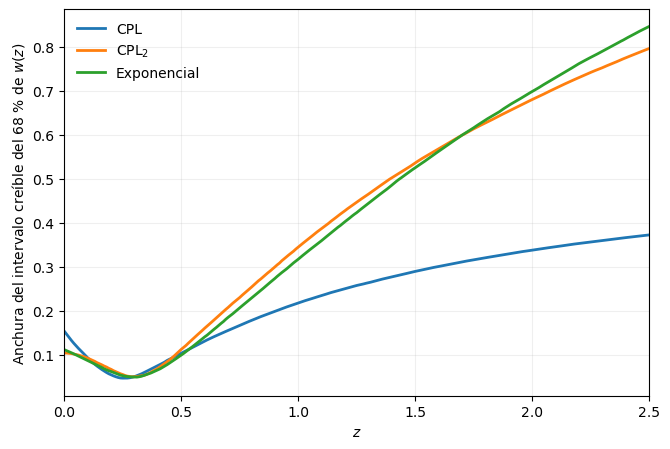

In [104]:
if all(
    model_id in wz_cbs
    for model_id in dynamic_models
):
    fig, ax = plt.subplots(
        figsize=(6.8, 4.6)
    )

    for model_id in dynamic_models:
        bands = wz_cbs[model_id]

        width_68 = (
            bands["q84"] - bands["q16"]
        )

        ax.plot(
            bands.index,
            width_68,
            color=MODEL_COLORS[model_id],
            linewidth=2.0,
            label=MODEL_LABELS[model_id],
        )

    ax.set_xlim(0.0, 2.5)

    ax.set_xlabel(r"$z$")
    ax.set_ylabel(
        r"Anchura del intervalo creíble del 68 % de $w(z)$"
    )

    ax.grid(alpha=0.20)
    ax.legend(frameon=False)

    fig.tight_layout()

    plt.show()

else:
    print(
        "Diagnóstico de precisión no regenerado: "
        "faltan una o más reconstrucciones CBS."
    )

Las tres parametrizaciones presentan una región de máxima precisión a bajo redshift. La anchura mínima del intervalo creíble del 68 % se sitúa aproximadamente en $z\simeq0.25$ para CPL, $z\simeq0.29$ para CPL$_2$ y $z\simeq0.31$ para EXP. El comportamiento del intervalo del 95 % es muy similar.

Estas posiciones no deben interpretarse como redshifts pivot universales. Corresponden únicamente a los puntos en los que, dentro de cada parametrización y para la combinación CBS utilizada, la reconstrucción posterior de $w(z)$ alcanza su menor anchura marginal.

##### Dependencia de $w(z)$ respecto a la parametrización

In [105]:
def get_wz_model_spread(wz_dict):
    """
    Calcula la dispersión entre las medianas de w(z) de los modelos.

    En cada redshift se toma la diferencia entre la mayor y la menor
    mediana posterior entre CPL, CPL2 y EXP.

    Parameters
    ----------
    wz_dict : dict
        Diccionario con las reconstrucciones de ``w(z)`` para los tres
        modelos dinámicos. Cada valor debe ser un DataFrame indexado
        por redshift y contener una columna ``median``.

    Returns
    -------
    pandas.DataFrame
        Tabla con el redshift, las tres medianas y la dispersión
        máxima entre modelos.

    Raises
    ------
    ValueError
        Si falta alguno de los modelos dinámicos o las rejillas de
        redshift no coinciden.
    """
    missing = [
        model_id
        for model_id in dynamic_models
        if model_id not in wz_dict
    ]

    if missing:
        raise ValueError(
            "Faltan reconstrucciones para: "
            + ", ".join(missing)
        )

    reference_z = (
        wz_dict[dynamic_models[0]]
        .index
        .to_numpy(dtype=float)
    )

    data = {"z": reference_z}

    for model_id in dynamic_models:
        z_values = (
            wz_dict[model_id]
            .index
            .to_numpy(dtype=float)
        )

        if not np.allclose(
            z_values,
            reference_z,
        ):
            raise ValueError(
                "Las reconstrucciones no utilizan "
                "la misma rejilla de redshift."
            )

        data[model_id] = (
            wz_dict[model_id]["median"]
            .to_numpy(dtype=float)
        )

    spread_df = pd.DataFrame(data)

    spread_df["spread"] = (
        spread_df[dynamic_models].max(axis=1)
        - spread_df[dynamic_models].min(axis=1)
    )

    return spread_df


def get_local_spread_minima(spread_df):
    """
    Localiza mínimos locales de la dispersión entre modelos.

    Parameters
    ----------
    spread_df : pandas.DataFrame
        Tabla producida por ``get_wz_model_spread``.

    Returns
    -------
    pandas.DataFrame
        Filas correspondientes a mínimos locales de ``spread``,
        ordenadas por redshift.
    """
    spread = spread_df["spread"].to_numpy()

    local_min_mask = (
        (spread[1:-1] < spread[:-2])
        & (spread[1:-1] < spread[2:])
    )

    local_min_indices = (
        np.where(local_min_mask)[0] + 1
    )

    return (
        spread_df.loc[
            local_min_indices,
            [
                "z",
                "CPL",
                "CPL2",
                "EXP",
                "spread",
            ],
        ]
        .sort_values("z")
        .reset_index(drop=True)
    )

In [106]:
wz_model_spread = get_wz_model_spread(
    wz_cbs
)

wz_local_minima = get_local_spread_minima(
    wz_model_spread
)

display(wz_local_minima)

,z,CPL,CPL2,EXP,spread
0,0.11,-0.885911,-0.890465,-0.888230,0.004554
1,0.56,-1.458108,-1.459805,-1.454671,0.005134


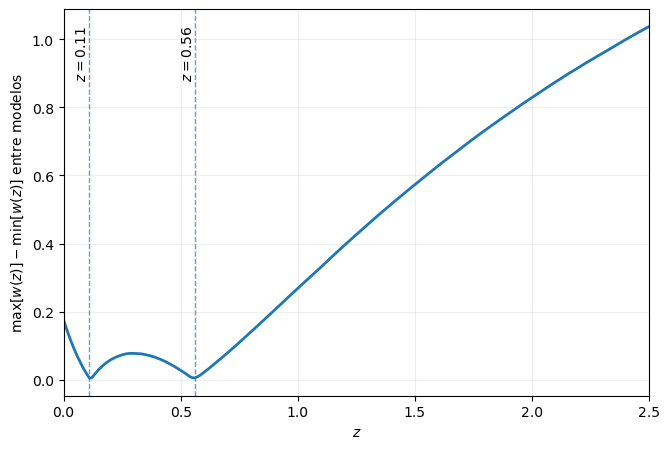

In [107]:
fig, ax = plt.subplots(
    figsize=(6.8, 4.6)
)

ax.plot(
    wz_model_spread["z"],
    wz_model_spread["spread"],
    linewidth=2.0,
)

for _, row in wz_local_minima.iterrows():
    ax.axvline(
        row["z"],
        linestyle="--",
        linewidth=1.0,
        alpha=0.7,
    )

    ax.text(
        row["z"],
        0.96,
        rf"$z={row['z']:.2f}$",
        transform=ax.get_xaxis_transform(),
        rotation=90,
        va="top",
        ha="right",
    )

ax.set_xlim(0.0, 2.5)

ax.set_xlabel(r"$z$")
ax.set_ylabel(
    r"$\max[w(z)]-\min[w(z)]$ entre modelos"
)

ax.grid(alpha=0.20)

fig.tight_layout()

plt.show()

##### Distribuciones de $w(z)$ en los nodos de convergencia

In [108]:
def get_wz_samples(
    model_id,
    combination_id,
    z,
):
    """
    Evalúa w(z) muestra a muestra para una cadena dinámica.

    Parameters
    ----------
    model_id : {"CPL", "CPL2", "EXP"}
        Identificador interno del modelo.
    combination_id : str
        Identificador de la combinación de datos.
    z : float
        Redshift de evaluación.

    Returns
    -------
    tuple of numpy.ndarray
        Valores de ``w(z)`` y pesos posteriores correspondientes.

    Raises
    ------
    ValueError
        Si se solicita una parametrización no implementada.
    """
    samples = load_getdist_samples(
        model_id,
        combination_id,
    )

    p = samples.getParams()

    weights = np.asarray(
        samples.weights,
        dtype=float,
    )

    w0 = np.asarray(
        p.w0,
        dtype=float,
    )

    y = z / (1.0 + z)

    if model_id == "CPL":
        evolution = np.asarray(
            p.wa,
            dtype=float,
        )

        wz = w0 + evolution * y

    elif model_id == "CPL2":
        evolution = np.asarray(
            p.w2,
            dtype=float,
        )

        wz = w0 + evolution * y**2

    elif model_id == "EXP":
        evolution = np.asarray(
            p.we,
            dtype=float,
        )

        wz = (
            w0 * np.exp(evolution * y)
        )

    else:
        raise ValueError(
            "Modelo no compatible con la "
            "evaluación de w(z)."
        )

    return wz, weights

In [109]:
convergence_redshifts = [
    0.11,
    0.56,
]

wz_convergence_summary = []

for z_ref in convergence_redshifts:
    for model_id in dynamic_models:
        wz, weights = get_wz_samples(
            model_id,
            "CBS",
            z_ref,
        )

        (
            q2_5,
            q16,
            median,
            q84,
            q97_5,
        ) = expanded_weighted_quantiles(
            wz,
            weights,
            [
                0.025,
                0.16,
                0.50,
                0.84,
                0.975,
            ],
        )

        wz_convergence_summary.append(
            {
                "z": z_ref,
                "model_id": model_id,
                "median": median,
                "q16": q16,
                "q84": q84,
                "q2_5": q2_5,
                "q97_5": q97_5,
                "width_68": q84 - q16,
            }
        )

wz_convergence_summary = pd.DataFrame(
    wz_convergence_summary
)

display(wz_convergence_summary)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


,z,model_id,median,q16,q84,q2_5,q97_5,width_68
0,0.11,CPL,-0.885911,-0.930560,-0.842087,-0.971196,-0.800590,0.088473
1,0.11,CPL2,-0.890465,-0.935212,-0.844839,-0.979346,-0.800682,0.090373
2,0.11,EXP,-0.888230,-0.930065,-0.845276,-0.973536,-0.805540,0.084789
3,0.56,CPL,-1.458108,-1.521253,-1.400636,-1.583873,-1.348747,0.120617
4,0.56,CPL2,-1.459805,-1.534271,-1.392714,-1.609545,-1.338741,0.141557
5,0.56,EXP,-1.454671,-1.518970,-1.394979,-1.588651,-1.340747,0.123992


In [110]:
def plot_wz_distributions_at_z(z_ref):
    """
    Compara las posteriores derivadas de w(z) entre modelos.

    Parameters
    ----------
    z_ref : float
        Redshift en el que se evalúan las tres posteriores CBS.

    Returns
    -------
    getdist.plots.GetDistPlotter
        Plotter de GetDist con las distribuciones marginales.
    """
    derived_samples = []

    for model_id in dynamic_models:
        wz, weights = get_wz_samples(
            model_id,
            "CBS",
            z_ref,
        )

        derived = MCSamples(
            samples=wz[:, None],
            weights=weights,
            names=["wz"],
            labels=[
                rf"w(z={z_ref:.2f})"
            ],
            label=MODEL_LABELS[model_id],
        )

        derived_samples.append(derived)

    g = plots.get_single_plotter(
        width_inch=7
    )

    g.settings.linewidth = 2.0

    g.plot_1d(
        derived_samples,
        "wz",
        normalized=False,
        colors=[
            MODEL_COLORS[model_id]
            for model_id in dynamic_models
        ],
    )

    plt.axvline(
        -1.0,
        color=LCDM_REFERENCE_COLOR,
        linestyle="--",
        linewidth=1.2,
    )

    plt.title(
        rf"$z={z_ref:.2f}$"
    )

    return g

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


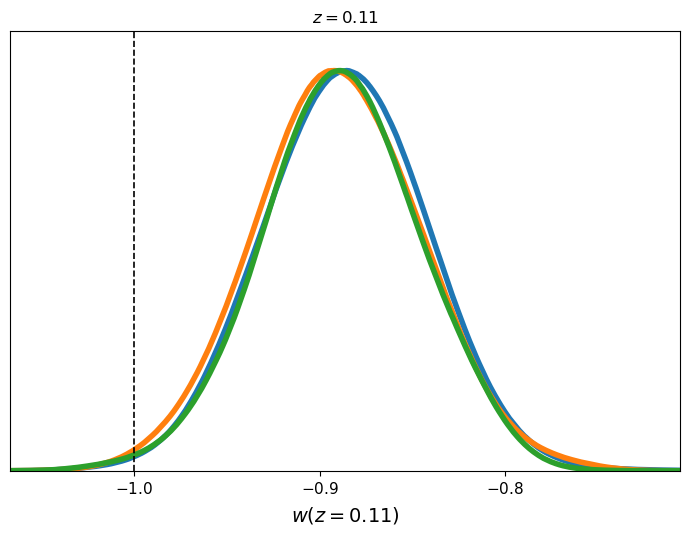

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


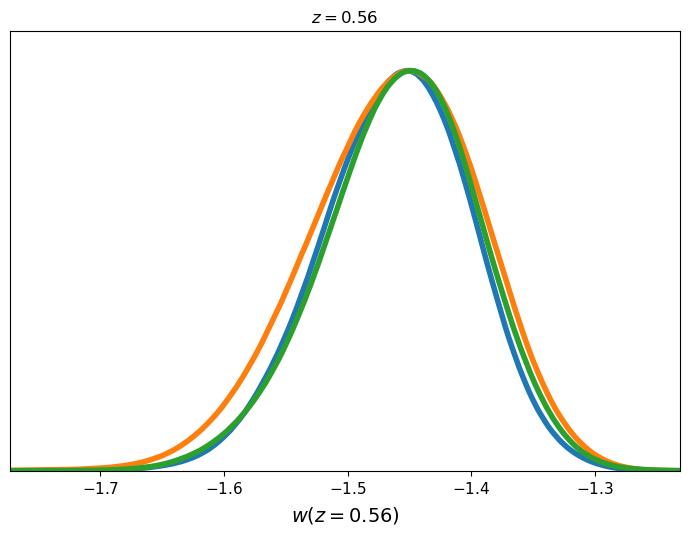

In [111]:
for z_ref in convergence_redshifts:
    g = plot_wz_distributions_at_z(
        z_ref
    )

    plt.show()

##### Origen de los nodos de convergencia

In [112]:
node_origin_combinations = [
    "B",
    "S",
    "C",
    "BS",
    "CB",
    "CS",
    "CBS",
]

wz_by_combination = {
    "CBS": wz_cbs,
}

for combination_id in node_origin_combinations:
    if combination_id == "CBS":
        continue

    if all(
        chains_available_for(
            model_id,
            [combination_id],
        )
        for model_id in dynamic_models
    ):
        wz_by_combination[
            combination_id
        ] = {
            model_id: reconstruct_wz_bands(
                model_id,
                combination_id,
                z_w,
            )
            for model_id in dynamic_models
        }
    else:
        print(
            "Diagnóstico no regenerado para "
            f"{combination_id}: faltan cadenas."
        )

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [113]:
node_origin_rows = []

for combination_id in node_origin_combinations:
    if combination_id not in wz_by_combination:
        continue

    spread_df = get_wz_model_spread(
        wz_by_combination[combination_id]
    )

    minima = get_local_spread_minima(
        spread_df
    )

    if minima.empty:
        continue

    if combination_id == "CBS":
        selected = minima.copy()
    else:
        selected = (
            minima
            .nsmallest(
                1,
                "spread",
            )
            .copy()
        )

    selected.insert(
        0,
        "combination_id",
        combination_id,
    )

    node_origin_rows.append(
        selected
    )

wz_node_origin_summary = pd.concat(
    node_origin_rows,
    ignore_index=True,
)

display(wz_node_origin_summary)

,combination_id,z,CPL,CPL2,EXP,spread
0,B,0.40,-1.058663,-0.959303,-0.961181,0.099360
1,S,0.05,-0.971646,-0.980332,-0.910782,0.069550
2,C,0.39,-1.517801,-1.321800,-1.331568,0.196001
3,BS,0.11,-0.885623,-0.886576,-0.887016,0.001392
4,CB,0.46,-0.999299,-0.960630,-0.998274,0.038669
5,CS,0.54,-1.457234,-1.457978,-1.454957,0.003021
6,CBS,0.11,-0.885911,-0.890465,-0.888230,0.004554
7,CBS,0.56,-1.458108,-1.459805,-1.454671,0.005134


##### Persistencia de los nodos al añadir la tercera sonda

In [114]:
node_comparisons = [
    ("BS", "CBS", 0.11),
    ("CS", "CBS", 0.54),
]

node_persistence_summary = []

for (
    base_combination,
    full_combination,
    z_ref,
) in node_comparisons:

    for model_id in dynamic_models:
        for combination_id in [
            base_combination,
            full_combination,
        ]:
            wz, weights = get_wz_samples(
                model_id,
                combination_id,
                z_ref,
            )

            (
                q2_5,
                q16,
                median,
                q84,
                q97_5,
            ) = expanded_weighted_quantiles(
                wz,
                weights,
                [
                    0.025,
                    0.16,
                    0.50,
                    0.84,
                    0.975,
                ],
            )

            node_persistence_summary.append(
                {
                    "node_source":
                        base_combination,
                    "combination_id":
                        combination_id,
                    "model_id":
                        model_id,
                    "z":
                        z_ref,
                    "median":
                        median,
                    "q16":
                        q16,
                    "q84":
                        q84,
                    "q2_5":
                        q2_5,
                    "q97_5":
                        q97_5,
                    "width_68":
                        q84 - q16,
                }
            )

node_persistence_summary = pd.DataFrame(
    node_persistence_summary
)

display(node_persistence_summary)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


,node_source,combination_id,model_id,z,median,q16,q84,q2_5,q97_5,width_68
0,BS,BS,CPL,0.11,-0.885623,-0.936948,-0.832157,-0.988392,-0.752635,0.104790
1,BS,CBS,CPL,0.11,-0.885911,-0.930560,-0.842087,-0.971196,-0.800590,0.088473
2,BS,BS,CPL2,0.11,-0.886576,-0.940664,-0.814829,-0.991402,-0.640027,0.125835
3,BS,CBS,CPL2,0.11,-0.890465,-0.935212,-0.844839,-0.979346,-0.800682,0.090373
4,BS,BS,EXP,0.11,-0.887016,-0.937114,-0.834502,-0.988057,-0.757815,0.102613
5,BS,CBS,EXP,0.11,-0.888230,-0.930065,-0.845276,-0.973536,-0.805540,0.084789
6,CS,CS,CPL,0.54,-1.457234,-1.521062,-1.397719,-1.585255,-1.342329,0.123343
7,CS,CBS,CPL,0.54,-1.439818,-1.499908,-1.385037,-1.560268,-1.335471,0.114871
8,CS,CS,CPL2,0.54,-1.457978,-1.533322,-1.391224,-1.612342,-1.329765,0.142097
9,CS,CBS,CPL2,0.54,-1.431271,-1.500977,-1.369427,-1.571043,-1.317996,0.131550


Las reconstrucciones de $w(z)$ muestran dos regiones en las que las medianas de las tres parametrizaciones dinámicas presentan una convergencia especialmente marcada. Para CBS se localizan aproximadamente en

$$
z\simeq0.11
\qquad\text{y}\qquad
z\simeq0.56.
$$

En ambos redshifts, la proximidad no se limita a las curvas medianas: las distribuciones posteriores de $w(z)$ muestran también un solapamiento considerable entre CPL, CPL$_2$ y EXP.

El análisis de las combinaciones individuales y parciales permite contextualizar estas estructuras. B, S y C presentan mínimos de dispersión mucho menos pronunciados. En cambio, BS muestra una convergencia especialmente fuerte alrededor de $z\simeq0.11$, mientras que CS presenta una estructura análoga alrededor de $z\simeq0.54$.

Al incorporar la tercera sonda, ambas regiones persisten en CBS. El nodo de bajo redshift mantiene prácticamente su localización, mientras que la región asociada a CS se desplaza ligeramente hacia $z\simeq0.56$.

Estos resultados se consideran un diagnóstico exploratorio de la dependencia respecto a la parametrización. No permiten establecer que dichos redshifts constituyan puntos pivot ni anclajes físicos universales de la evolución de la energía oscura. Comprobar su persistencia con parametrizaciones más generales, una implementación completa de Pantheon+SH0ES y otras combinaciones observacionales constituye una posible línea de investigación futura.

#### Contribución relativa de la energía oscura a la densidad total

La evolución de $f_{\rm DE}(z)$ describe la densidad de energía oscura respecto a su valor actual, pero no indica directamente qué fracción de la densidad total representa esta componente en cada redshift. Para evaluar la relevancia dinámica de las diferencias observadas entre las parametrizaciones se reconstruye también $\Omega_{\rm DE}(z)$.

En el intervalo de bajo e intermedio redshift considerado aquí, la contribución de la radiación es despreciable, por lo que se utiliza

$$
\Omega_{\rm DE}(z)=
\frac{(1-\Omega_m)f_{\rm DE}(z)}
{\Omega_m(1+z)^3+(1-\Omega_m)f_{\rm DE}(z)}.
$$

In [115]:
def reconstruct_omega_de_bands(
    model_id,
    combination_id,
    z_grid,
):
    """
    Reconstruye bandas posteriores de Omega_DE(z) muestra a muestra.

    Para cada muestra posterior se calcula la fracción de la densidad
    total correspondiente a energía oscura,

        Omega_DE(z) =
        Omega_DE,0 f_DE(z)
        / [Omega_m (1+z)^3 + Omega_DE,0 f_DE(z)],

    despreciando la contribución de radiación en el intervalo de
    bajo e intermedio redshift considerado.

    Parameters
    ----------
    model_id : {"CPL", "CPL2", "EXP"}
        Identificador interno del modelo dinámico.
    combination_id : str
        Identificador de la combinación de datos.
    z_grid : array-like
        Redshifts en los que se reconstruirá Omega_DE(z).

    Returns
    -------
    pandas.DataFrame
        Tabla con las columnas ``z``, ``q2_5``, ``q16``, ``median``,
        ``q84`` y ``q97_5``.

    Raises
    ------
    ValueError
        Si se solicita una parametrización no implementada.
    """
    samples = load_getdist_samples(
        model_id,
        combination_id,
    )

    p = samples.getParams()
    weights = np.asarray(
        samples.weights,
        dtype=float,
    )

    omega_m = np.asarray(
        p.Omega_m,
        dtype=float,
    )
    omega_de_0 = 1.0 - omega_m

    w0 = np.asarray(
        p.w0,
        dtype=float,
    )

    if model_id == "CPL":
        evolution = np.asarray(
            p.wa,
            dtype=float,
        )

    elif model_id == "CPL2":
        evolution = np.asarray(
            p.w2,
            dtype=float,
        )

    elif model_id == "EXP":
        evolution = np.asarray(
            p.we,
            dtype=float,
        )

    else:
        raise ValueError(
            "La reconstrucción de Omega_DE(z) solo está implementada "
            "para CPL, CPL2 y EXP."
        )

    rows = []

    for z in np.asarray(z_grid, dtype=float):
        y = z / (1.0 + z)
        log1pz = np.log1p(z)

        if model_id == "CPL":
            log_fde = (
                3.0
                * (1.0 + w0 + evolution)
                * log1pz
                - 3.0 * evolution * y
            )

        elif model_id == "CPL2":
            log_fde = (
                3.0
                * (1.0 + w0)
                * log1pz
                + 3.0
                * evolution
                * (
                    log1pz
                    - y
                    - 0.5 * y**2
                )
            )

        elif model_id == "EXP":
            log_fde = np.empty_like(
                w0,
                dtype=float,
            )

            small_we = (
                np.abs(evolution)
                < 1.0e-8
            )

            log_fde[small_we] = (
                3.0
                * (1.0 + w0[small_we])
                * log1pz
            )

            regular = ~small_we
            we_reg = evolution[regular]

            integral = (
                log1pz
                + w0[regular]
                * np.exp(we_reg)
                * (
                    expi(-we_reg)
                    - expi(
                        -we_reg
                        / (1.0 + z)
                    )
                )
            )

            log_fde[regular] = (
                3.0 * integral
            )

        fde = np.exp(log_fde)

        e2 = (
            omega_m * (1.0 + z) ** 3
            + omega_de_0 * fde
        )

        omega_de_z = (
            omega_de_0 * fde / e2
        )

        (
            q2_5,
            q16,
            median,
            q84,
            q97_5,
        ) = expanded_weighted_quantiles(
            omega_de_z,
            weights,
            [
                0.025,
                0.16,
                0.50,
                0.84,
                0.975,
            ],
        )

        rows.append(
            {
                "z": z,
                "q2_5": q2_5,
                "q16": q16,
                "median": median,
                "q84": q84,
                "q97_5": q97_5,
            }
        )

    return pd.DataFrame(rows)

In [116]:
omega_de_cbs = {}

for model_id in dynamic_models:
    if chains_available_for(
        model_id,
        ["CBS"],
    ):
        omega_de_cbs[model_id] = (
            reconstruct_omega_de_bands(
                model_id=model_id,
                combination_id="CBS",
                z_grid=z_w,
            )
        )
    else:
        print(
            f"Reconstrucción de Omega_DE(z) no regenerada "
            f"para {model_id}-CBS: falta la cadena."
        )

Removed no burn in
Removed no burn in
Removed no burn in


In [117]:
omega_de_reference_redshifts = [
    0.5,
    1.0,
    2.0,
]

omega_de_cbs_reference = []

for model_id in dynamic_models:
    if model_id not in omega_de_cbs:
        continue

    bands = omega_de_cbs[model_id]

    for z_ref in omega_de_reference_redshifts:
        row = bands.loc[
            np.isclose(
                bands["z"],
                z_ref,
            )
        ].iloc[0]

        omega_de_cbs_reference.append(
            {
                "model_id": model_id,
                "z": z_ref,
                "median": row["median"],
                "q16": row["q16"],
                "q84": row["q84"],
                "q2_5": row["q2_5"],
                "q97_5": row["q97_5"],
            }
        )

omega_de_cbs_reference = pd.DataFrame(
    omega_de_cbs_reference
)

omega_de_cbs_reference_display = (
    omega_de_cbs_reference
    .pivot(
        index="z",
        columns="model_id",
        values="median",
    )
    .reindex(
        columns=dynamic_models
    )
    .rename(
        columns=MODEL_LABELS
    )
)

display(
    omega_de_cbs_reference_display
)

model_id,CPL,CPL$_2$,Exponencial
z,,,
0.5,0.423829,0.432059,0.427949
1.0,0.156676,0.149232,0.153506
2.0,0.016762,0.008220,0.011425


Las diferencias entre las parametrizaciones deben interpretarse teniendo en cuenta el peso dinámico de la energía oscura en cada época. En $z=0.5$, esta componente todavía representa aproximadamente el $42$--$43\,\%$ de la densidad total en los tres modelos, mientras que en $z=1$ su contribución se reduce a alrededor del $15\,\%$.

En $z=2$, las medianas descienden hasta aproximadamente el $1.7\,\%$, $0.8\,\%$ y $1.1\,\%$ para CPL, CPL$_2$ y EXP, respectivamente. Por tanto, la fuerte separación entre las reconstrucciones de $w(z)$ a alto redshift se produce en un régimen en el que la energía oscura posee ya un peso dinámico pequeño.

Este comportamiento ayuda a contextualizar por qué diferencias grandes en la ecuación de estado instantánea pueden traducirse en diferencias considerablemente menores en cantidades integradas relacionadas con la historia de expansión.

In [118]:
omega_de_node_redshifts = [
    0.11,
    0.56,
]

omega_de_nodes_cbs = []

for z_ref in omega_de_node_redshifts:
    for model_id in dynamic_models:
        if model_id not in omega_de_cbs:
            continue

        bands = omega_de_cbs[model_id]

        row = bands.loc[
            np.isclose(
                bands["z"],
                z_ref,
            )
        ].iloc[0]

        omega_de_nodes_cbs.append(
            {
                "z": z_ref,
                "model_id": model_id,
                "median": row["median"],
                "q16": row["q16"],
                "q84": row["q84"],
            }
        )

omega_de_nodes_cbs = pd.DataFrame(
    omega_de_nodes_cbs
)

omega_de_nodes_display = (
    omega_de_nodes_cbs
    .pivot(
        index="z",
        columns="model_id",
        values="median",
    )
    .reindex(
        columns=dynamic_models
    )
    .rename(
        columns=MODEL_LABELS
    )
)

display(
    omega_de_nodes_display
)

model_id,CPL,CPL$_2$,Exponencial
z,,,
0.11,0.676703,0.673026,0.675046
0.56,0.383381,0.391586,0.387446


Como comprobación complementaria, se evalúa también $\Omega_{\rm DE}(z)$ en las dos regiones de convergencia identificadas anteriormente.

En $z\simeq0.11$, los tres modelos proporcionan una fracción de energía oscura próxima al $67$--$68\,\%$, mientras que en $z\simeq0.56$ se obtiene aproximadamente un $38$--$39\,\%$. Las diferencias entre parametrizaciones son pequeñas en ambos casos.

Por tanto, los nodos de convergencia de $w(z)$ aparecen en épocas en las que la energía oscura todavía constituye una fracción importante de la densidad total. Este resultado refuerza su interés como diagnóstico exploratorio, pero no demuestra que correspondan a puntos pivot o anclajes físicos universales.

#### Síntesis de la dinámica de la energía oscura

La comparación entre las parametrizaciones dinámicas muestra que sus parámetros evolutivos no pueden interpretarse de forma aislada ni compararse directamente entre modelos. La reconstrucción indica que distintas combinaciones de $(w_0,w_a)$, $(w_0,w_2)$ y $(w_0,w_e)$ pueden producir historias de $w(z)$ considerablemente próximas en el intervalo de redshift más relevante para las sondas tardías.

Para CBS, las trayectorias medianas de las tres parametrizaciones parten de valores actuales con $w_0>-1$ y presentan un cruce reciente hacia $w(z)<-1$. El análisis muestra a muestra indica que este comportamiento aparece en prácticamente toda la masa posterior de las tres parametrizaciones, con redshifts medianos de cruce próximos a $z\simeq0.18$--$0.22$.

Las reconstrucciones muestran además dos regiones de convergencia entre parametrizaciones alrededor de $z\simeq0.11$ y $z\simeq0.56$. El análisis de las combinaciones parciales indica que la primera está especialmente asociada a BS y la segunda a CS, y ambas persisten al incorporar la tercera sonda en CBS. Estas estructuras se consideran resultados exploratorios y no se interpretan como puntos pivot universales.

A redshift mayor las historias de $w(z)$ se separan progresivamente. La divergencia resulta apreciable en torno a $z\simeq1$ y es mucho mayor hacia $z\simeq2$, con EXP situado de forma general entre CPL y CPL$_2$. Sin embargo, las diferencias son considerablemente menores al estudiar cantidades integradas como $f_{\rm DE}(z)$.

La reconstrucción de $\Omega_{\rm DE}(z)$ proporciona el contexto dinámico de esta separación. A $z\simeq2$, la energía oscura representa únicamente alrededor del $1\,\%$ de la densidad total en los tres modelos. Por tanto, las grandes diferencias en $w(z)$ a alto redshift ocurren cuando esta componente posee ya una relevancia dinámica reducida.

En conjunto, las tres formas funcionales pueden presentar parámetros actuales y evoluciones instantáneas diferentes mientras conservan una historia integrada de la energía oscura mucho más próxima en el intervalo donde esta componente tiene mayor peso cosmológico.

Estas conclusiones permanecen condicionadas por la implementación utilizada de Pantheon+SH0ES y, para las combinaciones que contienen CMB, por el uso de información comprimida mediante distance priors.

### Comparación estadística de los modelos

La comparación penalizada entre modelos se realiza mediante una variante del criterio de información de devianza. Para cada muestra posterior se define

$$
D(\theta)=-2\ln\mathcal{L}(\theta),
$$

que en las cadenas finales corresponde al $\chi^2$ total almacenado por Cobaya. Su media posterior ponderada es

$$
\bar D=\langle D(\theta)\rangle_{\rm post}.
$$

Durante la validación metodológica se examinó inicialmente el estimador habitual del número efectivo de parámetros,

$$
p_D=\bar D-D(\bar\theta),
$$

donde $\bar\theta$ es el vector de medias posteriores. Este estimador resultó patológico en varios posteriores fuertemente degenerados o no gaussianos, ya que el punto $\bar\theta$ puede encontrarse lejos de la cresta de alta probabilidad.

Por este motivo, la comparación final adopta el estimador basado en la varianza posterior de la devianza,

$$
p_V=\frac{1}{2}\operatorname{Var}_{\rm post}[D(\theta)],
$$

y se define

$$
\mathrm{DIC}_V=\bar D+p_V.
$$

El cálculo utiliza directamente los pesos originales y el $\chi^2$ total almacenado en las cadenas, sin reevaluar la likelihood en un punto resumen del posterior.

In [119]:
def compute_dicv_for_chain(
    model_id,
    combination_id,
):
    """
    Calcula DIC_V a partir de una cadena MCMC final.

    La devianza se identifica con el chi-cuadrado total almacenado en
    la cadena. Se calculan su media posterior ponderada, el estimador
    efectivo de complejidad basado en la varianza y el correspondiente
    criterio DIC_V.

    Parameters
    ----------
    model_id : str
        Identificador interno del modelo.
    combination_id : str
        Identificador de la combinación de datos.

    Returns
    -------
    dict
        Resumen con ``D_bar``, ``p_V``, ``DIC_V`` y el número nominal
        de parámetros científicos muestreados para esa identidad.

    Raises
    ------
    ValueError
        Si la cadena no contiene las columnas ``weight`` y ``chi2`` o
        si los pesos no definen una distribución válida.
    """
    raw_chain = load_raw_chain(
        model_id,
        combination_id,
    )

    required_columns = {
        "weight",
        "chi2",
    }

    missing_columns = (
        required_columns
        - set(raw_chain.columns)
    )

    if missing_columns:
        raise ValueError(
            "Faltan columnas necesarias para calcular DIC_V: "
            + ", ".join(sorted(missing_columns))
        )

    weights = raw_chain[
        "weight"
    ].to_numpy(dtype=float)

    deviance = raw_chain[
        "chi2"
    ].to_numpy(dtype=float)

    if (
        np.any(weights < 0.0)
        or weights.sum() <= 0.0
    ):
        raise ValueError(
            "Los pesos de la cadena no son válidos."
        )

    D_bar = np.average(
        deviance,
        weights=weights,
    )

    variance_D = np.average(
        (deviance - D_bar) ** 2,
        weights=weights,
    )

    p_V = 0.5 * variance_D
    DIC_V = D_bar + p_V

    scientific_parameters = [
        parameter
        for parameter in PARAMETERS_BY_IDENTITY[
            (model_id, combination_id)
        ]
        if parameter not in AUXILIARY_PARAMETERS
    ]

    n_params = sum(
        parameter in raw_chain.columns
        for parameter in scientific_parameters
    )

    return {
        "model_id": model_id,
        "combination_id": combination_id,
        "n_params": n_params,
        "D_bar": D_bar,
        "p_V": p_V,
        "DIC_V": DIC_V,
    }

In [120]:
dicv_rows = []
dicv_missing = []

for model_id in MODEL_ORDER:
    for combination_id in COMBINATION_ORDER:

        if not chains_available_for(
            model_id,
            [combination_id],
        ):
            dicv_missing.append(
                f"{model_id}-{combination_id}"
            )
            continue

        dicv_rows.append(
            compute_dicv_for_chain(
                model_id,
                combination_id,
            )
        )

dicv_results = pd.DataFrame(
    dicv_rows
)

if dicv_missing:
    print(
        "DIC_V no regenerado para: "
        + ", ".join(dicv_missing)
    )

if not dicv_results.empty:
    display(dicv_results)

,model_id,combination_id,n_params,D_bar,p_V,DIC_V
0,LCDM,B,2,14.786080,2.103813,16.889892
1,LCDM,S,2,1137.428346,2.006450,1139.434796
2,LCDM,C,3,3.046661,3.141217,6.187878
3,LCDM,BS,3,1155.015757,3.176143,1158.191900
4,LCDM,CB,3,20.787660,2.910196,23.697856
5,LCDM,CS,3,1308.170304,3.015073,1311.185377
6,LCDM,CBS,3,1363.513306,2.831198,1366.344503
7,CPL,B,4,11.240686,3.677058,14.917745
8,CPL,S,4,1138.301524,3.452396,1141.753919
9,CPL,C,5,3.004362,3.006348,6.010709


La elección de $p_V$ responde a una validación específica realizada sobre las cadenas finales. El estimador basado en la devianza evaluada en el vector de medias posteriores,

$$
p_D=\bar D-D(\bar\theta),
$$

produce resultados razonables en las posteriores aproximadamente gaussianas de $\Lambda$CDM, pero falla de forma extrema en varias cadenas dinámicas degeneradas. Entre los casos más claros aparecen valores de $p_D$ del orden de $-6300$ para CPL-C, $-6660$ para CPL$_2$-C y $-300$ para EXP-C. También aparecen valores negativos importantes en algunas combinaciones CB.

Estas cantidades no representan una complejidad física negativa. Reflejan que, en posteriores curvos o fuertemente degenerados, el vector formado por las medias marginales puede situarse en una región de likelihood muy baja y dejar de constituir un punto representativo de la distribución conjunta.

La variante

$$
p_V=\frac{1}{2}\operatorname{Var}[D]
$$

evita esta evaluación en $\bar\theta$ y presenta un comportamiento mucho más regular. En $\Lambda$CDM, $p_V$ se mantiene próximo al número de parámetros efectivamente constreñidos. En CMB-only, los modelos dinámicos presentan $p_V\simeq3$ pese a disponer de cinco parámetros nominales, en consonancia con las fuertes degeneraciones observadas al utilizar la likelihood CMB comprimida. Este comportamiento caracteriza el contenido informativo de los distance priors empleados y no debe extrapolarse al que produciría una likelihood completa de anisotropías del CMB.

Algunas cadenas no gaussianas presentan valores de $p_V$ ligeramente superiores al número nominal de parámetros, como ocurre especialmente en EXP-B y EXP-CB. Por ello, diferencias pequeñas de $\mathrm{DIC}_V$ deben interpretarse con cautela y no como una discriminación precisa entre modelos.

In [121]:
dic_comparison = dicv_results.copy()

lcdm_dic_reference = (
    dic_comparison.loc[
        dic_comparison["model_id"] == "LCDM",
        [
            "combination_id",
            "DIC_V",
        ],
    ]
    .rename(
        columns={
            "DIC_V": "DIC_V_LCDM"
        }
    )
)

dic_comparison = dic_comparison.merge(
    lcdm_dic_reference,
    on="combination_id",
    how="left",
)

dic_comparison["delta_DIC_V"] = (
    dic_comparison["DIC_V"]
    - dic_comparison["DIC_V_LCDM"]
)

In [122]:
delta_dic_table = (
    dic_comparison.loc[
        dic_comparison["model_id"].isin(
            dynamic_models
        )
    ]
    .pivot(
        index="model_id",
        columns="combination_id",
        values="delta_DIC_V",
    )
    .reindex(
        index=dynamic_models,
        columns=COMBINATION_ORDER,
    )
)

delta_dic_table_display = (
    delta_dic_table
    .rename(
        index=MODEL_LABELS
    )
    .round(2)
)

display(
    delta_dic_table_display
)

combination_id,B,S,C,BS,CB,CS,CBS
model_id,,,,,,,
CPL,-1.97,2.32,-0.18,-1.61,-2.45,-144.88,-155.16
CPL$_2$,-1.67,2.25,0.06,-2.50,-2.37,-150.85,-155.76
Exponencial,1.62,2.31,-0.20,-0.76,-1.19,-148.55,-155.75


#### Comparación respecto a $\Lambda$CDM

Se define

$$
\Delta\mathrm{DIC}_V
=
\mathrm{DIC}_{V,\mathrm{modelo}}
-
\mathrm{DIC}_{V,\Lambda\mathrm{CDM}},
$$

de modo que valores negativos indican una preferencia formal por la parametrización dinámica frente a $\Lambda$CDM.

Las sondas individuales no muestran una ventaja clara de introducir dinámica. Para B y C las diferencias son pequeñas, mientras que S presenta valores de $\Delta\mathrm{DIC}_V\simeq+2.3$ para los tres modelos dinámicos, de forma que la penalización por complejidad compensa la pequeña mejora del ajuste.

Las combinaciones BS y CB muestran diferencias también moderadas, con $\lvert\Delta\mathrm{DIC}_V\rvert$ de unas pocas unidades. En este régimen no aparece una discriminación clara entre CPL, CPL$_2$ y EXP.

El comportamiento cambia de forma pronunciada para CS y CBS. En CS se obtienen

$$
\Delta\mathrm{DIC}_V
\simeq
-145,\;-151,\;-149
$$

para CPL, CPL$_2$ y EXP, respectivamente. Para la combinación completa CBS las diferencias alcanzan aproximadamente

$$
\Delta\mathrm{DIC}_V
\simeq
-155.2,\;-155.8,\;-155.8.
$$

Dentro de las likelihoods implementadas, CS y CBS producen valores de $\mathrm{DIC}_V$ mucho menores para las parametrizaciones dinámicas que para $\Lambda$CDM. Esta diferencia constituye una preferencia formal del criterio estadístico aplicado a este análisis, pero no debe interpretarse como evidencia física de energía oscura dinámica ni como una exclusión de $\Lambda$CDM. Además, las tres parametrizaciones dinámicas son prácticamente indistinguibles entre sí en CBS, con diferencias de $\mathrm{DIC}_V$ inferiores a una unidad.

La magnitud de los valores obtenidos para CS y CBS está fuertemente condicionada por la implementación de Pantheon+SH0ES utilizada. La auditoría de esta verosimilitud mostró que la escala absoluta queda fijada con una precisión efectiva superior a la de la implementación oficial completa, intensificando el compromiso con la información de CMB. Por ello, los valores de $\Delta\mathrm{DIC}_V$ cuantifican exclusivamente la comparación entre modelos para las likelihoods efectivamente utilizadas. No permiten anticipar ni el signo ni la magnitud que tendría la comparación tras una implementación completa de Pantheon+SH0ES.

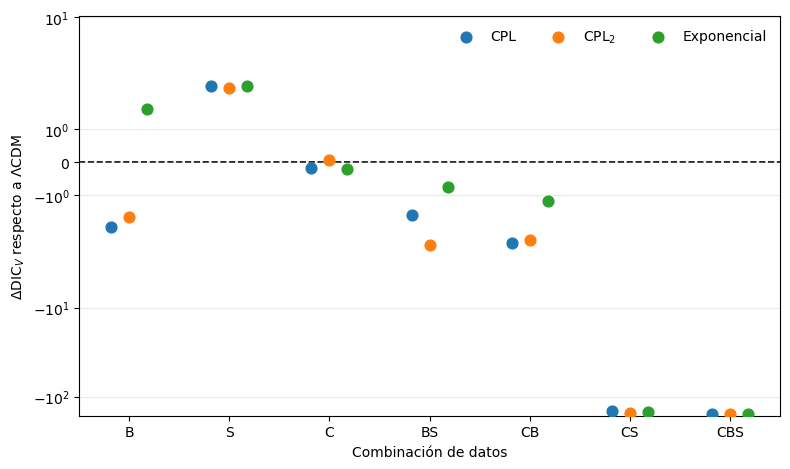

In [123]:
fig, ax = plt.subplots(
    figsize=(8.0, 4.8)
)

x = np.arange(
    len(COMBINATION_ORDER)
)

offsets = {
    "CPL": -0.18,
    "CPL2": 0.00,
    "EXP": 0.18,
}

for model_id in dynamic_models:
    model_data = (
        dic_comparison.loc[
            dic_comparison["model_id"]
            == model_id,
            [
                "combination_id",
                "delta_DIC_V",
            ],
        ]
        .set_index("combination_id")
        .reindex(COMBINATION_ORDER)
    )

    ax.scatter(
        x + offsets[model_id],
        model_data["delta_DIC_V"],
        s=60,
        color=MODEL_COLORS[model_id],
        label=MODEL_LABELS[model_id],
        zorder=3,
    )

ax.axhline(
    0.0,
    color=LCDM_REFERENCE_COLOR,
    linestyle="--",
    linewidth=1.2,
    zorder=1,
)

ax.set_yscale(
    "symlog",
    linthresh=3.0,
)

ax.set_xticks(x)
ax.set_xticklabels(
    COMBINATION_ORDER
)

ax.set_xlabel(
    "Combinación de datos"
)

ax.set_ylabel(
    r"$\Delta\mathrm{DIC}_V$ respecto a $\Lambda$CDM"
)

ax.legend(
    frameon=False,
    ncol=3,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

plt.show()

En conjunto, la comparación mediante $\mathrm{DIC}_V$ muestra dos comportamientos distintos dentro de las likelihoods utilizadas. Las sondas individuales y las combinaciones BS y CB presentan diferencias pequeñas o moderadas entre $\Lambda$CDM y los modelos dinámicos. En cambio, CS y CBS generan diferencias formales mucho mayores al permitir grados de libertad adicionales en la evolución de $w(z)$.

Este resultado no constituye por sí mismo evidencia de una evolución física de la energía oscura. Las diferencias de $\mathrm{DIC}_V$ para CS y CBS deben interpretarse junto con la tensión entre las sondas y, especialmente, con la limitación identificada en la implementación de Pantheon+SH0ES.

Dentro del conjunto de modelos dinámicos considerado, CBS tampoco establece una jerarquía estadística clara entre CPL, CPL$_2$ y EXP: sus valores de $\mathrm{DIC}_V$ son prácticamente indistinguibles. Por tanto, el análisis realizado no permite seleccionar una de las tres formas funcionales dinámicas como preferida frente a las demás.